# Sensibilidad ventana inferior × grado — ajuste simultáneo polinomio + F3

Este notebook repite el análisis de separación del background polinómico temporal usando el esquema **simultáneo**:

\[
y(t) = P_n(t) + F3(t),
\]

sin excluir ninguna ventana del ajuste. El objetivo es evaluar si el caso antiguo `degA7_degPhi4` es estable frente a cambios en:

- el inicio de la ventana: 14:00, 15:00, 16:00, 17:00 y 18:00 UTC;
- el grado polinómico para amplitud y fase: 3 a 8.

Las ventanas de evento se usan **solo para diagnóstico** —picos, áreas y figuras—, no para excluir datos del ajuste. Esto es importante: aquí el polinomio y la F3 compiten simultáneamente, igual que en el método antiguo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
from scipy.optimize import least_squares
from itertools import product

# ------------------------------------------------------------
# Configuración general
# ------------------------------------------------------------
DATE_UTC = "2008-03-25"
DATA_FILE = Path("Datos_VLF-2008-03/Punta-Lobos/PLO-20080325.fits")

# Canal NAA_V en tus notebooks previos
COL_TIME_SEC = 0
COL_PHASE = 2
COL_AMP = 3

RESAMPLE_RULE = "1min"
RESAMPLE_AGG = "median"

WINDOW_START_HOURS = [14, 15, 16, 17, 18]
WINDOW_END = pd.Timestamp(f"{DATE_UTC} 22:00:00", tz="UTC")

DEGREES_A = list(range(3, 9))
DEGREES_PHI = list(range(3, 9))

# Ventanas solo diagnósticas. NO se excluyen del ajuste.
A_EVENT_START = pd.Timestamp(f"{DATE_UTC} 18:20:00", tz="UTC")
A_EVENT_END   = pd.Timestamp(f"{DATE_UTC} 20:30:00", tz="UTC")

PHI_EVENT_START = pd.Timestamp(f"{DATE_UTC} 18:20:00", tz="UTC")
PHI_EVENT_END   = pd.Timestamp(f"{DATE_UTC} 21:00:00", tz="UTC")

# Caso antiguo esperado: ventana 16--22, degA=7, degPhi=4.
REFERENCE_WINDOW_LABEL = "16_22"
REFERENCE_DEG_A = 7
REFERENCE_DEG_PHI = 4

# Selección manual editable al final.
SELECTED_WINDOW_LABEL = "16_22"
SELECTED_DEG_A = 7
SELECTED_DEG_PHI = 4

OUTDIR = Path("outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325")
FIGDIR = OUTDIR / "figures"
TABDIR = OUTDIR / "tables"
H5DIR = OUTDIR / "h5"
for d in [OUTDIR, FIGDIR, TABDIR, H5DIR]:
    d.mkdir(parents=True, exist_ok=True)

ROBUST_LOSS = "linear"   # Para reproducir el esquema clásico; opciones: linear, soft_l1, huber
MAX_NFEV = 20000

print("Configuración lista")
print("Ventanas:", [f"{h:02d}--22" for h in WINDOW_START_HOURS])
print("Grados A:", DEGREES_A)
print("Grados phi:", DEGREES_PHI)
print("Evento A diagnóstico:", A_EVENT_START, "->", A_EVENT_END)
print("Evento phi diagnóstico:", PHI_EVENT_START, "->", PHI_EVENT_END)

Configuración lista
Ventanas: ['14--22', '15--22', '16--22', '17--22', '18--22']
Grados A: [3, 4, 5, 6, 7, 8]
Grados phi: [3, 4, 5, 6, 7, 8]
Evento A diagnóstico: 2008-03-25 18:20:00+00:00 -> 2008-03-25 20:30:00+00:00
Evento phi diagnóstico: 2008-03-25 18:20:00+00:00 -> 2008-03-25 21:00:00+00:00


## 1. Lectura de datos

La celda siguiente intenta usar primero `df_1min`, `df_resampled` o `df_native` si ya existen en la sesión. Si no existen, lee el FITS desde `DATA_FILE` y remuestrea a 1 minuto usando la mediana.

In [2]:
def ensure_utc_index(df):
    df = df.copy()
    idx = pd.DatetimeIndex(df.index)
    if idx.tz is None:
        idx = idx.tz_localize("UTC")
    else:
        idx = idx.tz_convert("UTC")
    df.index = idx
    return df.sort_index()


def build_df_1min_from_available_data():
    if "df_1min" in globals():
        return ensure_utc_index(globals()["df_1min"].copy())

    if "df_resampled" in globals():
        return ensure_utc_index(globals()["df_resampled"].copy())

    if "df_native" in globals():
        df = globals()["df_native"].copy()
        if "time_utc" in df.columns:
            df["time_utc"] = pd.to_datetime(df["time_utc"], utc=True)
            df = df.set_index("time_utc")
        df = ensure_utc_index(df)
        return df.resample(RESAMPLE_RULE).median(numeric_only=True)

    if not DATA_FILE.exists():
        raise FileNotFoundError(
            f"No existe DATA_FILE={DATA_FILE}. Ajusta DATA_FILE o ejecuta antes la celda que genera df_1min."
        )

    from astropy.io import fits
    with fits.open(DATA_FILE) as hdul:
        arr = np.asarray(hdul[0].data)

    time_sec = arr[:, COL_TIME_SEC].astype(float)
    phi = arr[:, COL_PHASE].astype(float)
    A = arr[:, COL_AMP].astype(float)

    t0 = pd.Timestamp(f"{DATE_UTC} 00:00:00", tz="UTC")
    time_utc = t0 + pd.to_timedelta(time_sec, unit="s")

    df = pd.DataFrame(
        {"A_real": A, "phi_real": phi},
        index=pd.DatetimeIndex(time_utc, name="time_utc"),
    )
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.resample(RESAMPLE_RULE).median(numeric_only=True)
    return ensure_utc_index(df)


df_base = build_df_1min_from_available_data()

# Normalización de nombres por seguridad
rename_map = {}
if "A" in df_base.columns and "A_real" not in df_base.columns:
    rename_map["A"] = "A_real"
if "amp" in df_base.columns and "A_real" not in df_base.columns:
    rename_map["amp"] = "A_real"
if "amplitude" in df_base.columns and "A_real" not in df_base.columns:
    rename_map["amplitude"] = "A_real"
if "phi" in df_base.columns and "phi_real" not in df_base.columns:
    rename_map["phi"] = "phi_real"
if "phase" in df_base.columns and "phi_real" not in df_base.columns:
    rename_map["phase"] = "phi_real"

df_base = df_base.rename(columns=rename_map)

required = ["A_real", "phi_real"]
missing = [c for c in required if c not in df_base.columns]
if missing:
    raise KeyError(f"Faltan columnas {missing}. Columnas disponibles: {list(df_base.columns)}")

df_base = df_base[["A_real", "phi_real"]].replace([np.inf, -np.inf], np.nan).dropna(how="all")

print("Datos base:")
print("  N =", len(df_base))
print("  rango =", df_base.index.min(), "->", df_base.index.max())
display(df_base.head())

Datos base:
  N = 1440
  rango = 2008-03-25 00:00:00+00:00 -> 2008-03-25 23:59:00+00:00


,A_real,phi_real
time_utc,,
2008-03-25 00:00:00+00:00,25.900000,15.375
2008-03-25 00:01:00+00:00,25.804999,14.110
2008-03-25 00:02:00+00:00,25.809999,13.205
2008-03-25 00:03:00+00:00,25.830000,11.390
2008-03-25 00:04:00+00:00,25.750000,10.160


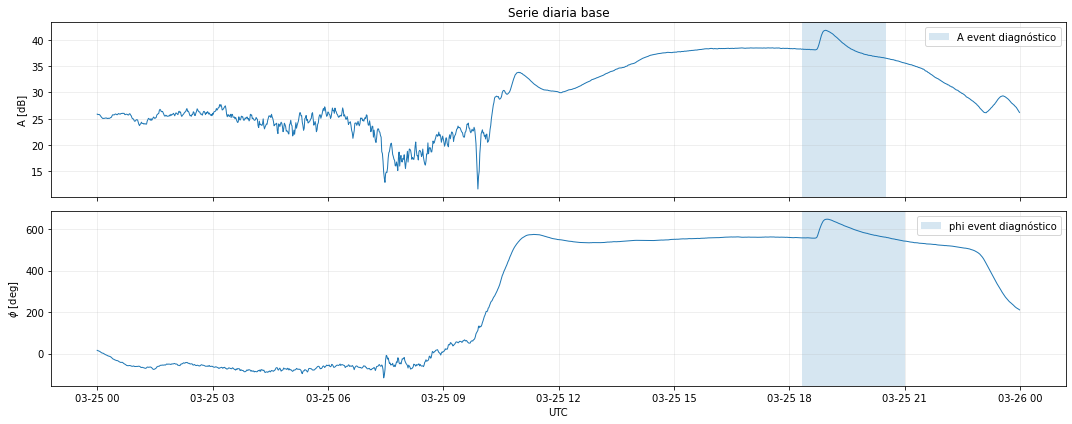

In [3]:
# Figura rápida del día completo con eventos diagnósticos
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axes[0].plot(df_base.index, df_base["A_real"], lw=1.0)
axes[0].axvspan(A_EVENT_START, A_EVENT_END, alpha=0.18, label="A event diagnóstico")
axes[0].set_ylabel("A [dB]")
axes[0].set_title("Serie diaria base")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(df_base.index, df_base["phi_real"], lw=1.0)
axes[1].axvspan(PHI_EVENT_START, PHI_EVENT_END, alpha=0.18, label="phi event diagnóstico")
axes[1].set_ylabel(r"$\phi$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].grid(True, alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGDIR / "01_raw_full_day_diagnostic_events.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Modelo simultáneo polinomio + F3

Para cada canal y cada par `(ventana, grado)`, se ajusta

\[
y(t)=P_n(t)+\mathrm{amp}\,\exp\left[-\frac12\left(\frac{t-t_{pk}}{w(t)}\right)^2\right],
\]

con

\[
w(t)=\tau_u + \frac12(\tau_d-\tau_u)\left[1+\tanh\left(\frac{t-t_{pk}}{\epsilon}\right)\right].
\]

El polinomio se evalúa en una coordenada escalada \(x\in[-1,1]\), lo que mejora la estabilidad numérica para grados altos.

In [4]:
def hours_since(index, t0):
    return np.asarray((pd.DatetimeIndex(index) - t0).total_seconds(), dtype=float) / 3600.0


def scaled_x(t_hours, duration_hours):
    if duration_hours <= 0:
        raise ValueError("duration_hours debe ser positivo")
    return 2.0 * (np.asarray(t_hours, dtype=float) / duration_hours) - 1.0


def poly_eval(coeffs, x):
    coeffs = np.asarray(coeffs, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float)
    power = np.ones_like(x, dtype=float)
    for c in coeffs:
        y += c * power
        power *= x
    return y


def f3_asymmetric(t, amp, t_pk, tau_u, tau_d, eps):
    t = np.asarray(t, dtype=float)
    eps = max(float(eps), 1e-6)
    tau_u = max(float(tau_u), 1e-6)
    tau_d = max(float(tau_d), 1e-6)
    w = tau_u + 0.5 * (tau_d - tau_u) * (1.0 + np.tanh((t - t_pk) / eps))
    w = np.maximum(w, 1e-6)
    return amp * np.exp(-0.5 * ((t - t_pk) / w) ** 2)


def model_poly_f3(params, x, t_hours, degree):
    coeffs = params[:degree+1]
    amp, t_pk, tau_u, tau_d, eps = params[degree+1:degree+6]
    bg = poly_eval(coeffs, x)
    f3 = f3_asymmetric(t_hours, amp, t_pk, tau_u, tau_d, eps)
    return bg + f3


def make_initial_guesses(t_hours, x, y, degree, window_start_hour):
    """Genera varios puntos iniciales para evitar mínimos malos."""
    duration = float(np.max(t_hours) - np.min(t_hours)) if len(t_hours) else 1.0
    duration = max(duration, 1e-6)

    finite = np.isfinite(x) & np.isfinite(y)
    x_f = x[finite]
    y_f = y[finite]
    t_f = t_hours[finite]

    if len(y_f) < degree + 1:
        raise ValueError("No hay suficientes puntos finitos para inicializar")

    # Polinomio con todos los puntos
    coeff_all = np.polynomial.polynomial.polyfit(x_f, y_f, degree)
    bg_all = poly_eval(coeff_all, x)
    resid_all = y - bg_all

    # Polinomio con bordes de la ventana, solo como inicialización, no como máscara de ajuste.
    q1 = np.quantile(t_f, 0.25)
    q3 = np.quantile(t_f, 0.75)
    edge_mask = finite & ((t_hours <= q1) | (t_hours >= q3))
    if np.sum(edge_mask) >= degree + 1:
        coeff_edge = np.polynomial.polynomial.polyfit(x[edge_mask], y[edge_mask], degree)
    else:
        coeff_edge = coeff_all.copy()
    bg_edge = poly_eval(coeff_edge, x)
    resid_edge = y - bg_edge

    def peak_from_resid(resid):
        rr = np.asarray(resid, dtype=float)
        valid = np.isfinite(rr)
        if np.sum(valid) == 0:
            return 0.3 * np.nanstd(y), 0.5 * duration
        i = np.nanargmax(rr[valid])
        valid_idx = np.where(valid)[0]
        ii = valid_idx[i]
        amp0 = max(float(rr[ii]), 0.05 * np.nanstd(y))
        tpk0 = float(t_hours[ii])
        return amp0, tpk0

    amp_all, tpk_all = peak_from_resid(resid_all)
    amp_edge, tpk_edge = peak_from_resid(resid_edge)

    # Pico esperado absoluto cerca de 18:56 UTC.
    tpk_expected = 18.93 - float(window_start_hour)
    tpk_expected = float(np.clip(tpk_expected, 0.0, duration))

    y_range = float(np.nanmax(y) - np.nanmin(y))
    amp_default = max(0.25 * y_range, 0.1 * np.nanstd(y))

    guesses = []
    for coeff, amp0, tpk0, tu, td, eps in [
        (coeff_all,  amp_all,  tpk_all,      0.08, 0.40, 0.01),
        (coeff_edge, amp_edge, tpk_edge,     0.08, 0.50, 0.01),
        (coeff_edge, amp_default, tpk_expected, 0.07, 0.60, 0.005),
        (coeff_all,  amp_default, tpk_expected, 0.10, 0.80, 0.05),
        (coeff_edge, 0.5*y_range, tpk_expected, 0.05, 0.40, 0.005),
    ]:
        guesses.append(np.r_[coeff, amp0, tpk0, tu, td, eps])

    return guesses


def fit_poly_f3_channel(df, ycol, window_start, window_end, degree, event_start, event_end):
    dfw = df.loc[(df.index >= window_start) & (df.index <= window_end), [ycol]].dropna().copy()
    if len(dfw) == 0:
        raise ValueError(f"Ventana vacía para {ycol}: {window_start}->{window_end}")

    t_hours = hours_since(dfw.index, window_start)
    duration = hours_since([window_end], window_start)[0]
    x = scaled_x(t_hours, duration)
    y = dfw[ycol].to_numpy(dtype=float)

    finite = np.isfinite(t_hours) & np.isfinite(x) & np.isfinite(y)
    t_hours = t_hours[finite]
    x = x[finite]
    y = y[finite]
    index = dfw.index[finite]

    if len(y) < degree + 6:
        raise ValueError(f"Muy pocos puntos para {ycol}, grado={degree}")

    y_range = max(float(np.nanmax(y) - np.nanmin(y)), 1e-6)
    duration = max(float(duration), 1e-6)
    amp_cap = max(3.0 * y_range, 1.0)

    ncoef = degree + 1
    lower = np.r_[np.full(ncoef, -np.inf), 0.0, 0.0, 1/600, 1/600, 1e-4]
    upper = np.r_[np.full(ncoef,  np.inf), amp_cap, duration, duration, duration, min(2.0, duration)]

    starts = make_initial_guesses(t_hours, x, y, degree, window_start.hour)

    best = None
    best_cost = np.inf
    best_result = None

    def residuals(params):
        return model_poly_f3(params, x, t_hours, degree) - y

    for p0 in starts:
        p0 = np.asarray(p0, dtype=float)
        # Proteger parámetros F3 contra bounds
        p0[ncoef+0] = np.clip(p0[ncoef+0], lower[ncoef+0] + 1e-9, upper[ncoef+0] - 1e-9)
        p0[ncoef+1] = np.clip(p0[ncoef+1], lower[ncoef+1] + 1e-9, upper[ncoef+1] - 1e-9)
        p0[ncoef+2] = np.clip(p0[ncoef+2], lower[ncoef+2] + 1e-9, upper[ncoef+2] - 1e-9)
        p0[ncoef+3] = np.clip(p0[ncoef+3], lower[ncoef+3] + 1e-9, upper[ncoef+3] - 1e-9)
        p0[ncoef+4] = np.clip(p0[ncoef+4], lower[ncoef+4] + 1e-9, upper[ncoef+4] - 1e-9)

        try:
            res = least_squares(
                residuals,
                p0,
                bounds=(lower, upper),
                loss=ROBUST_LOSS,
                max_nfev=MAX_NFEV,
                x_scale="jac",
            )
            cost = float(2 * res.cost)  # suma de cuadrados si loss lineal
            if np.isfinite(cost) and cost < best_cost:
                best = res.x.copy()
                best_cost = cost
                best_result = res
        except Exception as e:
            continue

    if best is None:
        raise RuntimeError(f"No convergió ningún ajuste para {ycol}, grado={degree}, ventana={window_start}->{window_end}")

    coeffs = best[:ncoef]
    amp, t_pk, tau_u, tau_d, eps = best[ncoef:ncoef+5]
    bg = poly_eval(coeffs, x)
    f3 = f3_asymmetric(t_hours, amp, t_pk, tau_u, tau_d, eps)
    total = bg + f3
    resid = y - total

    event_mask = np.asarray((index >= event_start) & (index <= event_end), dtype=bool)
    valid_resid = np.isfinite(resid)

    rss = float(np.sum(resid[valid_resid] ** 2))
    n = int(np.sum(valid_resid))
    k = int(len(best))
    var_y = float(np.nanvar(y))
    rmse = float(np.sqrt(rss / n)) if n > 0 else np.nan
    mae = float(np.mean(np.abs(resid[valid_resid]))) if n > 0 else np.nan
    bias = float(np.mean(resid[valid_resid])) if n > 0 else np.nan
    chi2norm = float(rss / (n * var_y)) if n > 0 and var_y > 0 else np.nan
    redchi = float(rss / max(n - k, 1)) if n > 0 else np.nan
    aic = float(n * np.log(max(rss/n, 1e-300)) + 2*k) if n > 0 else np.nan
    bic = float(n * np.log(max(rss/n, 1e-300)) + k*np.log(max(n, 1))) if n > 0 else np.nan

    f3_event = f3[event_mask]
    t_event = t_hours[event_mask]
    if len(f3_event) > 0:
        peak_abs = float(np.nanmax(np.abs(f3_event)))
        peak_signed = float(f3_event[np.nanargmax(np.abs(f3_event))])
        area_abs = float(np.trapz(np.abs(f3_event), t_event)) if len(f3_event) > 1 else np.nan
        area_signed = float(np.trapz(f3_event, t_event)) if len(f3_event) > 1 else np.nan
    else:
        peak_abs = peak_signed = area_abs = area_signed = np.nan

    out = pd.DataFrame(
        {
            ycol: y,
            f"{ycol}_background": bg,
            f"{ycol}_F3": f3,
            f"{ycol}_total_fit": total,
            f"{ycol}_residual": resid,
            "t_hours": t_hours,
            "x_scaled": x,
            "event_mask_diagnostic": event_mask,
        },
        index=pd.DatetimeIndex(index, name="time_utc"),
    )

    metrics = {
        "channel_col": ycol,
        "window_start": window_start,
        "window_end": window_end,
        "degree": degree,
        "N": n,
        "N_params": k,
        "rss": rss,
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "chi2norm": chi2norm,
        "redchi": redchi,
        "AIC": aic,
        "BIC": bic,
        "F3_amp": float(amp),
        "F3_t_pk_hours": float(t_pk),
        "F3_t_pk_utc": window_start + pd.to_timedelta(float(t_pk), unit="h"),
        "F3_tau_u_h": float(tau_u),
        "F3_tau_d_h": float(tau_d),
        "F3_eps_h": float(eps),
        "F3_peak_abs_event": peak_abs,
        "F3_peak_signed_event": peak_signed,
        "F3_area_abs_event": area_abs,
        "F3_area_signed_event": area_signed,
        "optimizer_cost": best_cost,
        "optimizer_nfev": int(best_result.nfev) if best_result is not None else -1,
        "optimizer_success": bool(best_result.success) if best_result is not None else False,
        "optimizer_message": str(best_result.message) if best_result is not None else "",
    }

    return out, metrics, best

## 3. Ejecutar la grilla

Se ajusta cada canal de forma independiente por ventana y grado. Luego se construye la tabla combinada `degA × degPhi` para cada ventana.

In [5]:
results_A = {}
results_phi = {}
metrics_A = []
metrics_phi = []
params_A = {}
params_phi = {}

for h0 in WINDOW_START_HOURS:
    window_label = f"{h0:02d}_22"
    wstart = pd.Timestamp(f"{DATE_UTC} {h0:02d}:00:00", tz="UTC")

    print(f"\nVentana {window_label}")

    for deg in DEGREES_A:
        print(f"  Ajustando A deg={deg}...", end=" ")
        out, met, par = fit_poly_f3_channel(
            df_base, "A_real", wstart, WINDOW_END, deg, A_EVENT_START, A_EVENT_END
        )
        met.update({"channel": "A", "window_label": window_label, "window_start_hour": h0})
        metrics_A.append(met)
        results_A[(window_label, deg)] = out
        params_A[(window_label, deg)] = par
        print(f"RMSE={met['rmse']:.4g}, chi2={met['chi2norm']:.4g}, amp={met['F3_amp']:.4g}")

    for deg in DEGREES_PHI:
        print(f"  Ajustando phi deg={deg}...", end=" ")
        out, met, par = fit_poly_f3_channel(
            df_base, "phi_real", wstart, WINDOW_END, deg, PHI_EVENT_START, PHI_EVENT_END
        )
        met.update({"channel": "phi", "window_label": window_label, "window_start_hour": h0})
        metrics_phi.append(met)
        results_phi[(window_label, deg)] = out
        params_phi[(window_label, deg)] = par
        print(f"RMSE={met['rmse']:.4g}, chi2={met['chi2norm']:.4g}, amp={met['F3_amp']:.4g}")

metrics_A_df = pd.DataFrame(metrics_A)
metrics_phi_df = pd.DataFrame(metrics_phi)

metrics_A_df.to_csv(TABDIR / "polyF3_metrics_A_by_window_degree.csv", index=False)
metrics_phi_df.to_csv(TABDIR / "polyF3_metrics_phi_by_window_degree.csv", index=False)

print("\nListo")
display(metrics_A_df[["window_label", "degree", "rmse", "chi2norm", "AIC", "BIC", "F3_amp", "F3_t_pk_utc", "F3_tau_u_h", "F3_tau_d_h"]].round(6).head())
display(metrics_phi_df[["window_label", "degree", "rmse", "chi2norm", "AIC", "BIC", "F3_amp", "F3_t_pk_utc", "F3_tau_u_h", "F3_tau_d_h"]].round(6).head())


Ventana 14_22
  Ajustando A deg=3... RMSE=0.2297, chi2=0.01693, amp=3.688
  Ajustando A deg=4... 

/tmp/ipykernel_54060/1422378199.py:196: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_abs = float(np.trapz(np.abs(f3_event), t_event)) if len(f3_event) > 1 else np.nan
/tmp/ipykernel_54060/1422378199.py:197: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_signed = float(np.trapz(f3_event, t_event)) if len(f3_event) > 1 else np.nan
/tmp/ipykernel_54060/1422378199.py:196: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_abs = float(np.trapz(np.abs(f3_event), t_event)) if len(f3_event) > 1 else np.nan
/tmp/ipykernel_54060/1422378199.py:197: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_signed = float(np.trapz(f3_

RMSE=0.09078, chi2=0.002645, amp=3.78
  Ajustando A deg=5... RMSE=0.08887, chi2=0.002535, amp=3.82
  Ajustando A deg=6... 

/tmp/ipykernel_54060/1422378199.py:196: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_abs = float(np.trapz(np.abs(f3_event), t_event)) if len(f3_event) > 1 else np.nan
/tmp/ipykernel_54060/1422378199.py:197: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_signed = float(np.trapz(f3_event, t_event)) if len(f3_event) > 1 else np.nan


RMSE=0.05704, chi2=0.001044, amp=3.908
  Ajustando A deg=7... 

...

/tmp/ipykernel_54060/1422378199.py:196: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_abs = float(np.trapz(np.abs(f3_event), t_event)) if len(f3_event) > 1 else np.nan
/tmp/ipykernel_54060/1422378199.py:197: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_signed = float(np.trapz(f3_event, t_event)) if len(f3_event) > 1 else np.nan


RMSE=0.5974, chi2=0.0002812, amp=87.27
  Ajustando phi deg=8... RMSE=0.4535, chi2=0.0001621, amp=97.4

Listo


/tmp/ipykernel_54060/1422378199.py:196: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_abs = float(np.trapz(np.abs(f3_event), t_event)) if len(f3_event) > 1 else np.nan
/tmp/ipykernel_54060/1422378199.py:197: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_signed = float(np.trapz(f3_event, t_event)) if len(f3_event) > 1 else np.nan


,window_label,degree,rmse,chi2norm,AIC,BIC,F3_amp,F3_t_pk_utc,F3_tau_u_h,F3_tau_d_h
0,14_22,3,0.229714,0.016933,-1397.025579,-1359.442773,3.688435,2008-03-25 18:56:34.466666600+00:00,0.010967,0.374101
1,14_22,4,0.090781,0.002645,-2288.128553,-2246.369881,3.780485,2008-03-25 18:56:26.005989750+00:00,0.052454,0.349390
2,14_22,5,0.088872,0.002535,-2306.580721,-2260.646181,3.819601,2008-03-25 18:56:30.450670054+00:00,0.050757,0.353451
3,14_22,6,0.057038,0.001044,-2731.196319,-2681.085911,3.907507,2008-03-25 18:56:50.195501948+00:00,0.019593,0.381976
4,14_22,7,0.054660,0.000959,-2770.170661,-2715.884386,3.941458,2008-03-25 18:56:52.884955593+00:00,0.021907,0.382648


,window_label,degree,rmse,chi2norm,AIC,BIC,F3_amp,F3_t_pk_utc,F3_tau_u_h,F3_tau_d_h
0,14_22,3,2.409074,0.008242,863.831240,901.414046,83.264447,2008-03-25 18:52:36.849640846+00:00,0.071261,0.795784
1,14_22,4,2.335516,0.007747,835.999915,877.758588,83.201928,2008-03-25 18:52:45.516337204+00:00,0.072158,0.754580
2,14_22,5,2.060276,0.006028,717.371960,763.306500,86.381643,2008-03-25 18:52:58.010104430+00:00,0.077085,0.765508
3,14_22,6,1.931825,0.005300,657.443589,707.553996,82.454383,2008-03-25 18:58:19.867450465+00:00,0.001667,0.580851
4,14_22,7,1.460657,0.003030,390.488929,444.775204,85.321329,2008-03-25 18:58:25.985308335+00:00,0.001667,0.553581


In [6]:
# Tabla combinada degA × degPhi por ventana
combo_rows = []
for window_label in [f"{h:02d}_22" for h in WINDOW_START_HOURS]:
    A_sub = metrics_A_df[metrics_A_df["window_label"] == window_label]
    P_sub = metrics_phi_df[metrics_phi_df["window_label"] == window_label]
    for _, a in A_sub.iterrows():
        for _, p in P_sub.iterrows():
            combo_rows.append({
                "window_label": window_label,
                "window_start_hour": int(a["window_start_hour"]),
                "deg_A": int(a["degree"]),
                "deg_phi": int(p["degree"]),
                "chi2norm_A": float(a["chi2norm"]),
                "chi2norm_phi": float(p["chi2norm"]),
                "chi2norm_total": float(a["chi2norm"] + p["chi2norm"]),
                "AIC_A": float(a["AIC"]),
                "AIC_phi": float(p["AIC"]),
                "AIC_total": float(a["AIC"] + p["AIC"]),
                "BIC_A": float(a["BIC"]),
                "BIC_phi": float(p["BIC"]),
                "BIC_total": float(a["BIC"] + p["BIC"]),
                "F3_A_amp": float(a["F3_amp"]),
                "F3_phi_amp": float(p["F3_amp"]),
                "F3_A_t_pk_utc": a["F3_t_pk_utc"],
                "F3_phi_t_pk_utc": p["F3_t_pk_utc"],
                "F3_A_area_abs_event": float(a["F3_area_abs_event"]),
                "F3_phi_area_abs_event": float(p["F3_area_abs_event"]),
            })

combo_df = pd.DataFrame(combo_rows)
combo_df = combo_df.sort_values("chi2norm_total").reset_index(drop=True)
combo_df["rank_chi2_total"] = np.arange(1, len(combo_df) + 1)
combo_df.to_csv(TABDIR / "polyF3_combined_metrics_window_degA_degPhi.csv", index=False)

print("Top 15 por chi2norm_total:")
display(combo_df.head(15).round(6))

print("\nCaso de referencia antiguo dentro de la grilla:")
ref = combo_df[
    (combo_df["window_label"] == REFERENCE_WINDOW_LABEL)
    & (combo_df["deg_A"] == REFERENCE_DEG_A)
    & (combo_df["deg_phi"] == REFERENCE_DEG_PHI)
]
display(ref.round(6))

Top 15 por chi2norm_total:


,window_label,window_start_hour,deg_A,deg_phi,chi2norm_A,chi2norm_phi,chi2norm_total,AIC_A,AIC_phi,AIC_total,BIC_A,BIC_phi,BIC_total,F3_A_amp,F3_phi_amp,F3_A_t_pk_utc,F3_phi_t_pk_utc,F3_A_area_abs_event,F3_phi_area_abs_event,rank_chi2_total
0,18_22,18,8,8,0.000206,0.000162,0.000368,-1608.334947,-353.143597,-1961.478544,-1559.547790,-304.356440,-1863.904230,3.975623,97.402910,2008-03-25 18:56:51.567313966+00:00,2008-03-25 18:58:45.354718106+00:00,2.370075,80.808747,1
1,18_22,18,7,8,0.000242,0.000162,0.000404,-1571.882143,-353.143597,-1925.025740,-1526.579783,-304.356440,-1830.936223,3.785130,97.402910,2008-03-25 18:56:26.032069611+00:00,2008-03-25 18:58:45.354718106+00:00,2.124993,80.808747,2
2,18_22,18,6,8,0.000306,0.000162,0.000468,-1517.024699,-353.143597,-1870.168296,-1475.207136,-304.356440,-1779.563576,3.809255,97.402910,2008-03-25 18:56:37.089437442+00:00,2008-03-25 18:58:45.354718106+00:00,2.201695,80.808747,3
3,18_22,18,5,8,0.000311,0.000162,0.000473,-1514.857609,-353.143597,-1868.001206,-1476.524843,-304.356440,-1780.881283,3.847293,97.402910,2008-03-25 18:56:40.599783945+00:00,2008-03-25 18:58:45.354718106+00:00,2.239174,80.808747,4
4,18_22,18,8,7,0.000206,0.000281,0.000487,-1608.334947,-222.349895,-1830.684842,-1559.547790,-177.047535,-1736.595325,3.975623,87.271086,2008-03-25 18:56:51.567313966+00:00,2008-03-25 18:57:31.761833349+00:00,2.370075,61.037869,5
5,18_22,18,8,6,0.000206,0.000306,0.000512,-1608.334947,-203.657420,-1811.992367,-1559.547790,-161.839857,-1721.387647,3.975623,88.720934,2008-03-25 18:56:51.567313966+00:00,2008-03-25 18:57:47.444685660+00:00,2.370075,64.753412,6
6,18_22,18,4,8,0.000358,0.000162,0.000520,-1483.357829,-353.143597,-1836.501426,-1448.509860,-304.356440,-1752.866300,3.928771,97.402910,2008-03-25 18:56:53.725092388+00:00,2008-03-25 18:58:45.354718106+00:00,2.349737,80.808747,7
7,18_22,18,7,7,0.000242,0.000281,0.000523,-1571.882143,-222.349895,-1794.232039,-1526.579783,-177.047535,-1703.627318,3.785130,87.271086,2008-03-25 18:56:26.032069611+00:00,2008-03-25 18:57:31.761833349+00:00,2.124993,61.037869,8
8,18_22,18,7,6,0.000242,0.000306,0.000548,-1571.882143,-203.657420,-1775.539564,-1526.579783,-161.839857,-1688.419640,3.785130,88.720934,2008-03-25 18:56:26.032069611+00:00,2008-03-25 18:57:47.444685660+00:00,2.124993,64.753412,9
9,18_22,18,6,7,0.000306,0.000281,0.000587,-1517.024699,-222.349895,-1739.374594,-1475.207136,-177.047535,-1652.254671,3.809255,87.271086,2008-03-25 18:56:37.089437442+00:00,2008-03-25 18:57:31.761833349+00:00,2.201695,61.037869,10



Caso de referencia antiguo dentro de la grilla:


,window_label,window_start_hour,deg_A,deg_phi,chi2norm_A,chi2norm_phi,chi2norm_total,AIC_A,AIC_phi,AIC_total,BIC_A,BIC_phi,BIC_total,F3_A_amp,F3_phi_amp,F3_A_t_pk_utc,F3_phi_t_pk_utc,F3_A_area_abs_event,F3_phi_area_abs_event,rank_chi2_total
119,16_22,16,7,4,0.000322,0.006057,0.00638,-2374.742934,617.8161,-1756.926834,-2324.18752,656.704879,-1667.482641,3.885918,85.668469,2008-03-25 18:56:45.707465554+00:00,2008-03-25 18:52:57.929543202+00:00,2.28534,87.643155,120


## 4. Figuras por ventana y grado

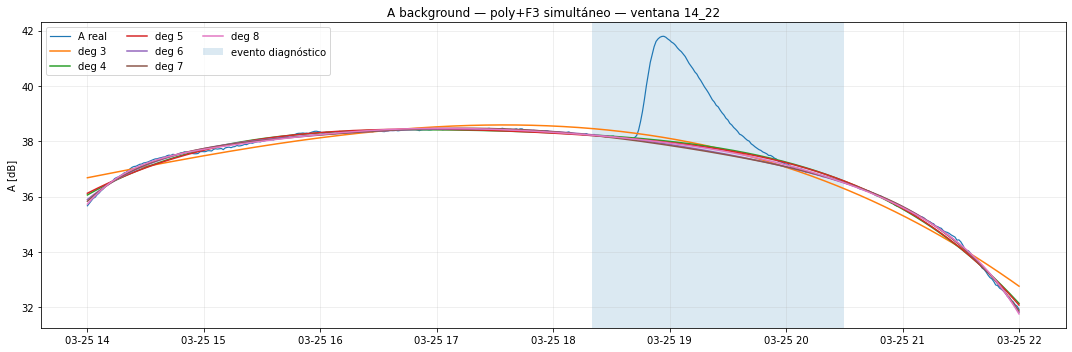

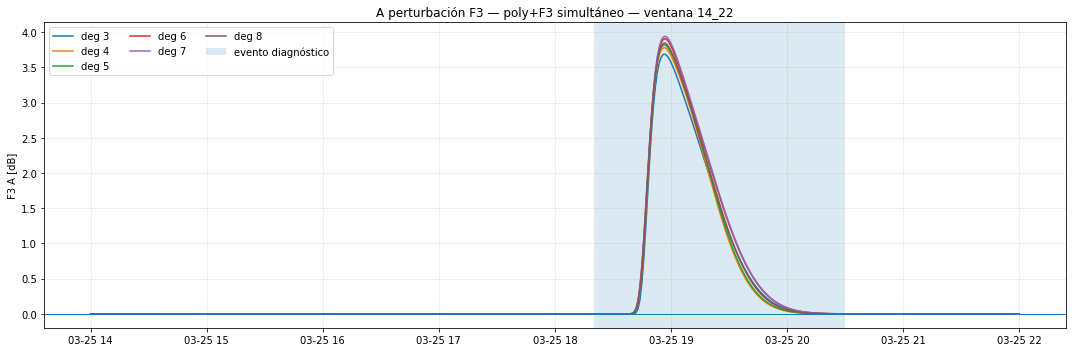

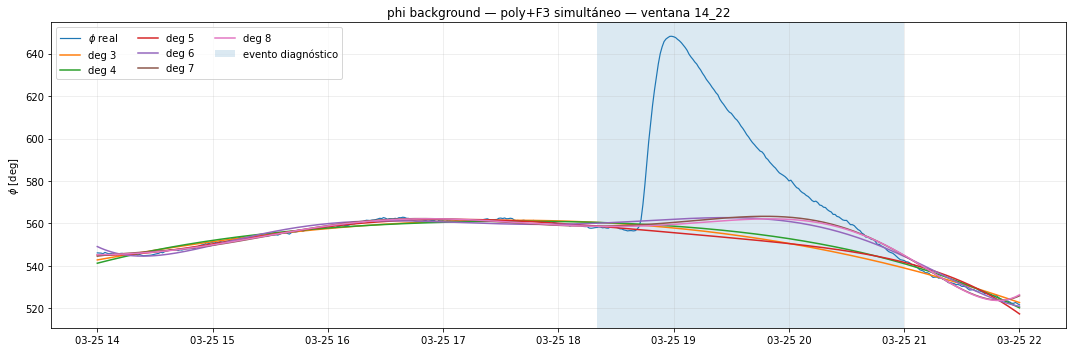

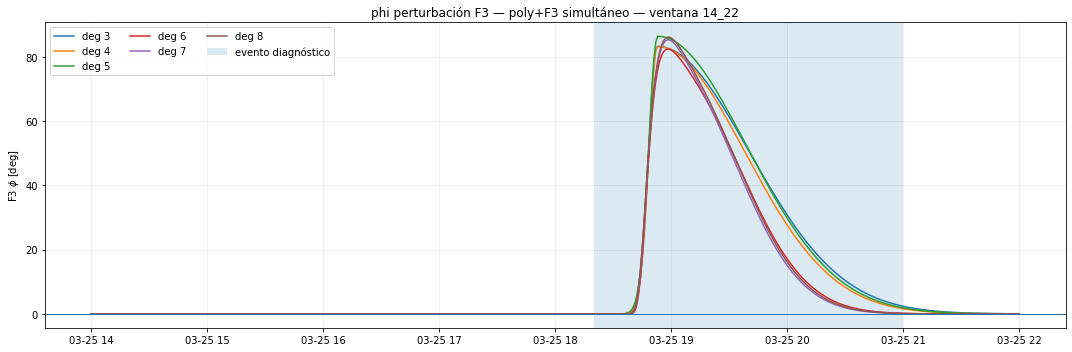

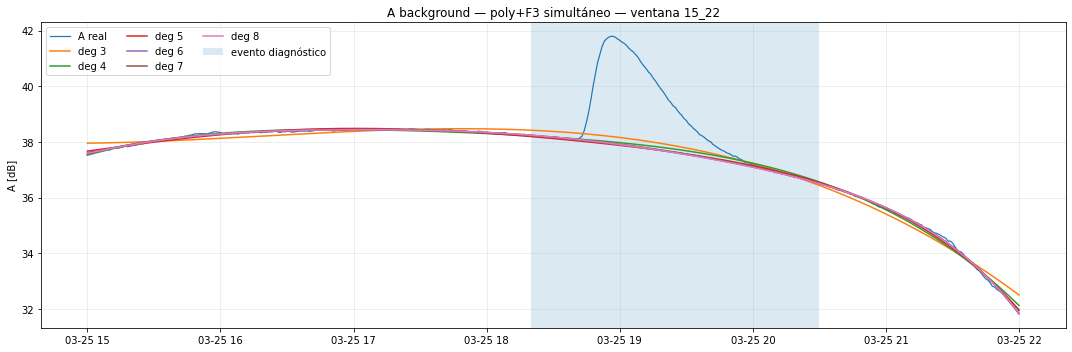

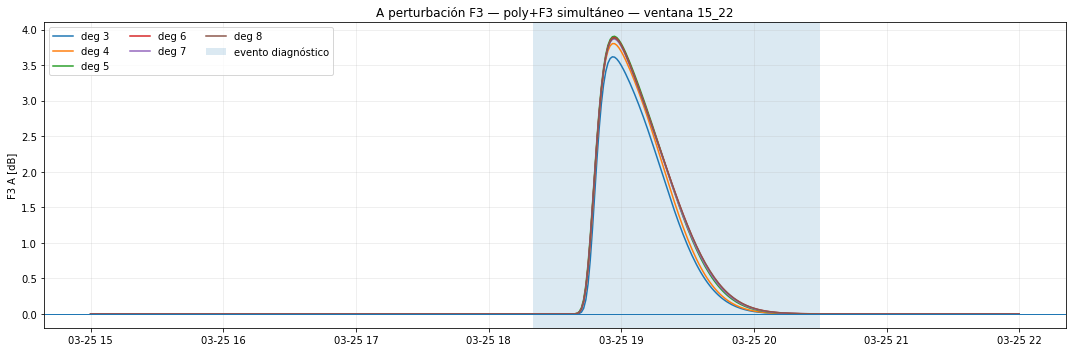

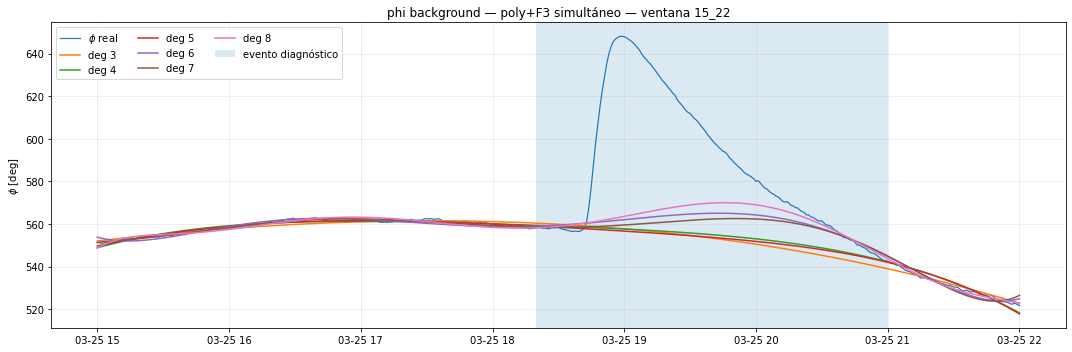

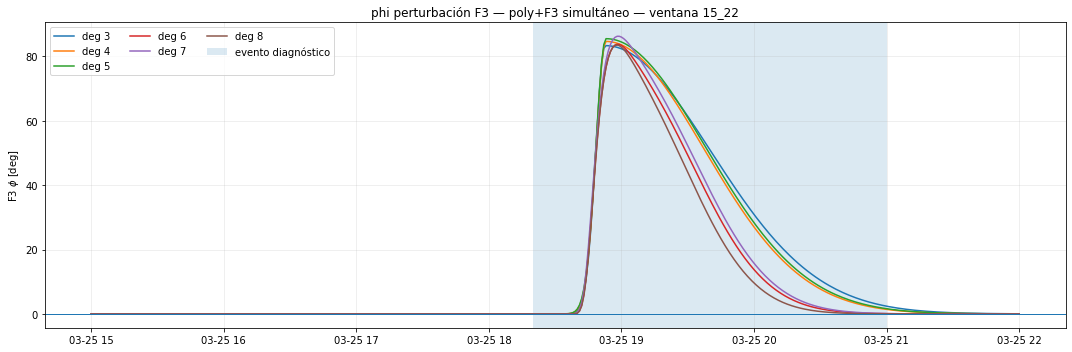

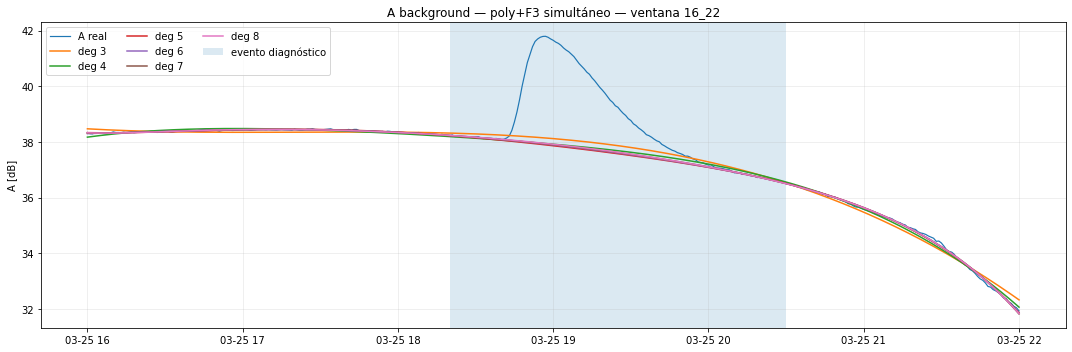

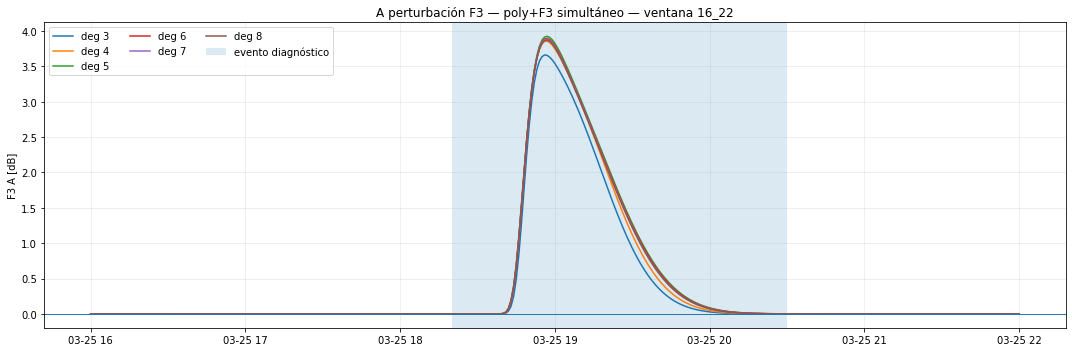

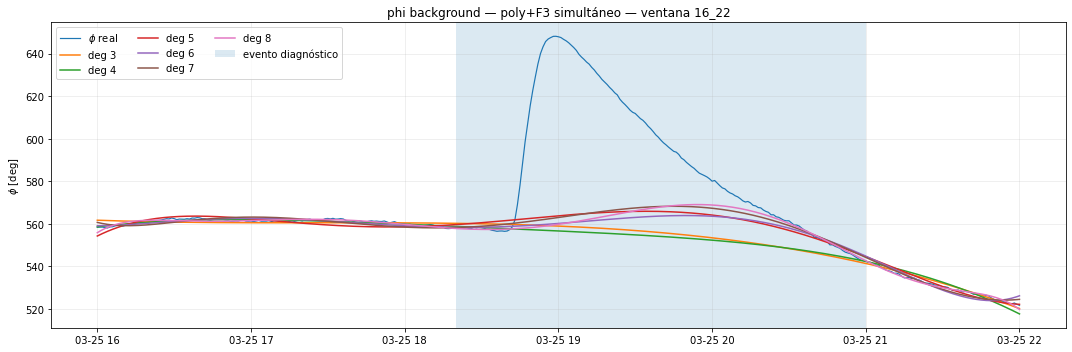

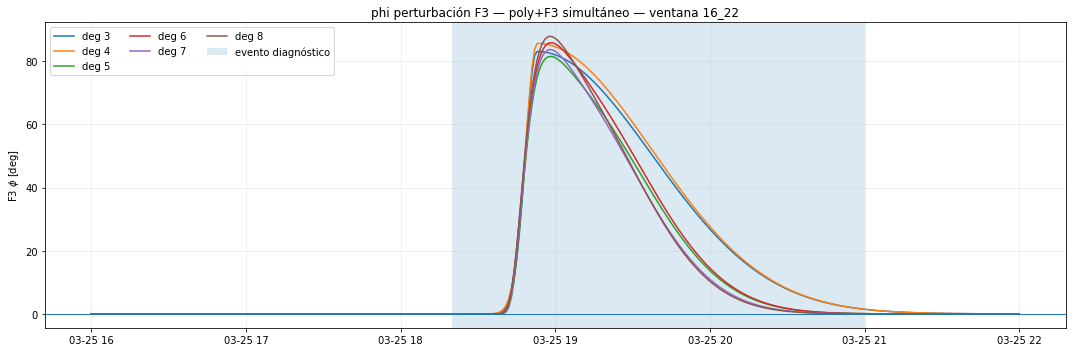

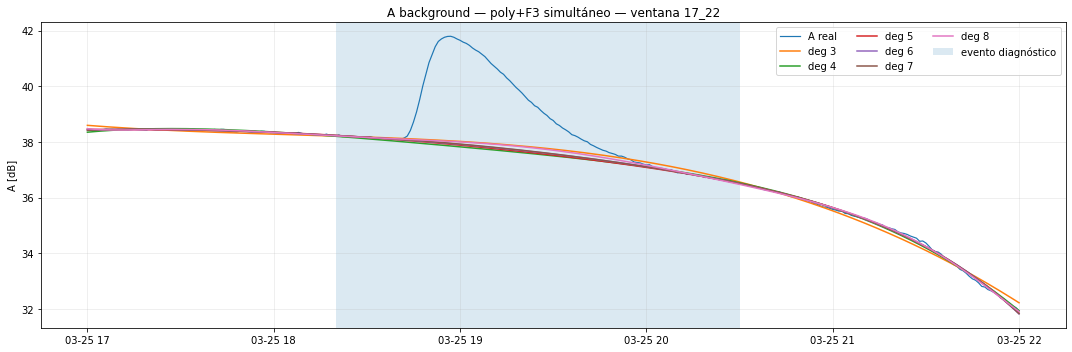

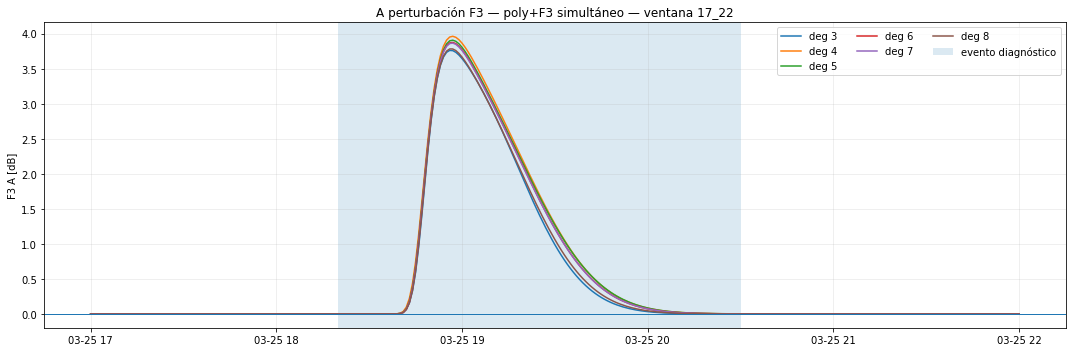

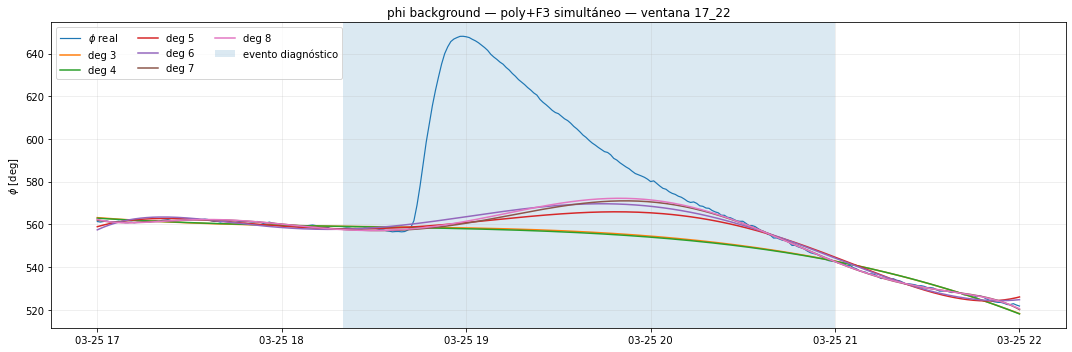

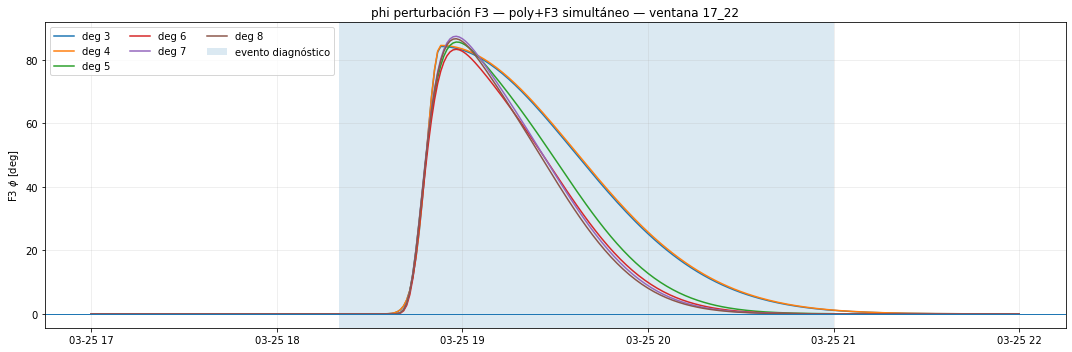

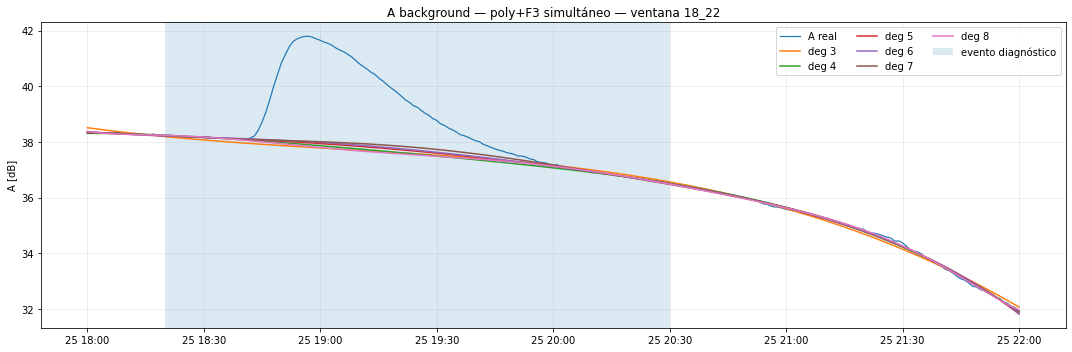

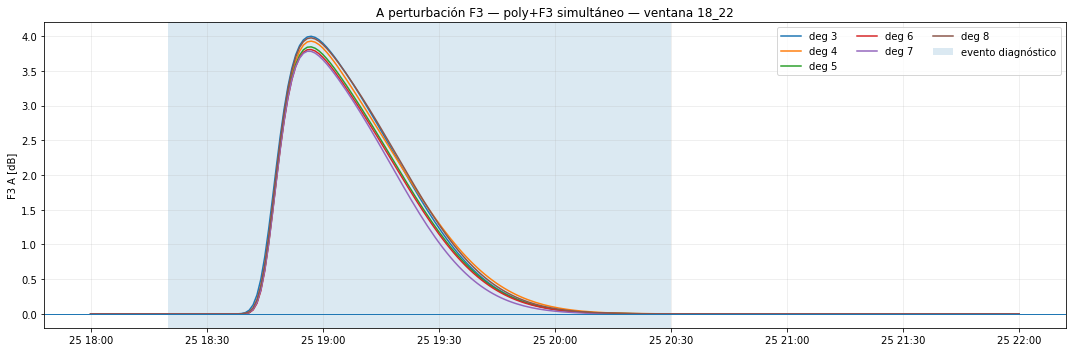

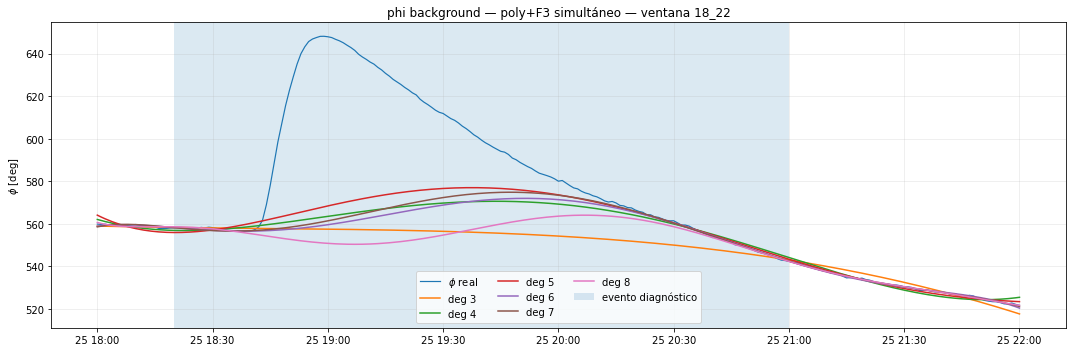

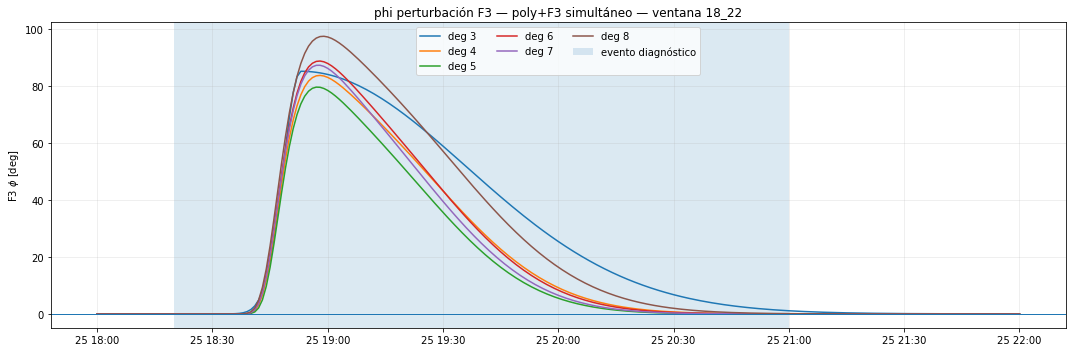

In [7]:
def shade_interval(ax, start, end, label=None, alpha=0.16):
    ax.axvspan(start, end, alpha=alpha, label=label)

# Figuras por ventana: backgrounds y F3 para grados 3--8
for h0 in WINDOW_START_HOURS:
    window_label = f"{h0:02d}_22"
    wstart = pd.Timestamp(f"{DATE_UTC} {h0:02d}:00:00", tz="UTC")
    df_plot = df_base.loc[(df_base.index >= wstart) & (df_base.index <= WINDOW_END)]

    # A backgrounds
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(df_plot.index, df_plot["A_real"], lw=1.2, label="A real")
    for deg in DEGREES_A:
        dfi = results_A[(window_label, deg)]
        ax.plot(dfi.index, dfi["A_real_background"], lw=1.5, label=f"deg {deg}")
    shade_interval(ax, A_EVENT_START, A_EVENT_END, "evento diagnóstico")
    ax.set_title(f"A background — poly+F3 simultáneo — ventana {window_label}")
    ax.set_ylabel("A [dB]")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.savefig(FIGDIR / f"A_background_degrees_window_{window_label}.png", dpi=200, bbox_inches="tight")
    plt.show()

    # A F3 perturbations
    fig, ax = plt.subplots(figsize=(15, 5))
    for deg in DEGREES_A:
        dfi = results_A[(window_label, deg)]
        ax.plot(dfi.index, dfi["A_real_F3"], lw=1.5, label=f"deg {deg}")
    ax.axhline(0, lw=1)
    shade_interval(ax, A_EVENT_START, A_EVENT_END, "evento diagnóstico")
    ax.set_title(f"A perturbación F3 — poly+F3 simultáneo — ventana {window_label}")
    ax.set_ylabel("F3 A [dB]")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.savefig(FIGDIR / f"A_F3_degrees_window_{window_label}.png", dpi=200, bbox_inches="tight")
    plt.show()

    # phi backgrounds
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(df_plot.index, df_plot["phi_real"], lw=1.2, label=r"$\phi$ real")
    for deg in DEGREES_PHI:
        dfi = results_phi[(window_label, deg)]
        ax.plot(dfi.index, dfi["phi_real_background"], lw=1.5, label=f"deg {deg}")
    shade_interval(ax, PHI_EVENT_START, PHI_EVENT_END, "evento diagnóstico")
    ax.set_title(f"phi background — poly+F3 simultáneo — ventana {window_label}")
    ax.set_ylabel(r"$\phi$ [deg]")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.savefig(FIGDIR / f"phi_background_degrees_window_{window_label}.png", dpi=200, bbox_inches="tight")
    plt.show()

    # phi F3 perturbations
    fig, ax = plt.subplots(figsize=(15, 5))
    for deg in DEGREES_PHI:
        dfi = results_phi[(window_label, deg)]
        ax.plot(dfi.index, dfi["phi_real_F3"], lw=1.5, label=f"deg {deg}")
    ax.axhline(0, lw=1)
    shade_interval(ax, PHI_EVENT_START, PHI_EVENT_END, "evento diagnóstico")
    ax.set_title(f"phi perturbación F3 — poly+F3 simultáneo — ventana {window_label}")
    ax.set_ylabel(r"F3 $\phi$ [deg]")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.savefig(FIGDIR / f"phi_F3_degrees_window_{window_label}.png", dpi=200, bbox_inches="tight")
    plt.show()

## 5. Heatmaps de métricas

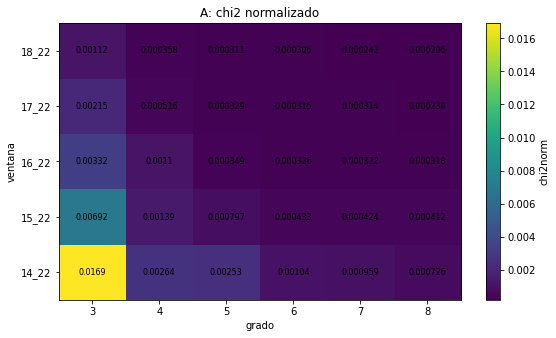

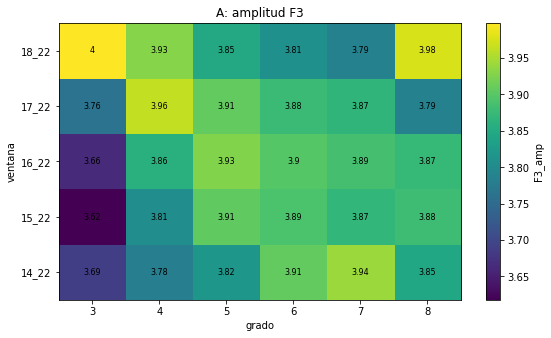

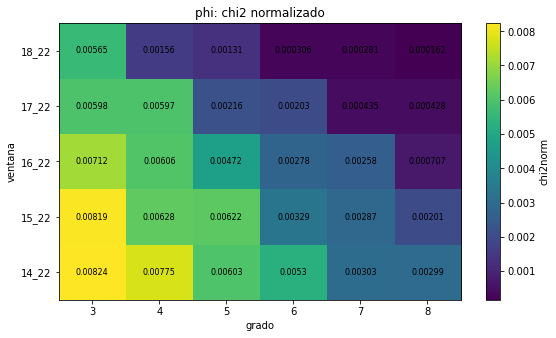

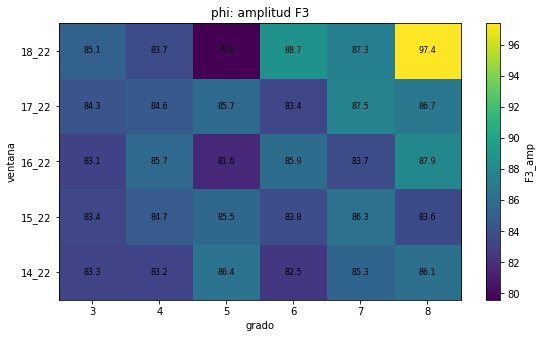

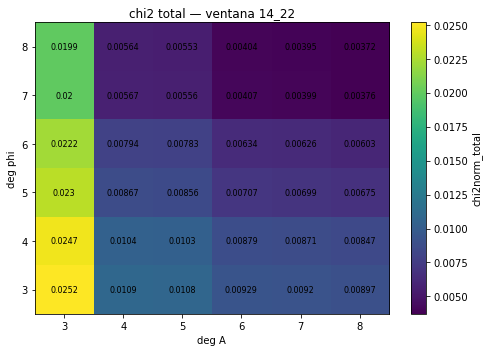

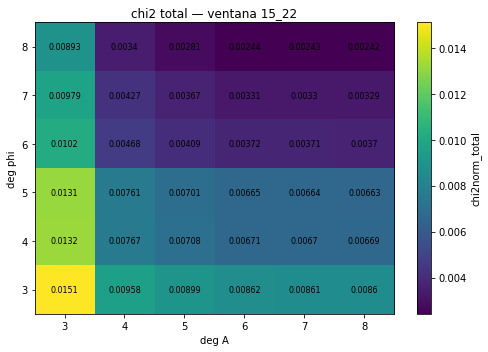

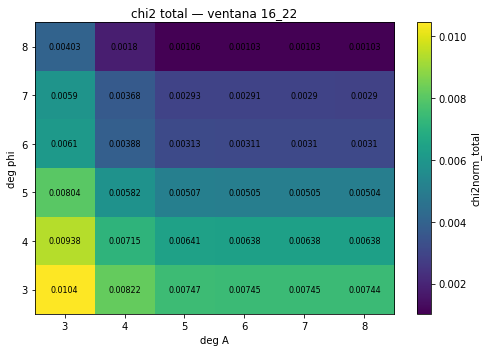

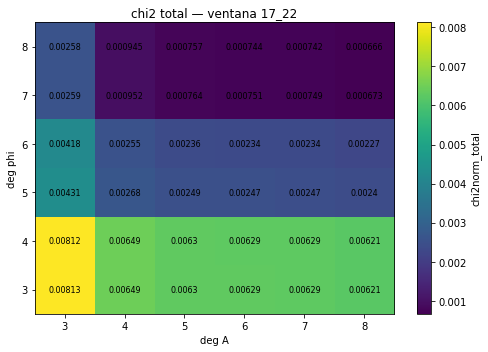

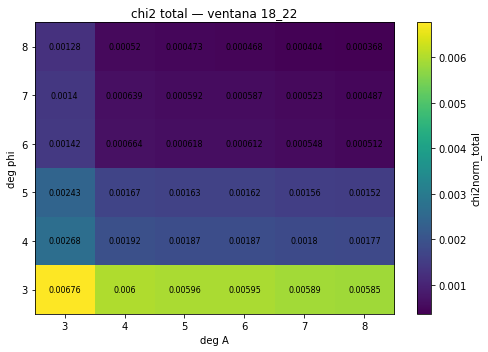

In [8]:
def heatmap_channel(dfm, value_col, title, fname):
    pivot = dfm.pivot(index="window_label", columns="degree", values=value_col)
    fig, ax = plt.subplots(figsize=(8, 4.8))
    im = ax.imshow(pivot.values, aspect="auto", origin="lower")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("grado")
    ax.set_ylabel("ventana")
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.3g}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label=value_col)
    plt.tight_layout()
    plt.savefig(FIGDIR / fname, dpi=200, bbox_inches="tight")
    plt.show()

heatmap_channel(metrics_A_df, "chi2norm", "A: chi2 normalizado", "heatmap_A_chi2norm.png")
heatmap_channel(metrics_A_df, "F3_amp", "A: amplitud F3", "heatmap_A_F3_amp.png")
heatmap_channel(metrics_phi_df, "chi2norm", "phi: chi2 normalizado", "heatmap_phi_chi2norm.png")
heatmap_channel(metrics_phi_df, "F3_amp", "phi: amplitud F3", "heatmap_phi_F3_amp.png")

# Heatmap combinado por ventana: degA × degPhi para chi2 total
for window_label in [f"{h:02d}_22" for h in WINDOW_START_HOURS]:
    sub = combo_df[combo_df["window_label"] == window_label]
    pivot = sub.pivot(index="deg_phi", columns="deg_A", values="chi2norm_total")
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(pivot.values, aspect="auto", origin="lower")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("deg A")
    ax.set_ylabel("deg phi")
    ax.set_title(f"chi2 total — ventana {window_label}")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.3g}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="chi2norm_total")
    plt.tight_layout()
    plt.savefig(FIGDIR / f"heatmap_total_chi2_degA_degPhi_window_{window_label}.png", dpi=200, bbox_inches="tight")
    plt.show()

## 6. Comparación del caso seleccionado y exportación HDF5

Por defecto, la selección manual queda en el caso antiguo esperado: ventana 16--22, `degA=7`, `degPhi=4`. Puedes editar `SELECTED_WINDOW_LABEL`, `SELECTED_DEG_A` y `SELECTED_DEG_PHI` arriba y reejecutar desde aquí.

Selección manual:
  window: 16_22
  degA: 7
  degPhi: 4
  N común: 361
  rango: 2008-03-25 16:00:00+00:00 -> 2008-03-25 22:00:00+00:00


,channel_col,window_start,window_end,degree,N,N_params,rss,rmse,mae,bias,...,F3_peak_signed_event,F3_area_abs_event,F3_area_signed_event,optimizer_cost,optimizer_nfev,optimizer_success,optimizer_message,channel,window_label,window_start_hour
16,A_real,2008-03-25 16:00:00+00:00,2008-03-25 22:00:00+00:00,7,361,13,0.467022,0.035968,0.025743,0.0,...,3.885176,2.28534,2.28534,0.467022,25,True,`ftol` termination condition is satisfied.,A,16_22,16


,channel_col,window_start,window_end,degree,N,N_params,rss,rmse,mae,bias,...,F3_peak_signed_event,F3_area_abs_event,F3_area_signed_event,optimizer_cost,optimizer_nfev,optimizer_success,optimizer_message,channel,window_label,window_start_hour
13,phi_real,2008-03-25 16:00:00+00:00,2008-03-25 22:00:00+00:00,4,361,10,1891.03246,2.288737,1.741594,0.000006,...,85.668415,87.643155,87.643155,1891.03246,26,True,`ftol` termination condition is satisfied.,phi,16_22,16


,window_label,window_start_hour,deg_A,deg_phi,chi2norm_A,chi2norm_phi,chi2norm_total,AIC_A,AIC_phi,AIC_total,BIC_A,BIC_phi,BIC_total,F3_A_amp,F3_phi_amp,F3_A_t_pk_utc,F3_phi_t_pk_utc,F3_A_area_abs_event,F3_phi_area_abs_event,rank_chi2_total
119,16_22,16,7,4,0.000322,0.006057,0.00638,-2374.742934,617.8161,-1756.926834,-2324.18752,656.704879,-1667.482641,3.885918,85.668469,2008-03-25 18:56:45.707465554+00:00,2008-03-25 18:52:57.929543202+00:00,2.28534,87.643155,120


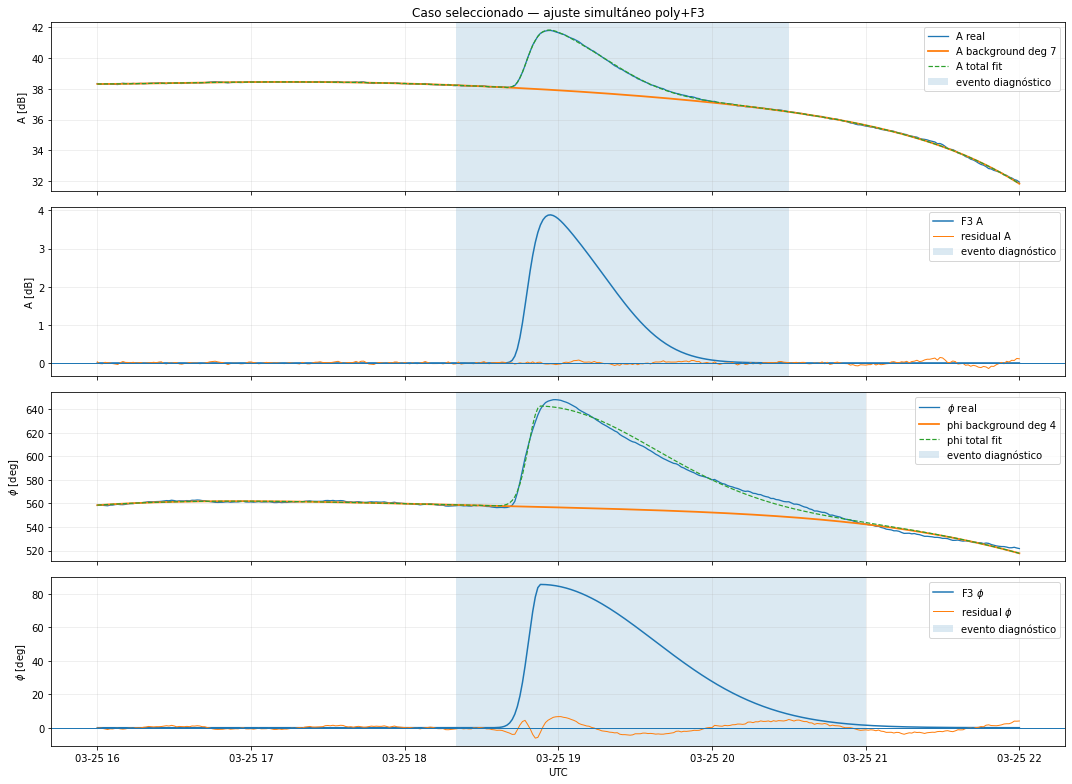

In [9]:
# Validación de selección
if (SELECTED_WINDOW_LABEL, SELECTED_DEG_A) not in results_A:
    raise KeyError(f"No existe resultado A para {(SELECTED_WINDOW_LABEL, SELECTED_DEG_A)}")
if (SELECTED_WINDOW_LABEL, SELECTED_DEG_PHI) not in results_phi:
    raise KeyError(f"No existe resultado phi para {(SELECTED_WINDOW_LABEL, SELECTED_DEG_PHI)}")

sel_A = results_A[(SELECTED_WINDOW_LABEL, SELECTED_DEG_A)]
sel_phi = results_phi[(SELECTED_WINDOW_LABEL, SELECTED_DEG_PHI)]

# Intersección temporal entre ambos canales seleccionados
sel = sel_A.join(sel_phi, how="inner", lsuffix="_A", rsuffix="_phi")

print("Selección manual:")
print("  window:", SELECTED_WINDOW_LABEL)
print("  degA:", SELECTED_DEG_A)
print("  degPhi:", SELECTED_DEG_PHI)
print("  N común:", len(sel))
print("  rango:", sel.index.min(), "->", sel.index.max())

# Métricas seleccionadas
sel_metrics_A = metrics_A_df[(metrics_A_df["window_label"] == SELECTED_WINDOW_LABEL) & (metrics_A_df["degree"] == SELECTED_DEG_A)]
sel_metrics_phi = metrics_phi_df[(metrics_phi_df["window_label"] == SELECTED_WINDOW_LABEL) & (metrics_phi_df["degree"] == SELECTED_DEG_PHI)]
sel_combo = combo_df[(combo_df["window_label"] == SELECTED_WINDOW_LABEL) & (combo_df["deg_A"] == SELECTED_DEG_A) & (combo_df["deg_phi"] == SELECTED_DEG_PHI)]

display(sel_metrics_A.round(6))
display(sel_metrics_phi.round(6))
display(sel_combo.round(6))

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
axes[0].plot(sel.index, sel["A_real"], lw=1.3, label="A real")
axes[0].plot(sel.index, sel["A_real_background"], lw=1.8, label=f"A background deg {SELECTED_DEG_A}")
axes[0].plot(sel.index, sel["A_real_total_fit"], lw=1.2, ls="--", label="A total fit")
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "evento diagnóstico")
axes[0].set_ylabel("A [dB]")
axes[0].set_title("Caso seleccionado — ajuste simultáneo poly+F3")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(sel.index, sel["A_real_F3"], lw=1.5, label="F3 A")
axes[1].plot(sel.index, sel["A_real_residual"], lw=1.0, label="residual A")
axes[1].axhline(0, lw=1)
shade_interval(axes[1], A_EVENT_START, A_EVENT_END, "evento diagnóstico")
axes[1].set_ylabel("A [dB]")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

axes[2].plot(sel.index, sel["phi_real"], lw=1.3, label=r"$\phi$ real")
axes[2].plot(sel.index, sel["phi_real_background"], lw=1.8, label=f"phi background deg {SELECTED_DEG_PHI}")
axes[2].plot(sel.index, sel["phi_real_total_fit"], lw=1.2, ls="--", label="phi total fit")
shade_interval(axes[2], PHI_EVENT_START, PHI_EVENT_END, "evento diagnóstico")
axes[2].set_ylabel(r"$\phi$ [deg]")
axes[2].grid(True, alpha=0.25)
axes[2].legend()

axes[3].plot(sel.index, sel["phi_real_F3"], lw=1.5, label=r"F3 $\phi$")
axes[3].plot(sel.index, sel["phi_real_residual"], lw=1.0, label=r"residual $\phi$")
axes[3].axhline(0, lw=1)
shade_interval(axes[3], PHI_EVENT_START, PHI_EVENT_END, "evento diagnóstico")
axes[3].set_ylabel(r"$\phi$ [deg]")
axes[3].set_xlabel("UTC")
axes[3].grid(True, alpha=0.25)
axes[3].legend()
plt.tight_layout()
plt.savefig(FIGDIR / f"selected_polyF3_window_{SELECTED_WINDOW_LABEL}_degA{SELECTED_DEG_A}_degPhi{SELECTED_DEG_PHI}.png", dpi=200, bbox_inches="tight")
plt.show()

In [10]:
def write_string_dataset(h5, name, values):
    values = np.asarray(values)
    values = np.array([str(v) for v in values.ravel()], dtype=object)
    dt = h5py.string_dtype(encoding="utf-8")
    if name in h5:
        del h5[name]
    h5.create_dataset(name, data=values, dtype=dt)


def write_metrics_group(h5, group_name, metrics_df):
    grp = h5.require_group(group_name)
    # Escribir columnas escalares como attrs si solo hay una fila
    if len(metrics_df) == 1:
        row = metrics_df.iloc[0]
        for k, v in row.items():
            try:
                if isinstance(v, pd.Timestamp):
                    grp.attrs[k] = str(v)
                elif isinstance(v, (np.integer, int)):
                    grp.attrs[k] = int(v)
                elif isinstance(v, (np.floating, float)):
                    grp.attrs[k] = float(v)
                else:
                    grp.attrs[k] = str(v)
            except Exception:
                grp.attrs[k] = str(v)

h5_name = f"simultaneous_polyF3_NAA_V_20080325_window{SELECTED_WINDOW_LABEL}_degA{SELECTED_DEG_A}_degPhi{SELECTED_DEG_PHI}.h5"
h5_path = H5DIR / h5_name

with h5py.File(h5_path, "w") as h5:
    write_string_dataset(h5, "timestamps_iso", sel.index.strftime("%Y-%m-%dT%H:%M:%SZ"))
    h5.create_dataset("time_unix", data=(sel.index.view("int64") // 10**9).astype(np.int64))

    # Amplitud
    h5.create_dataset("A_real", data=sel["A_real"].to_numpy(float))
    h5.create_dataset("A_background", data=sel["A_real_background"].to_numpy(float))
    h5.create_dataset("A_perturbation_F3", data=sel["A_real_F3"].to_numpy(float))
    h5.create_dataset("A_total_fit", data=sel["A_real_total_fit"].to_numpy(float))
    h5.create_dataset("A_residual", data=sel["A_real_residual"].to_numpy(float))

    # Fase
    h5.create_dataset("phi_real", data=sel["phi_real"].to_numpy(float))
    h5.create_dataset("phi_background", data=sel["phi_real_background"].to_numpy(float))
    h5.create_dataset("phi_perturbation_F3", data=sel["phi_real_F3"].to_numpy(float))
    h5.create_dataset("phi_total_fit", data=sel["phi_real_total_fit"].to_numpy(float))
    h5.create_dataset("phi_residual", data=sel["phi_real_residual"].to_numpy(float))

    # Máscaras diagnósticas
    h5.create_dataset("A_event_mask_diagnostic", data=np.asarray((sel.index >= A_EVENT_START) & (sel.index <= A_EVENT_END), dtype=bool))
    h5.create_dataset("phi_event_mask_diagnostic", data=np.asarray((sel.index >= PHI_EVENT_START) & (sel.index <= PHI_EVENT_END), dtype=bool))

    # Parámetros
    h5.create_dataset("params_A_vector", data=params_A[(SELECTED_WINDOW_LABEL, SELECTED_DEG_A)])
    h5.create_dataset("params_phi_vector", data=params_phi[(SELECTED_WINDOW_LABEL, SELECTED_DEG_PHI)])

    write_metrics_group(h5, "metrics_A", sel_metrics_A)
    write_metrics_group(h5, "metrics_phi", sel_metrics_phi)
    write_metrics_group(h5, "metrics_combined", sel_combo)

    h5.attrs["model"] = "simultaneous polynomial + asymmetric F3"
    h5.attrs["window_label"] = SELECTED_WINDOW_LABEL
    h5.attrs["degree_A"] = int(SELECTED_DEG_A)
    h5.attrs["degree_phi"] = int(SELECTED_DEG_PHI)
    h5.attrs["A_event_start_diagnostic"] = str(A_EVENT_START)
    h5.attrs["A_event_end_diagnostic"] = str(A_EVENT_END)
    h5.attrs["phi_event_start_diagnostic"] = str(PHI_EVENT_START)
    h5.attrs["phi_event_end_diagnostic"] = str(PHI_EVENT_END)
    h5.attrs["fit_note"] = "Event intervals are diagnostic only; no samples were excluded from the fit."

# Guardar CSV seleccionado
sel_out = sel.copy()
sel_out.index = sel_out.index.strftime("%Y-%m-%dT%H:%M:%SZ")
sel_out.to_csv(TABDIR / f"selected_polyF3_timeseries_window{SELECTED_WINDOW_LABEL}_degA{SELECTED_DEG_A}_degPhi{SELECTED_DEG_PHI}.csv")
sel_combo.to_csv(TABDIR / f"selected_polyF3_metrics_window{SELECTED_WINDOW_LABEL}_degA{SELECTED_DEG_A}_degPhi{SELECTED_DEG_PHI}.csv", index=False)

print("HDF5 guardado:", h5_path)
print("CSV guardado en:", TABDIR)

HDF5 guardado: outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/h5/simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5
CSV guardado en: outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/tables


## 7. Comparación opcional con el HDF5 antiguo correcto

Esta celda usa **solo** los nombres corregidos para el background antiguo:

- `real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5`
- `new_real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5`

No busca archivos genéricos tipo `deg6.h5`.

HDF5 antiguo usado: real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5
Muestras comunes: 361 2008-03-25 16:00:00+00:00 -> 2008-03-25 22:00:00+00:00


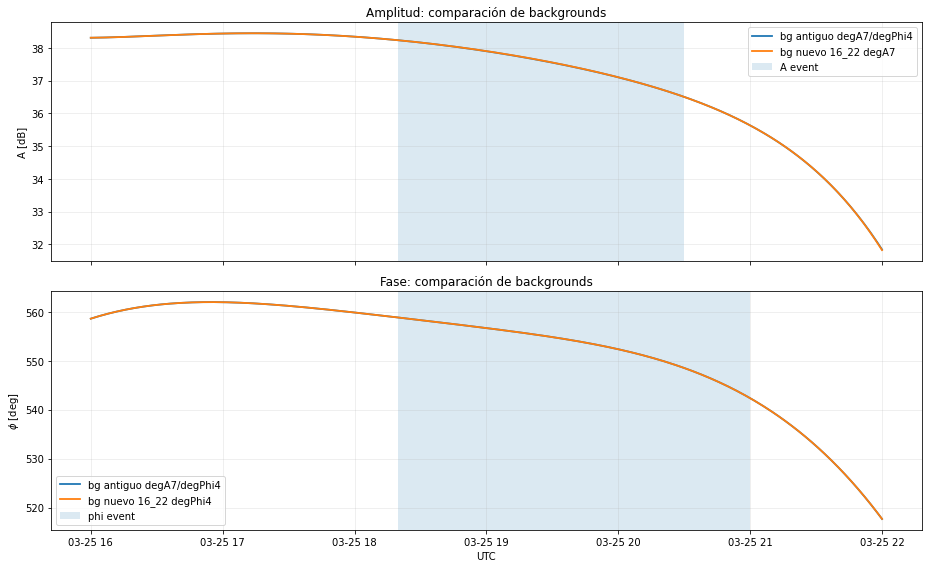

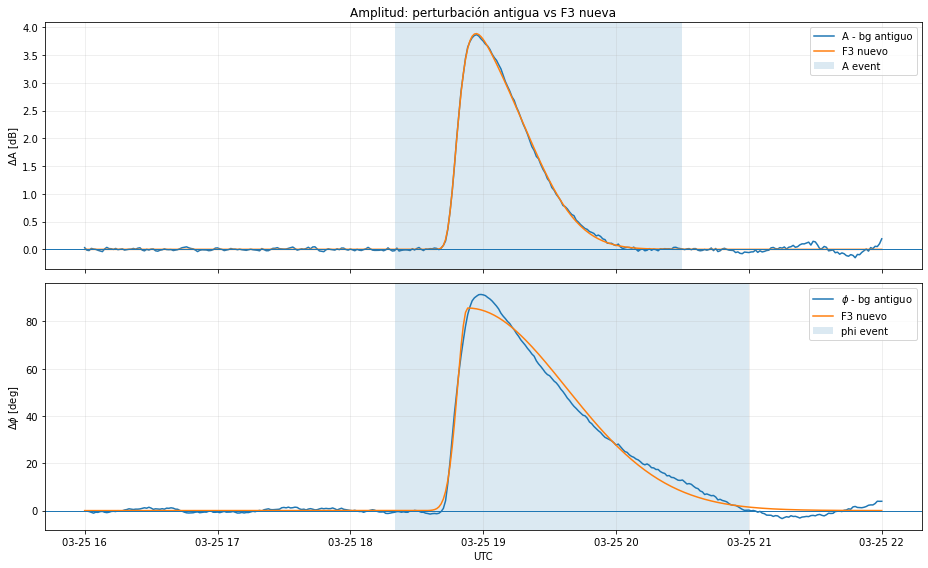

In [11]:
OLD_H5_CANDIDATES_EXACT = [
    Path("real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5"),
    Path("new_real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5"),
]


def find_exact_old_h5(candidates):
    for p in candidates:
        if p.exists():
            return p
    for p in candidates:
        hits = sorted(Path(".").rglob(p.name))
        hits = [h for h in hits if h.is_file()]
        if hits:
            return hits[0]
    return None


def decode_strings(arr):
    out = []
    for x in np.asarray(arr):
        out.append(x.decode("utf-8") if isinstance(x, bytes) else str(x))
    return np.array(out, dtype=object)


def to_datetime_robust(raw):
    arr = np.asarray(raw)
    if np.issubdtype(arr.dtype, np.number):
        vals = arr.astype(float)
        med = np.nanmedian(vals)
        if med > 1e14:
            return pd.to_datetime(vals, unit="us", utc=True)
        elif med > 1e11:
            return pd.to_datetime(vals, unit="ms", utc=True)
        else:
            return pd.to_datetime(vals, unit="s", utc=True)
    vals = decode_strings(arr)
    numeric_vals = pd.to_numeric(pd.Series(vals), errors="coerce")
    if numeric_vals.notna().mean() > 0.95:
        x = numeric_vals.to_numpy(float)
        med = np.nanmedian(x)
        if med > 1e14:
            return pd.to_datetime(x, unit="us", utc=True)
        elif med > 1e11:
            return pd.to_datetime(x, unit="ms", utc=True)
        else:
            return pd.to_datetime(x, unit="s", utc=True)
    return pd.to_datetime(vals, utc=True)


def read_dataset_first(h5, names, required=True):
    for name in names:
        if name in h5:
            return h5[name][()]
    all_names = []
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            all_names.append(name)
    h5.visititems(visitor)
    for candidate in names:
        for name in all_names:
            if name == candidate or name.endswith("/" + candidate):
                return h5[name][()]
    if required:
        raise KeyError(f"No encontré datasets {names}. Disponibles: {all_names}")
    return None


def load_old_background(path):
    with h5py.File(path, "r") as h5:
        t_raw = read_dataset_first(h5, ["timestamps_iso", "timestamps", "time_utc", "time_unix"], True)
        time = pd.DatetimeIndex(to_datetime_robust(t_raw), name="time_utc")
        A_real = read_dataset_first(h5, ["A_real"], True).astype(float)
        phi_real = read_dataset_first(h5, ["phi_real"], True).astype(float)
        A_bg = read_dataset_first(h5, ["A_background", "A_background_model"], True).astype(float)
        phi_bg = read_dataset_first(h5, ["phi_background", "phi_background_model"], True).astype(float)
    return pd.DataFrame({"A_real_old": A_real, "phi_real_old": phi_real, "A_bg_old": A_bg, "phi_bg_old": phi_bg}, index=time)

old_h5 = find_exact_old_h5(OLD_H5_CANDIDATES_EXACT)
if old_h5 is None:
    print("No se encontró HDF5 antiguo correcto. Se omite comparación.")
else:
    print("HDF5 antiguo usado:", old_h5)
    old = load_old_background(old_h5)
    new = pd.DataFrame({
        "A_real_new": sel["A_real"],
        "phi_real_new": sel["phi_real"],
        "A_bg_new": sel["A_real_background"],
        "phi_bg_new": sel["phi_real_background"],
        "A_F3_new": sel["A_real_F3"],
        "phi_F3_new": sel["phi_real_F3"],
    }, index=sel.index)
    cmp = new.join(old, how="inner")
    cmp["A_pert_old_from_bg"] = cmp["A_real_old"] - cmp["A_bg_old"]
    cmp["phi_pert_old_from_bg"] = cmp["phi_real_old"] - cmp["phi_bg_old"]

    print("Muestras comunes:", len(cmp), cmp.index.min(), "->", cmp.index.max())

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    axes[0].plot(cmp.index, cmp["A_bg_old"], lw=1.8, label="bg antiguo degA7/degPhi4")
    axes[0].plot(cmp.index, cmp["A_bg_new"], lw=1.8, label=f"bg nuevo {SELECTED_WINDOW_LABEL} degA{SELECTED_DEG_A}")
    shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
    axes[0].set_ylabel("A [dB]")
    axes[0].set_title("Amplitud: comparación de backgrounds")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend()

    axes[1].plot(cmp.index, cmp["phi_bg_old"], lw=1.8, label="bg antiguo degA7/degPhi4")
    axes[1].plot(cmp.index, cmp["phi_bg_new"], lw=1.8, label=f"bg nuevo {SELECTED_WINDOW_LABEL} degPhi{SELECTED_DEG_PHI}")
    shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
    axes[1].set_ylabel(r"$\phi$ [deg]")
    axes[1].set_xlabel("UTC")
    axes[1].set_title("Fase: comparación de backgrounds")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(FIGDIR / f"comparison_selected_polyF3_vs_old_backgrounds.png", dpi=200, bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    axes[0].plot(cmp.index, cmp["A_pert_old_from_bg"], lw=1.5, label="A - bg antiguo")
    axes[0].plot(cmp.index, cmp["A_F3_new"], lw=1.5, label="F3 nuevo")
    axes[0].axhline(0, lw=1)
    shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
    axes[0].set_ylabel("ΔA [dB]")
    axes[0].set_title("Amplitud: perturbación antigua vs F3 nueva")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend()

    axes[1].plot(cmp.index, cmp["phi_pert_old_from_bg"], lw=1.5, label=r"$\phi$ - bg antiguo")
    axes[1].plot(cmp.index, cmp["phi_F3_new"], lw=1.5, label="F3 nuevo")
    axes[1].axhline(0, lw=1)
    shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
    axes[1].set_ylabel(r"$\Delta\phi$ [deg]")
    axes[1].set_xlabel("UTC")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(FIGDIR / f"comparison_selected_polyF3_vs_old_perturbations.png", dpi=200, bbox_inches="tight")
    plt.show()

    cmp_out = cmp.copy()
    cmp_out.index = cmp_out.index.strftime("%Y-%m-%dT%H:%M:%SZ")
    cmp_out.to_csv(TABDIR / "comparison_selected_polyF3_vs_old_background_timeseries.csv")

## 8. Archivos generados

Las salidas quedan en:

```text
outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/
├── figures/
├── tables/
└── h5/
```

El punto clave del análisis será comparar si el caso antiguo `16_22, degA=7, degPhi=4` permanece como solución robusta dentro de esta grilla o si aparece una alternativa simultánea más estable.

Poly+F3 HDF5:
  outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/h5/simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5
ASLS HDF5:
  datos_asls_full-v3.h5
Whittaker HDF5:
  real_whittaker_selected_background_16_22_for_inversion.h5

Rango Poly+F3:
  2008-03-25 16:00:00+00:00 -> 2008-03-25 22:00:00+00:00  N=361
Rango ASLS 1min:
  2008-03-25 17:00:00+00:00 -> 2008-03-25 22:59:00+00:00  N=360
Rango Whittaker:
  2008-03-25 16:00:00+00:00 -> 2008-03-25 22:00:00+00:00  N=361

Rango común usado:
  2008-03-25 17:00:00+00:00 -> 2008-03-25 22:00:00+00:00  N=301

Diferencias de background respecto a Poly+F3:


,channel,comparison,region,N,mean,median,std,rmse,max_abs
0,A,ASLS - PolyF3,common_all,301,-0.237616,-0.182310,0.154345,0.283344,0.567981
1,A,ASLS - PolyF3,event,131,-0.132678,-0.118234,0.059264,0.145313,0.296388
2,A,Whittaker - PolyF3,common_all,301,0.020690,0.012712,0.042821,0.047558,0.166782
3,A,Whittaker - PolyF3,event,131,0.047115,0.052416,0.029870,0.055786,0.083852
4,phi,ASLS - PolyF3,common_all,301,-2.583920,-2.237048,4.069558,4.820575,10.135020
5,phi,ASLS - PolyF3,event,161,0.745329,1.224308,1.817884,1.964743,3.531956
6,phi,Whittaker - PolyF3,common_all,301,-1.829966,-1.793426,1.948375,2.673002,4.562850
7,phi,Whittaker - PolyF3,event,161,-2.950377,-3.138603,1.335836,3.238701,4.562850



Perturbaciones calculadas como datos de referencia - background:


/tmp/ipykernel_54060/236996665.py:414: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.abs(y[mask]), t_hours))
/tmp/ipykernel_54060/236996665.py:426: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y[mask], t_hours))


,channel,method,N_event,peak_abs_event,peak_signed_event,area_abs_event,area_signed_event
0,A,PolyF3,131,3.862602,3.862602,2.297365,2.287791
1,A,ASLS,131,3.958807,3.958807,2.573580,2.573580
2,A,Whittaker,131,3.824279,3.824279,2.220805,2.184921
3,phi,PolyF3,161,91.410080,91.410080,89.028818,88.524645
4,phi,ASLS,161,91.400377,91.400377,86.482098,86.482098
5,phi,Whittaker,161,93.130878,93.130878,96.466174,96.402226


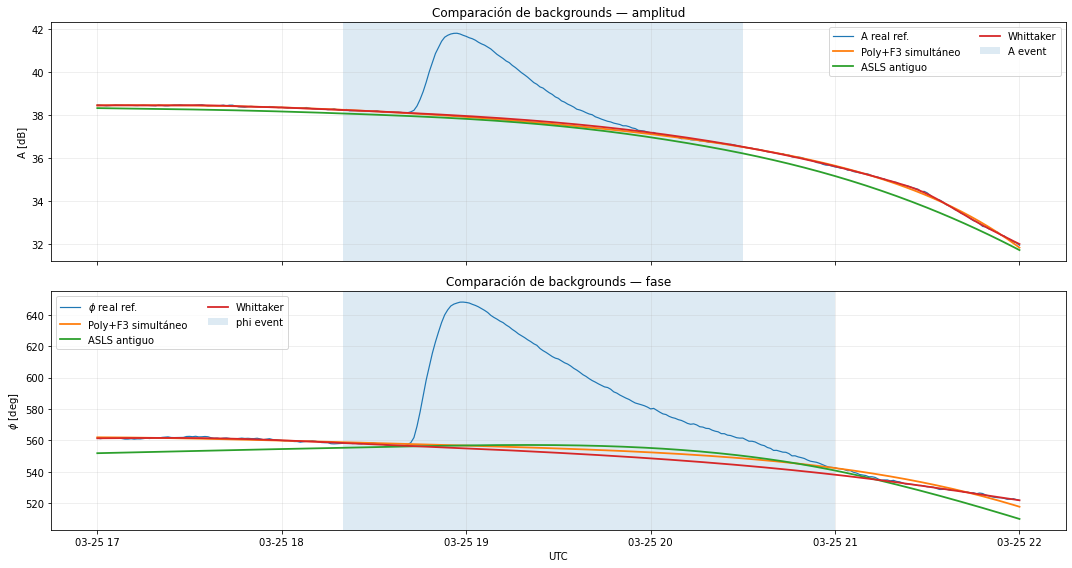

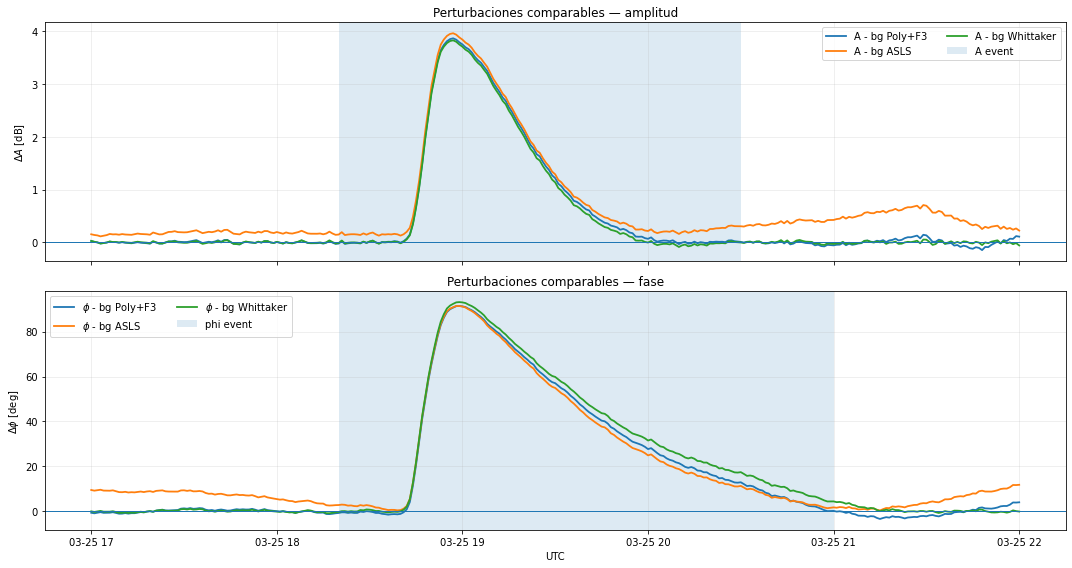

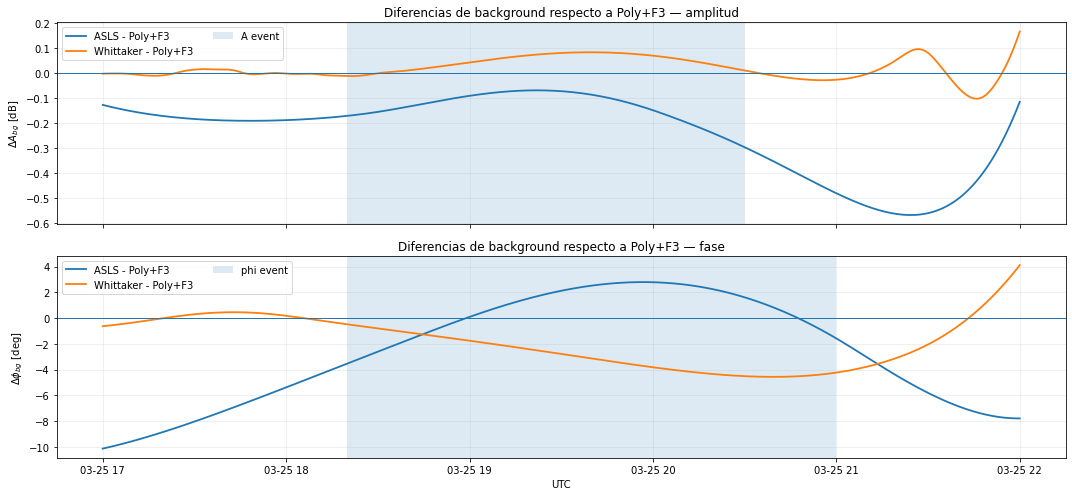


Archivos guardados en:
  /home/jp/basefolder_JP/outputs_compare_polyF3_ASLS_Whittaker

Figuras:
  backgrounds_polyF3_ASLS_Whittaker.png
  perturbations_polyF3_ASLS_Whittaker.png
  background_differences_ASLS_Whittaker_minus_polyF3.png

Tablas:
  background_difference_ASLS_Whittaker_vs_polyF3_summary.csv
  perturbation_metrics_ASLS_Whittaker_vs_polyF3_summary.csv
  timeseries_polyF3_ASLS_Whittaker_common_interval.csv


In [12]:
# ============================================================
# Comparación:
#   Poly+F3 simultáneo seleccionado
#     window = 16:00–22:00
#     degA   = 7
#     degPhi = 4
#
# contra:
#   1) background ASLS antiguo: datos_asls_full-v3.h5
#   2) background Whittaker:    real_whittaker_selected_background_16_22_for_inversion.h5
#
# La comparación usa timestamps comunes. Como ASLS empieza en 17:00,
# el intervalo común efectivo será normalmente 17:00–22:00 UTC.
# ============================================================

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1) Archivos
# ============================================================

POLYF3_CANDIDATES = [
    Path(
        "outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/"
        "h5/simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5"
    ),
    Path(
        "outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325_extracted/"
        "outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/"
        "h5/simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5"
    ),
    Path(
        "win_deg/outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/"
        "h5/simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5"
    ),
]

ASLS_CANDIDATES = [
    Path("datos_asls_full-v3.h5"),
    Path("/mnt/data/datos_asls_full-v3.h5"),
]

WHITTAKER_CANDIDATES = [
    Path("real_whittaker_selected_background_16_22_for_inversion.h5"),
    Path("/mnt/data/real_whittaker_selected_background_16_22_for_inversion.h5"),
]

OUTDIR = Path("outputs_compare_polyF3_ASLS_Whittaker")
OUTDIR.mkdir(parents=True, exist_ok=True)


def find_file(candidates, recursive_name=None):
    for p in candidates:
        if p.exists():
            return p

    if recursive_name is not None:
        hits = sorted(Path(".").rglob(recursive_name))
        hits = [h for h in hits if h.is_file()]
        if len(hits) > 0:
            return hits[0]

    return None


POLYF3_H5 = find_file(
    POLYF3_CANDIDATES,
    recursive_name="simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5",
)

ASLS_H5 = find_file(
    ASLS_CANDIDATES,
    recursive_name="datos_asls_full-v3.h5",
)

WHITTAKER_H5 = find_file(
    WHITTAKER_CANDIDATES,
    recursive_name="real_whittaker_selected_background_16_22_for_inversion.h5",
)

if POLYF3_H5 is None:
    raise FileNotFoundError(
        "No encontré el HDF5 Poly+F3 simultáneo seleccionado:\n"
        "  simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5"
    )

if ASLS_H5 is None:
    raise FileNotFoundError(
        "No encontré el HDF5 ASLS antiguo:\n"
        "  datos_asls_full-v3.h5"
    )

if WHITTAKER_H5 is None:
    raise FileNotFoundError(
        "No encontré el HDF5 Whittaker:\n"
        "  real_whittaker_selected_background_16_22_for_inversion.h5"
    )

print("Poly+F3 HDF5:")
print(" ", POLYF3_H5)
print("ASLS HDF5:")
print(" ", ASLS_H5)
print("Whittaker HDF5:")
print(" ", WHITTAKER_H5)

# ============================================================
# 2) Utilidades de lectura
# ============================================================

def decode_strings(arr):
    arr = np.asarray(arr)
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.array(out, dtype=object)


def to_datetime_robust(raw):
    arr = np.asarray(raw)

    if np.issubdtype(arr.dtype, np.number):
        vals = arr.astype(float)
        med = np.nanmedian(vals)

        if med > 1e14:
            return pd.to_datetime(vals, unit="us", utc=True)
        elif med > 1e11:
            return pd.to_datetime(vals, unit="ms", utc=True)
        else:
            return pd.to_datetime(vals, unit="s", utc=True)

    vals = decode_strings(arr)

    numeric_vals = pd.to_numeric(pd.Series(vals), errors="coerce")
    frac_numeric = numeric_vals.notna().mean()

    if frac_numeric > 0.95:
        x = numeric_vals.to_numpy(dtype=float)
        med = np.nanmedian(x)

        if med > 1e14:
            return pd.to_datetime(x, unit="us", utc=True)
        elif med > 1e11:
            return pd.to_datetime(x, unit="ms", utc=True)
        else:
            return pd.to_datetime(x, unit="s", utc=True)

    return pd.to_datetime(vals, utc=True)


def read_dataset_first(h5, names, required=True):
    for name in names:
        if name in h5:
            return h5[name][()]

    all_names = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            all_names.append(name)

    h5.visititems(visitor)

    for candidate in names:
        for name in all_names:
            if name == candidate or name.endswith("/" + candidate):
                return h5[name][()]

    if required:
        raise KeyError(
            "No encontré ninguno de estos datasets:\n"
            f"  {names}\n"
            "Datasets disponibles:\n"
            + "\n".join([f"  {k}" for k in all_names])
        )

    return None


def read_time_index(h5):
    raw = read_dataset_first(
        h5,
        [
            "timestamps_iso",
            "timestamps",
            "timestamps_unix",
            "time_unix",
            "unix_timestamps",
            "time_utc",
        ],
        required=True,
    )
    return pd.DatetimeIndex(to_datetime_robust(raw), name="time_utc")


# ============================================================
# 3) Lectores específicos
# ============================================================

def load_polyF3(path):
    with h5py.File(path, "r") as h5:
        t = read_time_index(h5)

        df = pd.DataFrame(
            {
                "A_real_polyF3": np.asarray(h5["A_real"][()], dtype=float),
                "phi_real_polyF3": np.asarray(h5["phi_real"][()], dtype=float),
                "A_bg_polyF3": np.asarray(h5["A_background"][()], dtype=float),
                "phi_bg_polyF3": np.asarray(h5["phi_background"][()], dtype=float),
                "A_F3_polyF3": np.asarray(h5["A_perturbation_F3"][()], dtype=float),
                "phi_F3_polyF3": np.asarray(h5["phi_perturbation_F3"][()], dtype=float),
            },
            index=t,
        )

    df["A_pert_polyF3_from_bg"] = df["A_real_polyF3"] - df["A_bg_polyF3"]
    df["phi_pert_polyF3_from_bg"] = df["phi_real_polyF3"] - df["phi_bg_polyF3"]

    return df[~df.index.duplicated(keep="first")].sort_index()


def load_asls(path):
    with h5py.File(path, "r") as h5:
        t = pd.DatetimeIndex(
            pd.to_datetime(h5["time_unix"][()], unit="s", utc=True),
            name="time_utc",
        )

        A_bg = np.asarray(h5["baseline_asls_amp"][()], dtype=float)
        phi_bg = np.asarray(h5["baseline_asls_phi"][()], dtype=float)

        A_pert = np.asarray(h5["detrended_asls_amp"][()], dtype=float)
        phi_pert = np.asarray(h5["detrended_asls_phi"][()], dtype=float)

        A_real = A_bg + A_pert
        phi_real = phi_bg + phi_pert

    df = pd.DataFrame(
        {
            "A_real_ASLS_native": A_real,
            "phi_real_ASLS_native": phi_real,
            "A_bg_ASLS": A_bg,
            "phi_bg_ASLS": phi_bg,
            "A_pert_ASLS_native": A_pert,
            "phi_pert_ASLS_native": phi_pert,
        },
        index=t,
    )

    df = df[~df.index.duplicated(keep="first")].sort_index()

    # ASLS está a 1 s; pasamos a 1 min para comparar con Poly+F3 y Whittaker.
    df_1min = df.resample("1min").median(numeric_only=True)

    return df_1min


def load_whittaker(path):
    with h5py.File(path, "r") as h5:
        t = read_time_index(h5)

        df = pd.DataFrame(
            {
                "A_real_Whittaker": np.asarray(h5["A_real"][()], dtype=float),
                "phi_real_Whittaker": np.asarray(h5["phi_real"][()], dtype=float),
                "A_bg_Whittaker": np.asarray(h5["A_background"][()], dtype=float),
                "phi_bg_Whittaker": np.asarray(h5["phi_background"][()], dtype=float),
            },
            index=t,
        )

        if "A_perturbation" in h5:
            df["A_pert_Whittaker_native"] = np.asarray(h5["A_perturbation"][()], dtype=float)

        if "phi_perturbation" in h5:
            df["phi_pert_Whittaker_native"] = np.asarray(h5["phi_perturbation"][()], dtype=float)

    df["A_pert_Whittaker_from_bg"] = df["A_real_Whittaker"] - df["A_bg_Whittaker"]
    df["phi_pert_Whittaker_from_bg"] = df["phi_real_Whittaker"] - df["phi_bg_Whittaker"]

    return df[~df.index.duplicated(keep="first")].sort_index()


df_poly = load_polyF3(POLYF3_H5)
df_asls = load_asls(ASLS_H5)
df_whit = load_whittaker(WHITTAKER_H5)

# ============================================================
# 4) Unión temporal y referencia común
# ============================================================

df = df_poly.join(df_asls, how="outer").join(df_whit, how="outer")
df = df.sort_index()

# Para comparación justa, usamos una sola serie real de referencia:
# la de Poly+F3 seleccionado, porque es el resultado actual.
df["A_ref"] = df["A_real_polyF3"]
df["phi_ref"] = df["phi_real_polyF3"]

# Perturbaciones comparables = datos de referencia - background de cada método.
df["A_pert_polyF3"] = df["A_ref"] - df["A_bg_polyF3"]
df["A_pert_ASLS"] = df["A_ref"] - df["A_bg_ASLS"]
df["A_pert_Whittaker"] = df["A_ref"] - df["A_bg_Whittaker"]

df["phi_pert_polyF3"] = df["phi_ref"] - df["phi_bg_polyF3"]
df["phi_pert_ASLS"] = df["phi_ref"] - df["phi_bg_ASLS"]
df["phi_pert_Whittaker"] = df["phi_ref"] - df["phi_bg_Whittaker"]

# Intervalo común real donde existen los tres backgrounds y la referencia.
required_common = [
    "A_ref",
    "phi_ref",
    "A_bg_polyF3",
    "phi_bg_polyF3",
    "A_bg_ASLS",
    "phi_bg_ASLS",
    "A_bg_Whittaker",
    "phi_bg_Whittaker",
]

df_common = df.dropna(subset=required_common).copy()

if len(df_common) == 0:
    raise ValueError(
        "No hay timestamps comunes entre Poly+F3, ASLS y Whittaker. "
        "Revisa rangos temporales y resolución."
    )

print("\nRango Poly+F3:")
print(f"  {df_poly.index.min()} -> {df_poly.index.max()}  N={len(df_poly)}")
print("Rango ASLS 1min:")
print(f"  {df_asls.index.min()} -> {df_asls.index.max()}  N={len(df_asls)}")
print("Rango Whittaker:")
print(f"  {df_whit.index.min()} -> {df_whit.index.max()}  N={len(df_whit)}")
print("\nRango común usado:")
print(f"  {df_common.index.min()} -> {df_common.index.max()}  N={len(df_common)}")

# Máscaras diagnósticas.
A_EVENT_START = pd.Timestamp("2008-03-25 18:20:00", tz="UTC")
A_EVENT_END   = pd.Timestamp("2008-03-25 20:30:00", tz="UTC")

PHI_EVENT_START = pd.Timestamp("2008-03-25 18:20:00", tz="UTC")
PHI_EVENT_END   = pd.Timestamp("2008-03-25 21:00:00", tz="UTC")

A_event_mask = np.asarray(
    (df_common.index >= A_EVENT_START) & (df_common.index <= A_EVENT_END),
    dtype=bool,
)

phi_event_mask = np.asarray(
    (df_common.index >= PHI_EVENT_START) & (df_common.index <= PHI_EVENT_END),
    dtype=bool,
)

# ============================================================
# 5) Métricas
# ============================================================

def summarize_diff(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return {
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "rmse": np.nan,
            "max_abs": np.nan,
        }

    return {
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "std": float(np.std(x)),
        "rmse": float(np.sqrt(np.mean(x**2))),
        "max_abs": float(np.max(np.abs(x))),
    }


def peak_abs(series, mask):
    x = np.asarray(series[mask], dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    return float(np.max(np.abs(x)))


def signed_peak(series, mask):
    x = np.asarray(series[mask], dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    i = int(np.argmax(np.abs(x)))
    return float(x[i])


def area_abs(index, series, mask):
    idx = pd.DatetimeIndex(index)
    y = np.asarray(series, dtype=float)
    mask = np.asarray(mask, dtype=bool) & np.isfinite(y)

    if np.sum(mask) < 2:
        return np.nan

    t_hours = (idx[mask] - idx[mask][0]).total_seconds().to_numpy() / 3600.0
    return float(np.trapz(np.abs(y[mask]), t_hours))


def area_signed(index, series, mask):
    idx = pd.DatetimeIndex(index)
    y = np.asarray(series, dtype=float)
    mask = np.asarray(mask, dtype=bool) & np.isfinite(y)

    if np.sum(mask) < 2:
        return np.nan

    t_hours = (idx[mask] - idx[mask][0]).total_seconds().to_numpy() / 3600.0
    return float(np.trapz(y[mask], t_hours))


# Diferencias de backgrounds respecto a Poly+F3.
diff_rows = []

for channel, bg_ref, bg_other, mask_event, label_other in [
    ("A", "A_bg_polyF3", "A_bg_ASLS", A_event_mask, "ASLS"),
    ("A", "A_bg_polyF3", "A_bg_Whittaker", A_event_mask, "Whittaker"),
    ("phi", "phi_bg_polyF3", "phi_bg_ASLS", phi_event_mask, "ASLS"),
    ("phi", "phi_bg_polyF3", "phi_bg_Whittaker", phi_event_mask, "Whittaker"),
]:
    diff_all = df_common[bg_other] - df_common[bg_ref]
    diff_event = diff_all[mask_event]

    s_all = summarize_diff(diff_all)
    s_event = summarize_diff(diff_event)

    s_all.update({
        "channel": channel,
        "comparison": f"{label_other} - PolyF3",
        "region": "common_all",
        "N": len(diff_all),
    })

    s_event.update({
        "channel": channel,
        "comparison": f"{label_other} - PolyF3",
        "region": "event",
        "N": int(np.sum(mask_event)),
    })

    diff_rows.append(s_all)
    diff_rows.append(s_event)

diff_summary = pd.DataFrame(diff_rows)[
    ["channel", "comparison", "region", "N", "mean", "median", "std", "rmse", "max_abs"]
]

print("\nDiferencias de background respecto a Poly+F3:")
display(diff_summary.round(6))

# Picos y áreas de perturbación.
pert_rows = []

for channel, mask_event, methods in [
    (
        "A",
        A_event_mask,
        {
            "PolyF3": "A_pert_polyF3",
            "ASLS": "A_pert_ASLS",
            "Whittaker": "A_pert_Whittaker",
        },
    ),
    (
        "phi",
        phi_event_mask,
        {
            "PolyF3": "phi_pert_polyF3",
            "ASLS": "phi_pert_ASLS",
            "Whittaker": "phi_pert_Whittaker",
        },
    ),
]:
    for method, col in methods.items():
        pert_rows.append({
            "channel": channel,
            "method": method,
            "N_event": int(np.sum(mask_event)),
            "peak_abs_event": peak_abs(df_common[col], mask_event),
            "peak_signed_event": signed_peak(df_common[col], mask_event),
            "area_abs_event": area_abs(df_common.index, df_common[col], mask_event),
            "area_signed_event": area_signed(df_common.index, df_common[col], mask_event),
        })

pert_summary = pd.DataFrame(pert_rows)

print("\nPerturbaciones calculadas como datos de referencia - background:")
display(pert_summary.round(6))

diff_summary.to_csv(
    OUTDIR / "background_difference_ASLS_Whittaker_vs_polyF3_summary.csv",
    index=False,
)

pert_summary.to_csv(
    OUTDIR / "perturbation_metrics_ASLS_Whittaker_vs_polyF3_summary.csv",
    index=False,
)

# ============================================================
# 6) Figuras
# ============================================================

def shade_interval(ax, start, end, label=None, alpha=0.15):
    ax.axvspan(start, end, alpha=alpha, label=label)


# ------------------------------------------------------------
# Figura 1: backgrounds
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df_common.index, df_common["A_ref"], lw=1.2, label="A real ref.")
axes[0].plot(df_common.index, df_common["A_bg_polyF3"], lw=1.8, label="Poly+F3 simultáneo")
axes[0].plot(df_common.index, df_common["A_bg_ASLS"], lw=1.8, label="ASLS antiguo")
axes[0].plot(df_common.index, df_common["A_bg_Whittaker"], lw=1.8, label="Whittaker")
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
axes[0].set_ylabel("A [dB]")
axes[0].set_title("Comparación de backgrounds — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=2)

axes[1].plot(df_common.index, df_common["phi_ref"], lw=1.2, label=r"$\phi$ real ref.")
axes[1].plot(df_common.index, df_common["phi_bg_polyF3"], lw=1.8, label="Poly+F3 simultáneo")
axes[1].plot(df_common.index, df_common["phi_bg_ASLS"], lw=1.8, label="ASLS antiguo")
axes[1].plot(df_common.index, df_common["phi_bg_Whittaker"], lw=1.8, label="Whittaker")
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
axes[1].set_ylabel(r"$\phi$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Comparación de backgrounds — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=2)

plt.tight_layout()
plt.savefig(
    OUTDIR / "backgrounds_polyF3_ASLS_Whittaker.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ------------------------------------------------------------
# Figura 2: perturbaciones
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df_common.index, df_common["A_pert_polyF3"], lw=1.8, label="A - bg Poly+F3")
axes[0].plot(df_common.index, df_common["A_pert_ASLS"], lw=1.8, label="A - bg ASLS")
axes[0].plot(df_common.index, df_common["A_pert_Whittaker"], lw=1.8, label="A - bg Whittaker")
axes[0].axhline(0, lw=1)
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
axes[0].set_ylabel(r"$\Delta A$ [dB]")
axes[0].set_title("Perturbaciones comparables — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=2)

axes[1].plot(df_common.index, df_common["phi_pert_polyF3"], lw=1.8, label=r"$\phi$ - bg Poly+F3")
axes[1].plot(df_common.index, df_common["phi_pert_ASLS"], lw=1.8, label=r"$\phi$ - bg ASLS")
axes[1].plot(df_common.index, df_common["phi_pert_Whittaker"], lw=1.8, label=r"$\phi$ - bg Whittaker")
axes[1].axhline(0, lw=1)
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
axes[1].set_ylabel(r"$\Delta\phi$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Perturbaciones comparables — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=2)

plt.tight_layout()
plt.savefig(
    OUTDIR / "perturbations_polyF3_ASLS_Whittaker.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ------------------------------------------------------------
# Figura 3: diferencias directas respecto a Poly+F3
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(
    df_common.index,
    df_common["A_bg_ASLS"] - df_common["A_bg_polyF3"],
    lw=1.8,
    label="ASLS - Poly+F3",
)
axes[0].plot(
    df_common.index,
    df_common["A_bg_Whittaker"] - df_common["A_bg_polyF3"],
    lw=1.8,
    label="Whittaker - Poly+F3",
)
axes[0].axhline(0, lw=1)
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
axes[0].set_ylabel(r"$\Delta A_{bg}$ [dB]")
axes[0].set_title("Diferencias de background respecto a Poly+F3 — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=2)

axes[1].plot(
    df_common.index,
    df_common["phi_bg_ASLS"] - df_common["phi_bg_polyF3"],
    lw=1.8,
    label="ASLS - Poly+F3",
)
axes[1].plot(
    df_common.index,
    df_common["phi_bg_Whittaker"] - df_common["phi_bg_polyF3"],
    lw=1.8,
    label="Whittaker - Poly+F3",
)
axes[1].axhline(0, lw=1)
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
axes[1].set_ylabel(r"$\Delta\phi_{bg}$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Diferencias de background respecto a Poly+F3 — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=2)

plt.tight_layout()
plt.savefig(
    OUTDIR / "background_differences_ASLS_Whittaker_minus_polyF3.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ============================================================
# 7) Guardar serie comparativa
# ============================================================

df_out = df_common.copy()
df_out.index = df_out.index.strftime("%Y-%m-%dT%H:%M:%SZ")

df_out.to_csv(
    OUTDIR / "timeseries_polyF3_ASLS_Whittaker_common_interval.csv"
)

print("\nArchivos guardados en:")
print(f"  {OUTDIR.resolve()}")
print("\nFiguras:")
print("  backgrounds_polyF3_ASLS_Whittaker.png")
print("  perturbations_polyF3_ASLS_Whittaker.png")
print("  background_differences_ASLS_Whittaker_minus_polyF3.png")
print("\nTablas:")
print("  background_difference_ASLS_Whittaker_vs_polyF3_summary.csv")
print("  perturbation_metrics_ASLS_Whittaker_vs_polyF3_summary.csv")
print("  timeseries_polyF3_ASLS_Whittaker_common_interval.csv")

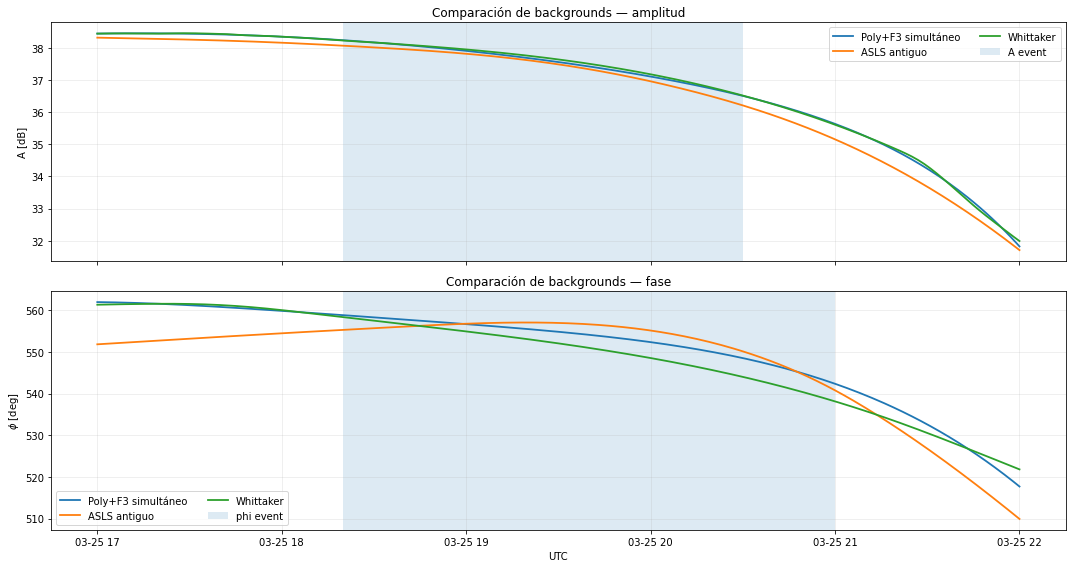

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

#axes[0].plot(df_common.index, df_common["A_ref"], lw=1.2, label="A real ref.")
axes[0].plot(df_common.index, df_common["A_bg_polyF3"], lw=1.8, label="Poly+F3 simultáneo")
axes[0].plot(df_common.index, df_common["A_bg_ASLS"], lw=1.8, label="ASLS antiguo")
axes[0].plot(df_common.index, df_common["A_bg_Whittaker"], lw=1.8, label="Whittaker")
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
axes[0].set_ylabel("A [dB]")
axes[0].set_title("Comparación de backgrounds — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=2)

#axes[1].plot(df_common.index, df_common["phi_ref"], lw=1.2, label=r"$\phi$ real ref.")
axes[1].plot(df_common.index, df_common["phi_bg_polyF3"], lw=1.8, label="Poly+F3 simultáneo")
axes[1].plot(df_common.index, df_common["phi_bg_ASLS"], lw=1.8, label="ASLS antiguo")
axes[1].plot(df_common.index, df_common["phi_bg_Whittaker"], lw=1.8, label="Whittaker")
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
axes[1].set_ylabel(r"$\phi$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Comparación de backgrounds — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=2)

plt.tight_layout()
plt.savefig(
    OUTDIR / "backgrounds_polyF3_ASLS_Whittaker.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

Archivos usados:
  Poly+F3 simultáneo:
    outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/h5/simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5
  Polinómico antiguo:
    real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5
  Polinómico ventanas quietas:
    outputs_window_start_degree_sensitivity_NAA_PLO_20080325/h5/selected_window_degree_sensitivity_NAA_V_20080325_Awin16_22_degA7_PHIwin16_22_degPhi6.h5
  ASLS:
    datos_asls_full-v3.h5
  Whittaker:
    real_whittaker_selected_background_16_22_for_inversion.h5

Rangos originales:
  Poly+F3:      2008-03-25 16:00:00+00:00 -> 2008-03-25 22:00:00+00:00  N=361
  OldPoly:      2008-03-25 16:00:00+00:00 -> 2008-03-25 22:00:00+00:00  N=361
  QuietPoly:    2008-03-25 16:00:00+00:00 -> 2008-03-25 22:00:00+00:00  N=361
  ASLS 1min:    2008-03-25 17:00:00+00:00 -> 2008-03-25 22:59:00+00:00  N=360
  Whittaker:    2008-03-25 16:00:00+00:00 -> 2008-03-25 22:00:00+00:00  N=361

Rango común usado:
  2008-03-

,channel,comparison,region,N,mean,median,std,rmse,max_abs
0,A,OldPoly - PolyF3,common_all,301,-0.000608,-0.000599,0.002975,0.003036,0.017746
1,A,OldPoly - PolyF3,event,131,-0.002346,-0.002612,0.001644,0.002864,0.004421
2,phi,OldPoly - PolyF3,common_all,301,0.000616,0.000454,0.002261,0.002343,0.008482
3,phi,OldPoly - PolyF3,event,161,0.001938,0.002265,0.001176,0.002267,0.003344
4,A,QuietPoly - PolyF3,common_all,301,-0.037263,-0.010933,0.047219,0.060151,0.122559
5,A,QuietPoly - PolyF3,event,131,-0.084981,-0.091208,0.030959,0.090444,0.122559
6,phi,QuietPoly - PolyF3,common_all,301,0.452861,0.296011,1.251006,1.330451,4.508860
7,phi,QuietPoly - PolyF3,event,161,1.043838,1.222369,0.892199,1.373177,2.052140
8,A,ASLS - PolyF3,common_all,301,-0.237616,-0.182310,0.154345,0.283344,0.567981
9,A,ASLS - PolyF3,event,131,-0.132678,-0.118234,0.059264,0.145313,0.296388



Perturbaciones calculadas como datos de referencia - background:


/tmp/ipykernel_54060/2596800509.py:547: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.abs(y[mask]), t_hours))
/tmp/ipykernel_54060/2596800509.py:559: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y[mask], t_hours))


,channel,method,N_event,peak_abs_event,peak_signed_event,area_abs_event,area_signed_event
0,A,PolyF3,131,3.862602,3.862602,2.297365,2.287791
1,A,OldPoly,131,3.865828,3.865828,2.302222,2.292921
2,A,QuietPoly,131,3.948680,3.948680,2.473171,2.472850
3,A,ASLS,131,3.958807,3.958807,2.573580,2.573580
4,A,Whittaker,131,3.824279,3.824279,2.220805,2.184921
5,phi,PolyF3,161,91.410080,91.410080,89.028818,88.524645
6,phi,OldPoly,161,91.409296,91.409296,89.023682,88.519463
7,phi,QuietPoly,161,90.170190,90.170190,86.590778,85.714698
8,phi,ASLS,161,91.400377,91.400377,86.482098,86.482098
9,phi,Whittaker,161,93.130878,93.130878,96.466174,96.402226


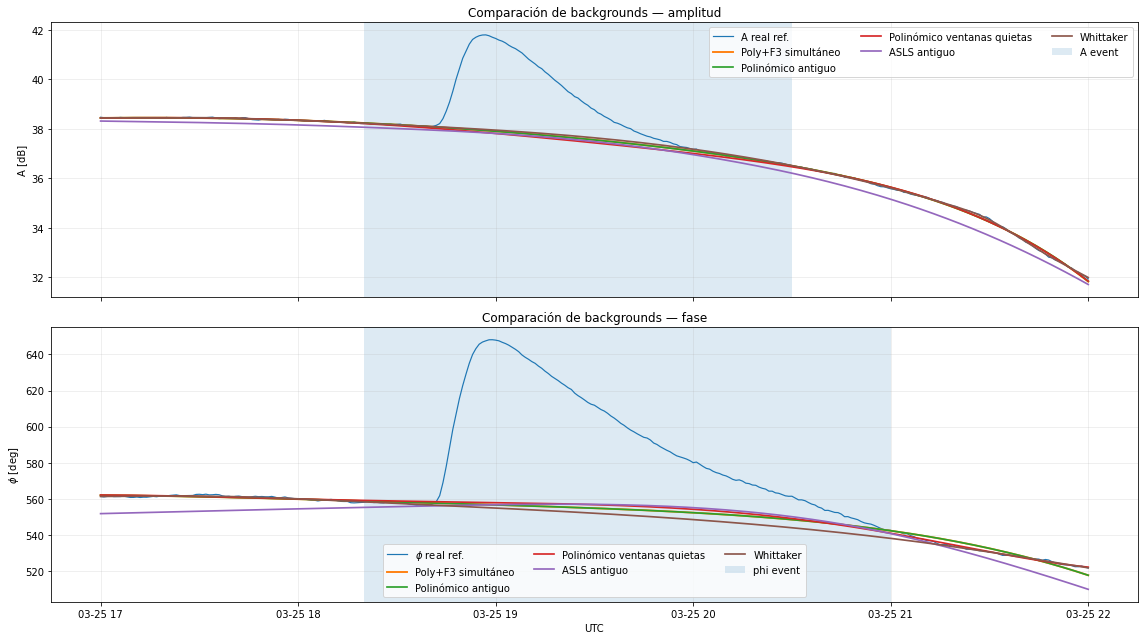

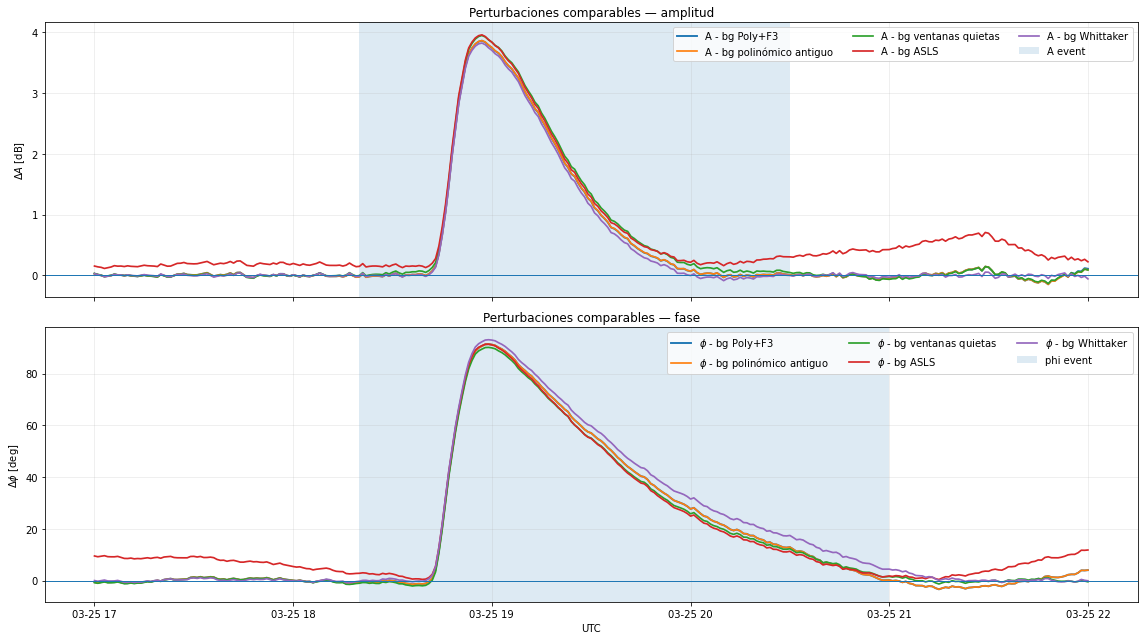

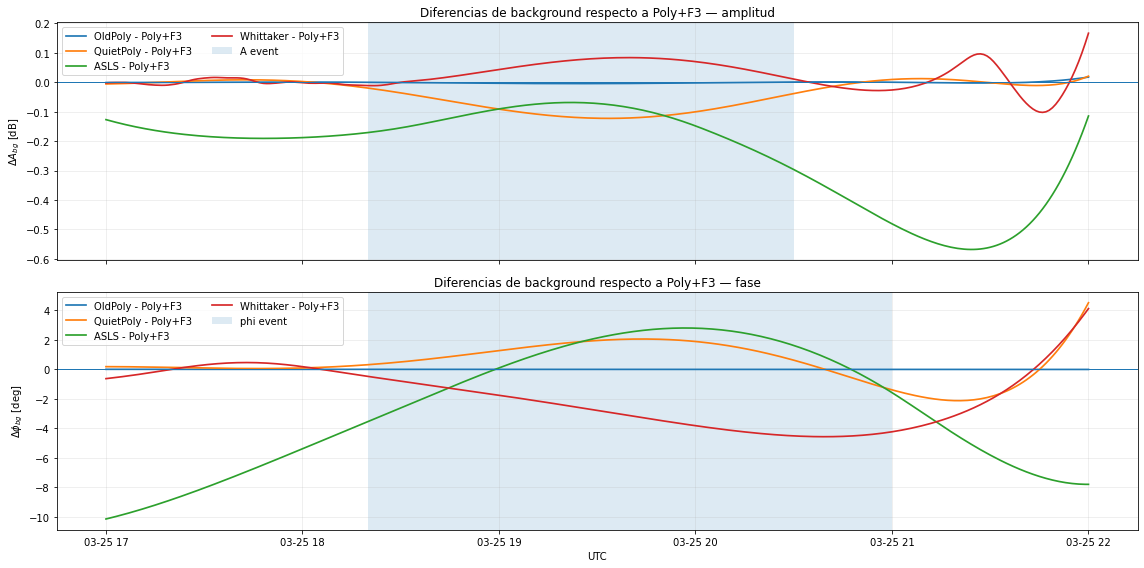


Archivos guardados en:
  /home/jp/basefolder_JP/outputs_compare_all_backgrounds_polyF3_oldpoly_quiet_ASLS_Whittaker

Figuras:
  backgrounds_all_methods.png
  perturbations_all_methods.png
  background_differences_all_methods_minus_polyF3.png

Tablas:
  background_difference_all_methods_vs_polyF3_summary.csv
  perturbation_metrics_all_methods_summary.csv
  timeseries_all_background_methods_common_interval.csv


In [14]:
# ============================================================
# Comparación ampliada de backgrounds:
#
#   1) Poly+F3 simultáneo seleccionado:
#        window = 16:00–22:00
#        degA   = 7
#        degPhi = 4
#
#   2) Background polinómico antiguo correcto:
#        real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5
#        o
#        new_real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5
#
#   3) Background nuevo con ventanas quietas:
#        selected_window_degree_sensitivity_NAA_V_20080325_Awin16_22_degA7_PHIwin16_22_degPhi6.h5
#
#   4) ASLS antiguo:
#        datos_asls_full-v3.h5
#
#   5) Whittaker:
#        real_whittaker_selected_background_16_22_for_inversion.h5
#
# La comparación usa una misma serie de referencia: A_real y phi_real
# del Poly+F3 simultáneo seleccionado.
# ============================================================

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1) Archivos
# ============================================================

POLYF3_CANDIDATES = [
    Path(
        "outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/"
        "h5/simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5"
    ),
    Path(
        "outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325_extracted/"
        "outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/"
        "h5/simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5"
    ),
    Path(
        "/mnt/data/outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325_extracted/"
        "outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/"
        "h5/simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5"
    ),
]

OLD_POLY_CANDIDATES = [
    Path("real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5"),
    Path("new_real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5"),
    Path("/mnt/data/real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5"),
    Path("/mnt/data/new_real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5"),
]

QUIET_POLY_CANDIDATES = [
    Path(
        "outputs_window_start_degree_sensitivity_NAA_PLO_20080325/"
        "h5/selected_window_degree_sensitivity_NAA_V_20080325_Awin16_22_degA7_PHIwin16_22_degPhi6.h5"
    ),
    Path(
        "win_deg/outputs_window_start_degree_sensitivity_NAA_PLO_20080325/"
        "h5/selected_window_degree_sensitivity_NAA_V_20080325_Awin16_22_degA7_PHIwin16_22_degPhi6.h5"
    ),
    Path(
        "/mnt/data/win_deg/outputs_window_start_degree_sensitivity_NAA_PLO_20080325/"
        "h5/selected_window_degree_sensitivity_NAA_V_20080325_Awin16_22_degA7_PHIwin16_22_degPhi6.h5"
    ),
]

ASLS_CANDIDATES = [
    Path("datos_asls_full-v3.h5"),
    Path("/mnt/data/datos_asls_full-v3.h5"),
]

WHITTAKER_CANDIDATES = [
    Path("real_whittaker_selected_background_16_22_for_inversion.h5"),
    Path("/mnt/data/real_whittaker_selected_background_16_22_for_inversion.h5"),
]

OUTDIR = Path("outputs_compare_all_backgrounds_polyF3_oldpoly_quiet_ASLS_Whittaker")
OUTDIR.mkdir(parents=True, exist_ok=True)


def find_file(candidates, recursive_names=()):
    for p in candidates:
        if p.exists():
            return p

    for name in recursive_names:
        hits = sorted(Path(".").rglob(name))
        hits = [h for h in hits if h.is_file()]
        if len(hits) > 0:
            return hits[0]

        hits = sorted(Path("/mnt/data").rglob(name))
        hits = [h for h in hits if h.is_file()]
        if len(hits) > 0:
            return hits[0]

    return None


POLYF3_H5 = find_file(
    POLYF3_CANDIDATES,
    recursive_names=[
        "simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5",
    ],
)

OLD_POLY_H5 = find_file(
    OLD_POLY_CANDIDATES,
    recursive_names=[
        "real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5",
        "new_real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5",
    ],
)

QUIET_POLY_H5 = find_file(
    QUIET_POLY_CANDIDATES,
    recursive_names=[
        "selected_window_degree_sensitivity_NAA_V_20080325_Awin16_22_degA7_PHIwin16_22_degPhi6.h5",
    ],
)

ASLS_H5 = find_file(
    ASLS_CANDIDATES,
    recursive_names=[
        "datos_asls_full-v3.h5",
    ],
)

WHITTAKER_H5 = find_file(
    WHITTAKER_CANDIDATES,
    recursive_names=[
        "real_whittaker_selected_background_16_22_for_inversion.h5",
    ],
)

required_files = {
    "Poly+F3 simultáneo": POLYF3_H5,
    "Polinómico antiguo": OLD_POLY_H5,
    "Polinómico ventanas quietas": QUIET_POLY_H5,
    "ASLS": ASLS_H5,
    "Whittaker": WHITTAKER_H5,
}

missing = [name for name, path in required_files.items() if path is None]

if missing:
    raise FileNotFoundError(
        "No encontré estos archivos requeridos:\n"
        + "\n".join(f"  - {m}" for m in missing)
    )

print("Archivos usados:")
for name, path in required_files.items():
    print(f"  {name}:")
    print(f"    {path}")

# ============================================================
# 2) Utilidades de lectura robusta
# ============================================================

def decode_strings(arr):
    arr = np.asarray(arr)
    out = []

    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))

    return np.array(out, dtype=object)


def to_datetime_robust(raw):
    arr = np.asarray(raw)

    if np.issubdtype(arr.dtype, np.number):
        vals = arr.astype(float)
        med = np.nanmedian(vals)

        if med > 1e14:
            return pd.to_datetime(vals, unit="us", utc=True)
        elif med > 1e11:
            return pd.to_datetime(vals, unit="ms", utc=True)
        else:
            return pd.to_datetime(vals, unit="s", utc=True)

    vals = decode_strings(arr)

    numeric_vals = pd.to_numeric(pd.Series(vals), errors="coerce")
    frac_numeric = numeric_vals.notna().mean()

    if frac_numeric > 0.95:
        x = numeric_vals.to_numpy(dtype=float)
        med = np.nanmedian(x)

        if med > 1e14:
            return pd.to_datetime(x, unit="us", utc=True)
        elif med > 1e11:
            return pd.to_datetime(x, unit="ms", utc=True)
        else:
            return pd.to_datetime(x, unit="s", utc=True)

    return pd.to_datetime(vals, utc=True)


def read_dataset_first(h5, names, required=True):
    for name in names:
        if name in h5:
            return h5[name][()]

    all_names = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            all_names.append(name)

    h5.visititems(visitor)

    for candidate in names:
        for name in all_names:
            if name == candidate or name.endswith("/" + candidate):
                return h5[name][()]

    if required:
        raise KeyError(
            "No encontré ninguno de estos datasets:\n"
            f"  {names}\n"
            "Datasets disponibles:\n"
            + "\n".join([f"  {k}" for k in all_names])
        )

    return None


def read_time_index(h5):
    raw = read_dataset_first(
        h5,
        [
            "timestamps_iso",
            "timestamps",
            "timestamps_unix",
            "time_unix",
            "unix_timestamps",
            "time_utc",
        ],
        required=True,
    )

    return pd.DatetimeIndex(to_datetime_robust(raw), name="time_utc")


# ============================================================
# 3) Lectores de HDF5
# ============================================================

def load_generic_background_h5(path, label):
    """
    Lee HDF5 con datasets tipo:
      A_real, phi_real, A_background, phi_background
    aceptando variantes:
      A_background_model, phi_background_model, etc.
    """

    with h5py.File(path, "r") as h5:
        t = read_time_index(h5)

        A_real = read_dataset_first(
            h5,
            ["A_real", "A_data", "amp_real", "amplitude_real"],
            required=True,
        )

        phi_real = read_dataset_first(
            h5,
            ["phi_real", "phi_data", "phase_real"],
            required=True,
        )

        A_bg = read_dataset_first(
            h5,
            [
                "A_background",
                "A_background_model",
                "A_bg",
                "baseline_amp",
                "baseline_asls_amp",
            ],
            required=True,
        )

        phi_bg = read_dataset_first(
            h5,
            [
                "phi_background",
                "phi_background_model",
                "phi_bg",
                "baseline_phi",
                "baseline_asls_phi",
            ],
            required=True,
        )

        A_f3 = read_dataset_first(
            h5,
            [
                "A_perturbation_F3",
                "A_F3",
                "A_perturbation_model",
                "A_perturbation",
            ],
            required=False,
        )

        phi_f3 = read_dataset_first(
            h5,
            [
                "phi_perturbation_F3",
                "phi_F3",
                "phi_perturbation_model",
                "phi_perturbation",
            ],
            required=False,
        )

    n = len(t)

    def checked(arr, name):
        arr = np.asarray(arr)
        if len(arr) != n:
            raise ValueError(
                f"Longitud inconsistente en {path.name}: {name} tiene {len(arr)}, timestamps tiene {n}."
            )
        return arr.astype(float)

    df = pd.DataFrame(
        {
            f"A_real_{label}": checked(A_real, "A_real"),
            f"phi_real_{label}": checked(phi_real, "phi_real"),
            f"A_bg_{label}": checked(A_bg, "A_background"),
            f"phi_bg_{label}": checked(phi_bg, "phi_background"),
        },
        index=t,
    )

    df[f"A_pert_{label}_from_bg"] = df[f"A_real_{label}"] - df[f"A_bg_{label}"]
    df[f"phi_pert_{label}_from_bg"] = df[f"phi_real_{label}"] - df[f"phi_bg_{label}"]

    if A_f3 is not None and len(A_f3) == n:
        df[f"A_F3_{label}"] = np.asarray(A_f3, dtype=float)

    if phi_f3 is not None and len(phi_f3) == n:
        df[f"phi_F3_{label}"] = np.asarray(phi_f3, dtype=float)

    return df[~df.index.duplicated(keep="first")].sort_index()


def load_asls(path):
    with h5py.File(path, "r") as h5:
        t = pd.DatetimeIndex(
            pd.to_datetime(h5["time_unix"][()], unit="s", utc=True),
            name="time_utc",
        )

        A_bg = np.asarray(h5["baseline_asls_amp"][()], dtype=float)
        phi_bg = np.asarray(h5["baseline_asls_phi"][()], dtype=float)

        A_pert = np.asarray(h5["detrended_asls_amp"][()], dtype=float)
        phi_pert = np.asarray(h5["detrended_asls_phi"][()], dtype=float)

        A_real = A_bg + A_pert
        phi_real = phi_bg + phi_pert

    df = pd.DataFrame(
        {
            "A_real_ASLS_native": A_real,
            "phi_real_ASLS_native": phi_real,
            "A_bg_ASLS": A_bg,
            "phi_bg_ASLS": phi_bg,
            "A_pert_ASLS_native": A_pert,
            "phi_pert_ASLS_native": phi_pert,
        },
        index=t,
    )

    df = df[~df.index.duplicated(keep="first")].sort_index()

    # ASLS suele venir a 1 s; para comparación con los otros HDF5,
    # se remuestrea a 1 min con mediana.
    df_1min = df.resample("1min").median(numeric_only=True)

    return df_1min


df_polyF3 = load_generic_background_h5(POLYF3_H5, "PolyF3")
df_oldpoly = load_generic_background_h5(OLD_POLY_H5, "OldPoly")
df_quiet = load_generic_background_h5(QUIET_POLY_H5, "QuietPoly")
df_asls = load_asls(ASLS_H5)
df_whit = load_generic_background_h5(WHITTAKER_H5, "Whittaker")

# ============================================================
# 4) Unión temporal y referencia común
# ============================================================

df = (
    df_polyF3
    .join(df_oldpoly, how="outer")
    .join(df_quiet, how="outer")
    .join(df_asls, how="outer")
    .join(df_whit, how="outer")
)

df = df.sort_index()

# Referencia común: datos del Poly+F3 simultáneo seleccionado.
df["A_ref"] = df["A_real_PolyF3"]
df["phi_ref"] = df["phi_real_PolyF3"]

# Perturbaciones comparables = datos de referencia - background.
method_bg_cols = {
    "PolyF3": ("A_bg_PolyF3", "phi_bg_PolyF3"),
    "OldPoly": ("A_bg_OldPoly", "phi_bg_OldPoly"),
    "QuietPoly": ("A_bg_QuietPoly", "phi_bg_QuietPoly"),
    "ASLS": ("A_bg_ASLS", "phi_bg_ASLS"),
    "Whittaker": ("A_bg_Whittaker", "phi_bg_Whittaker"),
}

for method, (A_bg_col, phi_bg_col) in method_bg_cols.items():
    df[f"A_pert_{method}"] = df["A_ref"] - df[A_bg_col]
    df[f"phi_pert_{method}"] = df["phi_ref"] - df[phi_bg_col]

required_common = [
    "A_ref",
    "phi_ref",
    "A_bg_PolyF3",
    "phi_bg_PolyF3",
    "A_bg_OldPoly",
    "phi_bg_OldPoly",
    "A_bg_QuietPoly",
    "phi_bg_QuietPoly",
    "A_bg_ASLS",
    "phi_bg_ASLS",
    "A_bg_Whittaker",
    "phi_bg_Whittaker",
]

df_common = df.dropna(subset=required_common).copy()

if len(df_common) == 0:
    raise ValueError(
        "No hay timestamps comunes entre todos los métodos. "
        "Revisa rangos temporales y resolución."
    )

print("\nRangos originales:")
print(f"  Poly+F3:      {df_polyF3.index.min()} -> {df_polyF3.index.max()}  N={len(df_polyF3)}")
print(f"  OldPoly:      {df_oldpoly.index.min()} -> {df_oldpoly.index.max()}  N={len(df_oldpoly)}")
print(f"  QuietPoly:    {df_quiet.index.min()} -> {df_quiet.index.max()}  N={len(df_quiet)}")
print(f"  ASLS 1min:    {df_asls.index.min()} -> {df_asls.index.max()}  N={len(df_asls)}")
print(f"  Whittaker:    {df_whit.index.min()} -> {df_whit.index.max()}  N={len(df_whit)}")

print("\nRango común usado:")
print(f"  {df_common.index.min()} -> {df_common.index.max()}  N={len(df_common)}")

# Máscaras diagnósticas.
A_EVENT_START = pd.Timestamp("2008-03-25 18:20:00", tz="UTC")
A_EVENT_END   = pd.Timestamp("2008-03-25 20:30:00", tz="UTC")

PHI_EVENT_START = pd.Timestamp("2008-03-25 18:20:00", tz="UTC")
PHI_EVENT_END   = pd.Timestamp("2008-03-25 21:00:00", tz="UTC")

A_event_mask = np.asarray(
    (df_common.index >= A_EVENT_START) & (df_common.index <= A_EVENT_END),
    dtype=bool,
)

phi_event_mask = np.asarray(
    (df_common.index >= PHI_EVENT_START) & (df_common.index <= PHI_EVENT_END),
    dtype=bool,
)

# ============================================================
# 5) Métricas
# ============================================================

def summarize_diff(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return {
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "rmse": np.nan,
            "max_abs": np.nan,
        }

    return {
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "std": float(np.std(x)),
        "rmse": float(np.sqrt(np.mean(x**2))),
        "max_abs": float(np.max(np.abs(x))),
    }


def peak_abs(series, mask):
    x = np.asarray(series[mask], dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan

    return float(np.max(np.abs(x)))


def signed_peak(series, mask):
    x = np.asarray(series[mask], dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan

    i = int(np.argmax(np.abs(x)))
    return float(x[i])


def area_abs(index, series, mask):
    idx = pd.DatetimeIndex(index)
    y = np.asarray(series, dtype=float)
    mask = np.asarray(mask, dtype=bool) & np.isfinite(y)

    if np.sum(mask) < 2:
        return np.nan

    t_hours = (idx[mask] - idx[mask][0]).total_seconds().to_numpy() / 3600.0
    return float(np.trapz(np.abs(y[mask]), t_hours))


def area_signed(index, series, mask):
    idx = pd.DatetimeIndex(index)
    y = np.asarray(series, dtype=float)
    mask = np.asarray(mask, dtype=bool) & np.isfinite(y)

    if np.sum(mask) < 2:
        return np.nan

    t_hours = (idx[mask] - idx[mask][0]).total_seconds().to_numpy() / 3600.0
    return float(np.trapz(y[mask], t_hours))


# Diferencias de backgrounds respecto a Poly+F3.
diff_rows = []

for method in ["OldPoly", "QuietPoly", "ASLS", "Whittaker"]:
    for channel, bg_ref, bg_other, mask_event in [
        ("A", "A_bg_PolyF3", f"A_bg_{method}", A_event_mask),
        ("phi", "phi_bg_PolyF3", f"phi_bg_{method}", phi_event_mask),
    ]:
        diff_all = df_common[bg_other] - df_common[bg_ref]
        diff_event = diff_all[mask_event]

        s_all = summarize_diff(diff_all)
        s_event = summarize_diff(diff_event)

        s_all.update({
            "channel": channel,
            "comparison": f"{method} - PolyF3",
            "region": "common_all",
            "N": len(diff_all),
        })

        s_event.update({
            "channel": channel,
            "comparison": f"{method} - PolyF3",
            "region": "event",
            "N": int(np.sum(mask_event)),
        })

        diff_rows.append(s_all)
        diff_rows.append(s_event)

diff_summary = pd.DataFrame(diff_rows)[
    ["channel", "comparison", "region", "N", "mean", "median", "std", "rmse", "max_abs"]
]

print("\nDiferencias de background respecto a Poly+F3:")
display(diff_summary.round(6))

# Picos y áreas de perturbación.
pert_rows = []

for channel, mask_event, methods in [
    (
        "A",
        A_event_mask,
        {
            "PolyF3": "A_pert_PolyF3",
            "OldPoly": "A_pert_OldPoly",
            "QuietPoly": "A_pert_QuietPoly",
            "ASLS": "A_pert_ASLS",
            "Whittaker": "A_pert_Whittaker",
        },
    ),
    (
        "phi",
        phi_event_mask,
        {
            "PolyF3": "phi_pert_PolyF3",
            "OldPoly": "phi_pert_OldPoly",
            "QuietPoly": "phi_pert_QuietPoly",
            "ASLS": "phi_pert_ASLS",
            "Whittaker": "phi_pert_Whittaker",
        },
    ),
]:
    for method, col in methods.items():
        pert_rows.append({
            "channel": channel,
            "method": method,
            "N_event": int(np.sum(mask_event)),
            "peak_abs_event": peak_abs(df_common[col], mask_event),
            "peak_signed_event": signed_peak(df_common[col], mask_event),
            "area_abs_event": area_abs(df_common.index, df_common[col], mask_event),
            "area_signed_event": area_signed(df_common.index, df_common[col], mask_event),
        })

pert_summary = pd.DataFrame(pert_rows)

print("\nPerturbaciones calculadas como datos de referencia - background:")
display(pert_summary.round(6))

diff_summary.to_csv(
    OUTDIR / "background_difference_all_methods_vs_polyF3_summary.csv",
    index=False,
)

pert_summary.to_csv(
    OUTDIR / "perturbation_metrics_all_methods_summary.csv",
    index=False,
)

# ============================================================
# 6) Figuras
# ============================================================

def shade_interval(ax, start, end, label=None, alpha=0.15):
    ax.axvspan(start, end, alpha=alpha, label=label)


# ------------------------------------------------------------
# Figura 1: backgrounds
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

axes[0].plot(df_common.index, df_common["A_ref"], lw=1.2, label="A real ref.")
axes[0].plot(df_common.index, df_common["A_bg_PolyF3"], lw=1.9, label="Poly+F3 simultáneo")
axes[0].plot(df_common.index, df_common["A_bg_OldPoly"], lw=1.7, label="Polinómico antiguo")
axes[0].plot(df_common.index, df_common["A_bg_QuietPoly"], lw=1.7, label="Polinómico ventanas quietas")
axes[0].plot(df_common.index, df_common["A_bg_ASLS"], lw=1.7, label="ASLS antiguo")
axes[0].plot(df_common.index, df_common["A_bg_Whittaker"], lw=1.7, label="Whittaker")
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
axes[0].set_ylabel("A [dB]")
axes[0].set_title("Comparación de backgrounds — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=3)

axes[1].plot(df_common.index, df_common["phi_ref"], lw=1.2, label=r"$\phi$ real ref.")
axes[1].plot(df_common.index, df_common["phi_bg_PolyF3"], lw=1.9, label="Poly+F3 simultáneo")
axes[1].plot(df_common.index, df_common["phi_bg_OldPoly"], lw=1.7, label="Polinómico antiguo")
axes[1].plot(df_common.index, df_common["phi_bg_QuietPoly"], lw=1.7, label="Polinómico ventanas quietas")
axes[1].plot(df_common.index, df_common["phi_bg_ASLS"], lw=1.7, label="ASLS antiguo")
axes[1].plot(df_common.index, df_common["phi_bg_Whittaker"], lw=1.7, label="Whittaker")
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
axes[1].set_ylabel(r"$\phi$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Comparación de backgrounds — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=3)

plt.tight_layout()
plt.savefig(
    OUTDIR / "backgrounds_all_methods.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ------------------------------------------------------------
# Figura 2: perturbaciones
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

axes[0].plot(df_common.index, df_common["A_pert_PolyF3"], lw=1.9, label="A - bg Poly+F3")
axes[0].plot(df_common.index, df_common["A_pert_OldPoly"], lw=1.7, label="A - bg polinómico antiguo")
axes[0].plot(df_common.index, df_common["A_pert_QuietPoly"], lw=1.7, label="A - bg ventanas quietas")
axes[0].plot(df_common.index, df_common["A_pert_ASLS"], lw=1.7, label="A - bg ASLS")
axes[0].plot(df_common.index, df_common["A_pert_Whittaker"], lw=1.7, label="A - bg Whittaker")
axes[0].axhline(0, lw=1)
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
axes[0].set_ylabel(r"$\Delta A$ [dB]")
axes[0].set_title("Perturbaciones comparables — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=3)

axes[1].plot(df_common.index, df_common["phi_pert_PolyF3"], lw=1.9, label=r"$\phi$ - bg Poly+F3")
axes[1].plot(df_common.index, df_common["phi_pert_OldPoly"], lw=1.7, label=r"$\phi$ - bg polinómico antiguo")
axes[1].plot(df_common.index, df_common["phi_pert_QuietPoly"], lw=1.7, label=r"$\phi$ - bg ventanas quietas")
axes[1].plot(df_common.index, df_common["phi_pert_ASLS"], lw=1.7, label=r"$\phi$ - bg ASLS")
axes[1].plot(df_common.index, df_common["phi_pert_Whittaker"], lw=1.7, label=r"$\phi$ - bg Whittaker")
axes[1].axhline(0, lw=1)
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
axes[1].set_ylabel(r"$\Delta\phi$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Perturbaciones comparables — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=3)

plt.tight_layout()
plt.savefig(
    OUTDIR / "perturbations_all_methods.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ------------------------------------------------------------
# Figura 3: diferencias directas respecto a Poly+F3
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for method in ["OldPoly", "QuietPoly", "ASLS", "Whittaker"]:
    axes[0].plot(
        df_common.index,
        df_common[f"A_bg_{method}"] - df_common["A_bg_PolyF3"],
        lw=1.7,
        label=f"{method} - Poly+F3",
    )

axes[0].axhline(0, lw=1)
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
axes[0].set_ylabel(r"$\Delta A_{bg}$ [dB]")
axes[0].set_title("Diferencias de background respecto a Poly+F3 — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=2)

for method in ["OldPoly", "QuietPoly", "ASLS", "Whittaker"]:
    axes[1].plot(
        df_common.index,
        df_common[f"phi_bg_{method}"] - df_common["phi_bg_PolyF3"],
        lw=1.7,
        label=f"{method} - Poly+F3",
    )

axes[1].axhline(0, lw=1)
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
axes[1].set_ylabel(r"$\Delta\phi_{bg}$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Diferencias de background respecto a Poly+F3 — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=2)

plt.tight_layout()
plt.savefig(
    OUTDIR / "background_differences_all_methods_minus_polyF3.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ============================================================
# 7) Guardar serie comparativa
# ============================================================

df_out = df_common.copy()
df_out.index = df_out.index.strftime("%Y-%m-%dT%H:%M:%SZ")

df_out.to_csv(
    OUTDIR / "timeseries_all_background_methods_common_interval.csv"
)

print("\nArchivos guardados en:")
print(f"  {OUTDIR.resolve()}")
print("\nFiguras:")
print("  backgrounds_all_methods.png")
print("  perturbations_all_methods.png")
print("  background_differences_all_methods_minus_polyF3.png")
print("\nTablas:")
print("  background_difference_all_methods_vs_polyF3_summary.csv")
print("  perturbation_metrics_all_methods_summary.csv")
print("  timeseries_all_background_methods_common_interval.csv")

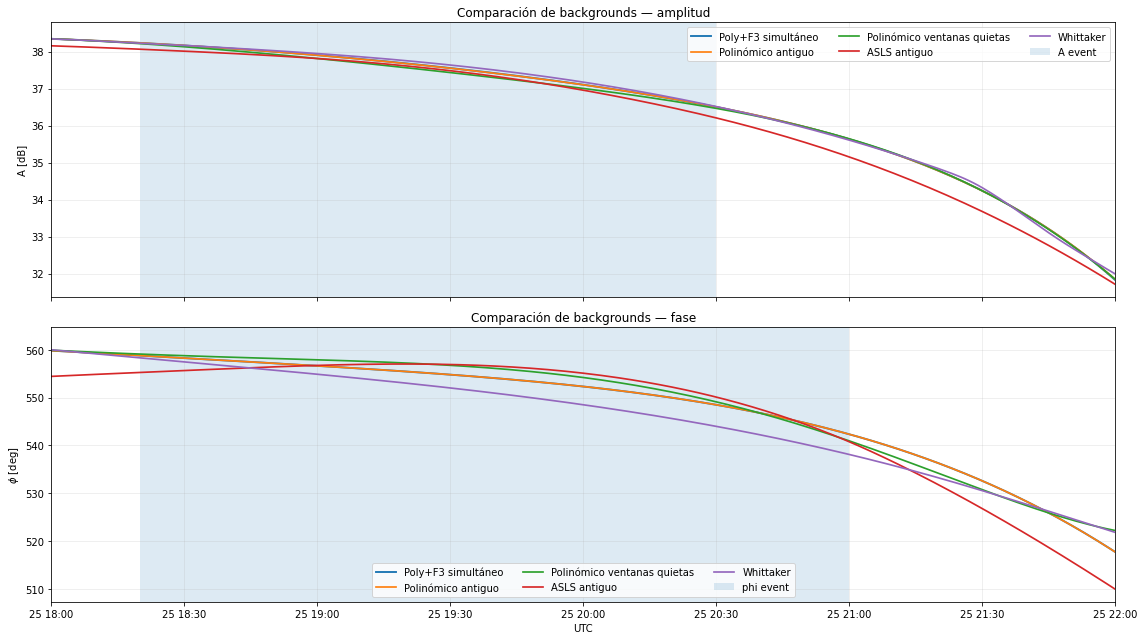

In [21]:
import datetime
dti = datetime.datetime(2008,3,25,18,0,0,0)
dtf = datetime.datetime(2008,3,25,22,0,0,0)
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

#axes[0].plot(df_common.index, df_common["A_ref"], lw=1.2, label="A real ref.")
axes[0].plot(df_common.index, df_common["A_bg_PolyF3"], lw=1.9, label="Poly+F3 simultáneo")
axes[0].plot(df_common.index, df_common["A_bg_OldPoly"], lw=1.7, label="Polinómico antiguo")
axes[0].plot(df_common.index, df_common["A_bg_QuietPoly"], lw=1.7, label="Polinómico ventanas quietas")
axes[0].plot(df_common.index, df_common["A_bg_ASLS"], lw=1.7, label="ASLS antiguo")
axes[0].plot(df_common.index, df_common["A_bg_Whittaker"], lw=1.7, label="Whittaker")
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
axes[0].set_ylabel("A [dB]")
axes[0].set_title("Comparación de backgrounds — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=3)
axes[0].set_xlim(dti,dtf)

#axes[1].plot(df_common.index, df_common["phi_ref"], lw=1.2, label=r"$\phi$ real ref.")
axes[1].plot(df_common.index, df_common["phi_bg_PolyF3"], lw=1.9, label="Poly+F3 simultáneo")
axes[1].plot(df_common.index, df_common["phi_bg_OldPoly"], lw=1.7, label="Polinómico antiguo")
axes[1].plot(df_common.index, df_common["phi_bg_QuietPoly"], lw=1.7, label="Polinómico ventanas quietas")
axes[1].plot(df_common.index, df_common["phi_bg_ASLS"], lw=1.7, label="ASLS antiguo")
axes[1].plot(df_common.index, df_common["phi_bg_Whittaker"], lw=1.7, label="Whittaker")
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
axes[1].set_ylabel(r"$\phi$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Comparación de backgrounds — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=3)
axes[1].set_xlim(dti,dtf)

plt.tight_layout()
#plt.savefig(
#    OUTDIR / "backgrounds_all_methods.png",
#    dpi=200,
#    bbox_inches="tight",
#)
#plt.show()

HDF5 usado:
  outputs_real_F3_phase_quiet_windows/real_F3_phase_quiet_windows_selected_solution.h5
CSV usado:
  outputs_real_F3_phase_quiet_windows/real_F3_phase_quiet_windows_metrics.csv

Datasets/grupos en HDF5:
  A_background
  A_perturbation
  A_real
  A_residual
  A_residual_after_background
  A_total_fit
  params_A
  params_phi
  phi_background
  phi_perturbation
  phi_quiet_mask
  phi_real
  phi_residual
  phi_residual_after_background
  phi_total_fit
  selected_metrics
  t_hours
  timestamps_iso

Rango temporal:
  2008-03-25 18:00:00+00:00 -> 2008-03-25 22:00:00+00:00
  N = 241

Atributos principales:
  AMP_OFFSET_DB: 0.0
  PHI_OFFSET_DEG: 0.0
  PHI_QUIET_WINDOWS: 2008-03-25 18:00:00 -> 2008-03-25 18:35:00; 2008-03-25 20:45:00 -> 2008-03-25 22:00:00
  RESAMPLE_AGG: median
  RESAMPLE_RULE: 1min
  T_END: 2008-03-25 22:00:00
  T_START: 2008-03-25 18:00:00
  auto_best_deg_A: 7
  auto_best_deg_phi: 4
  date: 2008-03-25
  method: Amplitude: simultaneous polynomial background + F3. Ph

,quantity,max_abs_value,signed_at_max_abs,time_at_max_abs,rmse_total_residual
0,A_perturbation,3.778345,3.778345,2008-03-25 18:56:00+00:00,0.037054
1,phi_perturbation,83.345599,83.345599,2008-03-25 18:58:00+00:00,2.141066


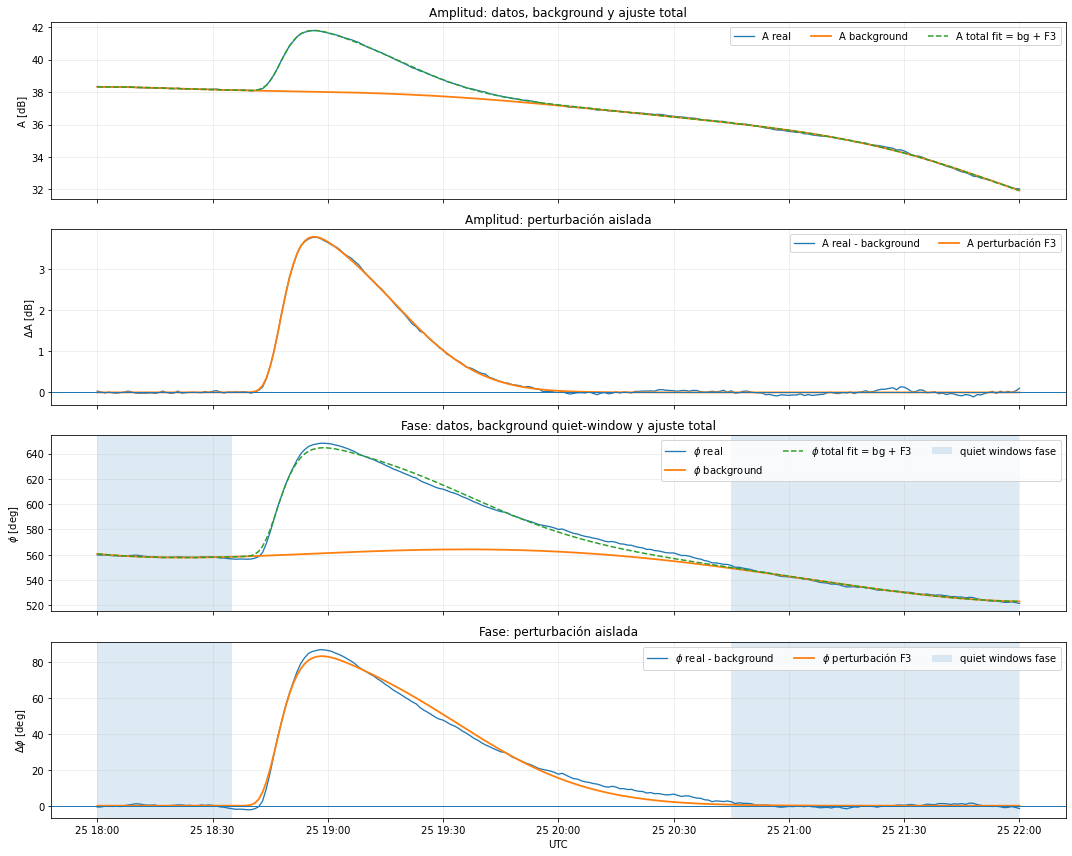

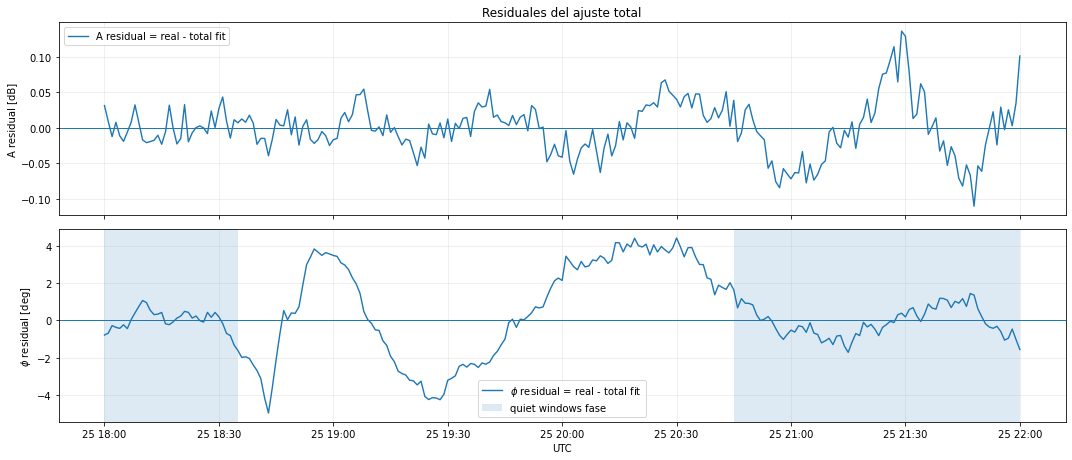

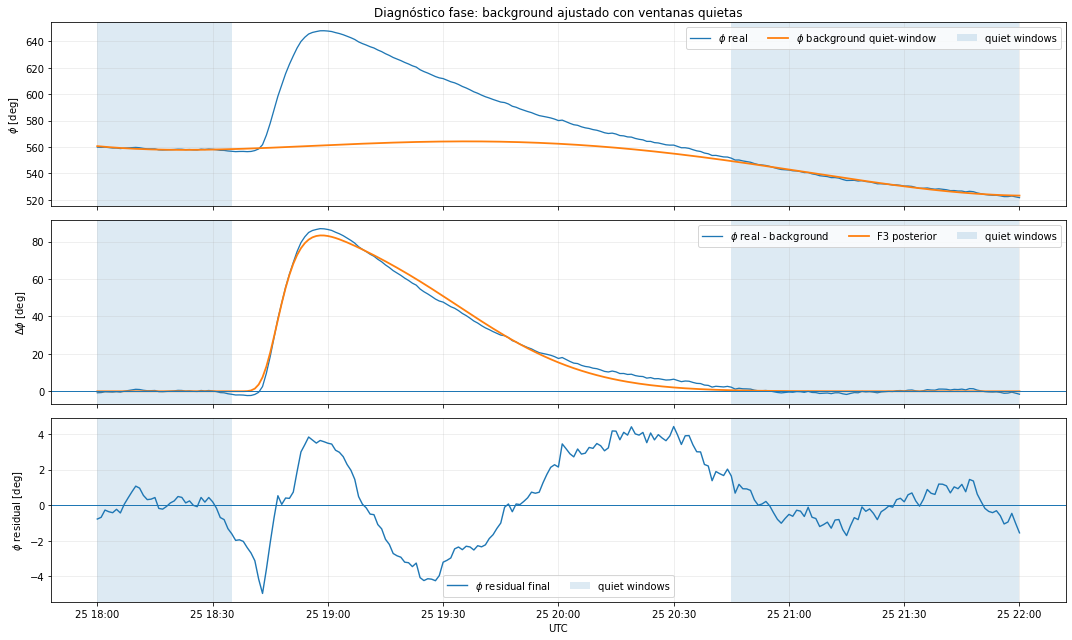


Columnas del CSV:
['deg_A', 'deg_phi', 'combo', 'chi2norm_A', 'chi2norm_phi', 'chi2norm_total', 'rmse_A', 'rmse_phi', 'mae_A', 'mae_phi', 'bias_A', 'bias_phi', 'r2_A', 'r2_phi', 'aic_A', 'aic_phi', 'bic_A', 'bic_phi', 'aic_total', 'bic_total', 'rss_total', 'n_params_total', 't_pk_A_h', 't_pk_phi_h', 'tau_u_A_h', 'tau_u_phi_h', 'tau_d_A_h', 'tau_d_phi_h', 'eps_A_h', 'eps_phi_h', 'amp_A', 'amp_phi']

Primeras filas del CSV:


,deg_A,deg_phi,combo,chi2norm_A,chi2norm_phi,chi2norm_total,rmse_A,rmse_phi,mae_A,mae_phi,...,t_pk_A_h,t_pk_phi_h,tau_u_A_h,tau_u_phi_h,tau_d_A_h,tau_d_phi_h,eps_A_h,eps_phi_h,amp_A,amp_phi
0,7,4,A7_phi4,0.000343,0.541563,0.541906,0.037098,21.641373,0.026041,14.531298,...,2.946184,2.152506,0.025791,0.233548,0.376123,2.077221,0.317146,0.034631,3.889582,33.659392
1,6,4,A6_phi4,0.000442,0.541563,0.542006,0.042124,21.641373,0.029264,14.531298,...,2.895586,2.152506,0.079735,0.233548,0.402386,2.077221,0.001865,0.034631,3.850663,33.659392
2,3,4,A3_phi4,0.003273,0.541563,0.544836,0.114565,21.641373,0.087424,14.531298,...,2.937829,2.152506,0.052130,0.233548,0.340979,2.077221,0.209630,0.034631,3.663651,33.659392
3,5,4,A5_phi4,0.050967,0.541563,0.592531,0.452095,21.641373,0.284658,14.531298,...,5.236832,2.152506,0.001689,0.233548,12.000000,2.077221,1.620665,0.034631,-6.847345,33.659392
4,4,4,A4_phi4,0.053612,0.541563,0.595175,0.463675,21.641373,0.356246,14.531298,...,2.270505,2.152506,11.999691,0.233548,0.001667,2.077221,0.290727,0.034631,-3.548355,33.659392
5,7,2,A7_phi2,0.000343,0.713057,0.713400,0.037098,24.832613,0.026041,19.252537,...,2.946184,2.199708,0.025791,1.446306,0.376123,2.981904,0.317146,0.672694,3.889582,20.705691
6,6,2,A6_phi2,0.000442,0.713057,0.713500,0.042124,24.832613,0.029264,19.252537,...,2.895586,2.199708,0.079735,1.446306,0.402386,2.981904,0.001865,0.672694,3.850663,20.705691
7,3,2,A3_phi2,0.003273,0.713057,0.716330,0.114565,24.832613,0.087424,19.252537,...,2.937829,2.199708,0.052130,1.446306,0.340979,2.981904,0.209630,0.672694,3.663651,20.705691
8,7,3,A7_phi3,0.000343,0.719026,0.719369,0.037098,24.936323,0.026041,17.733656,...,2.946184,1.977668,0.025791,1.470877,0.376123,1.966536,0.317146,0.559910,3.889582,16.938376
9,6,3,A6_phi3,0.000442,0.719026,0.719468,0.042124,24.936323,0.029264,17.733656,...,2.895586,1.977668,0.079735,1.470877,0.402386,1.966536,0.001865,0.559910,3.850663,16.938376


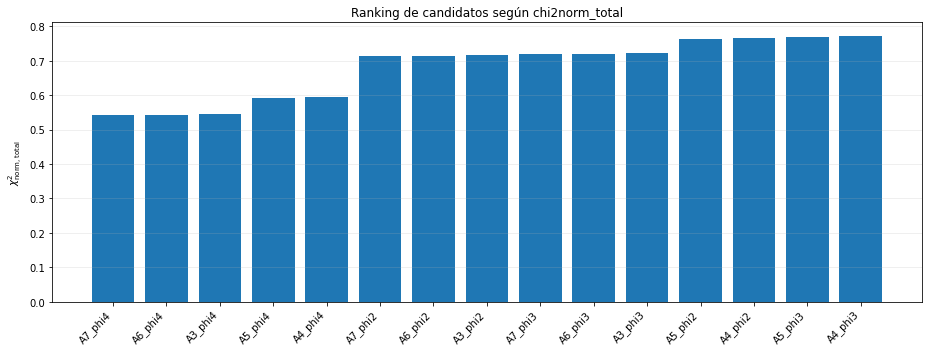

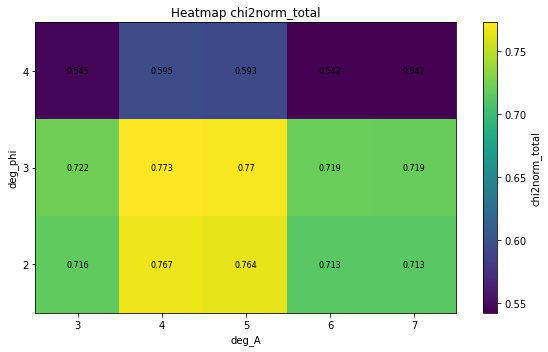

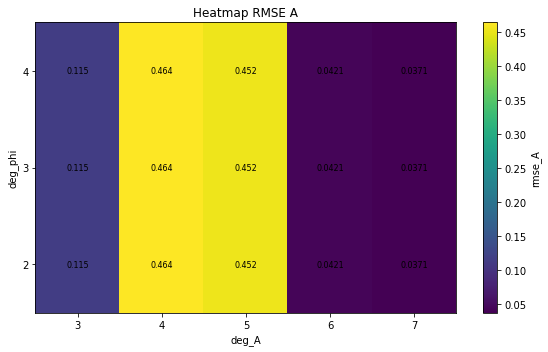

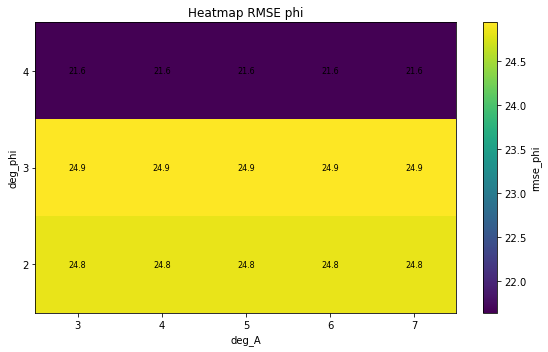

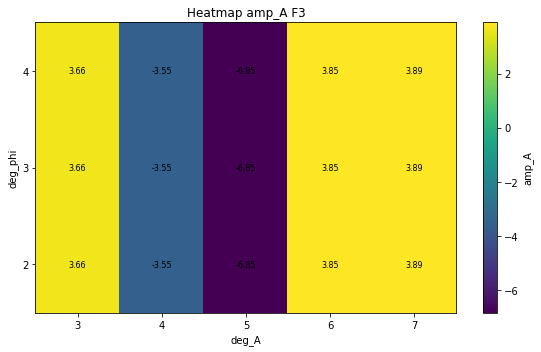

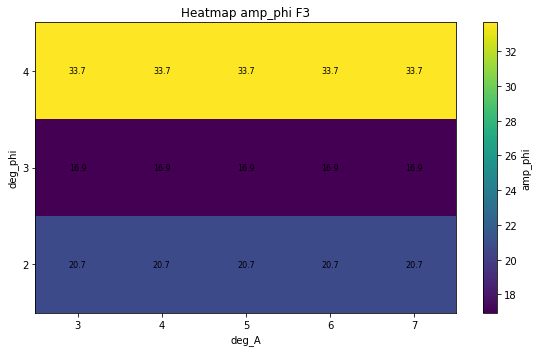


Archivos guardados en:
  /home/jp/basefolder_JP/outputs_plot_real_F3_phase_quiet_windows

Figuras principales:
  selected_solution_background_perturbation_totalfit.png
  selected_solution_residuals.png
  phase_quiet_windows_diagnostic.png
  candidate_ranking_chi2norm_total.png
  heatmap_chi2norm_total.png
  heatmap_rmse_A.png
  heatmap_rmse_phi.png
  heatmap_amp_A.png
  heatmap_amp_phi.png

Tablas:
  selected_solution_timeseries.csv
  quick_summary_from_h5.csv
  metrics_candidates_copy.csv


In [23]:
# ============================================================
# Graficar resultados de:
#   1) real_F3_phase_quiet_windows_selected_solution.h5
#   2) real_F3_phase_quiet_windows_metrics.csv
#
# Versión corregida:
#   - busca los archivos recursivamente dentro de carpetas/subcarpetas
#   - no asume que el .h5 y el .csv están en el directorio raíz
#   - genera figuras, tablas resumen y CSVs de salida
# ============================================================

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 0) Configuración corregida: búsqueda recursiva
# ============================================================

H5_NAME = "real_F3_phase_quiet_windows_selected_solution.h5"
CSV_NAME = "real_F3_phase_quiet_windows_metrics.csv"

# Si quieres forzar una carpeta específica, cambia esta línea.
# Por ejemplo:
# ANALYSIS_ROOT = Path("outputs_real_F3_phase_quiet_windows")
ANALYSIS_ROOT = Path(".")

SEARCH_DIRS = [
    ANALYSIS_ROOT,
    Path("/mnt/data"),
]

OUTDIR = Path("outputs_plot_real_F3_phase_quiet_windows")
OUTDIR.mkdir(parents=True, exist_ok=True)


def find_file_recursive(filename, search_dirs):
    """
    Busca filename dentro de search_dirs y subcarpetas.
    Si hay varios resultados, usa el más recientemente modificado.
    """
    hits = []

    for base in search_dirs:
        base = Path(base)

        if not base.exists():
            continue

        direct = base / filename
        if direct.exists() and direct.is_file():
            hits.append(direct)

        hits.extend([p for p in base.rglob(filename) if p.is_file()])

    unique_hits = []
    seen = set()

    for p in hits:
        rp = p.resolve()
        if rp not in seen:
            unique_hits.append(p)
            seen.add(rp)

    if len(unique_hits) == 0:
        return None

    unique_hits = sorted(unique_hits, key=lambda p: p.stat().st_mtime, reverse=True)
    return unique_hits[0]


H5_PATH = find_file_recursive(H5_NAME, SEARCH_DIRS)
CSV_PATH = find_file_recursive(CSV_NAME, SEARCH_DIRS)

if H5_PATH is None:
    raise FileNotFoundError(
        f"No encontré {H5_NAME} dentro de:\n"
        + "\n".join(f"  {p.resolve()}" for p in SEARCH_DIRS if p.exists())
    )

if CSV_PATH is None:
    raise FileNotFoundError(
        f"No encontré {CSV_NAME} dentro de:\n"
        + "\n".join(f"  {p.resolve()}" for p in SEARCH_DIRS if p.exists())
    )

print("HDF5 usado:")
print(" ", H5_PATH)
print("CSV usado:")
print(" ", CSV_PATH)

# ============================================================
# 1) Lectura robusta del HDF5
# ============================================================

def decode_strings(arr):
    arr = np.asarray(arr)
    out = []

    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))

    return np.array(out, dtype=object)


def read_group_items(h5, group_name):
    out = {}

    if group_name not in h5:
        return out

    g = h5[group_name]

    for k, v in g.attrs.items():
        out[k] = v

    for k in g.keys():
        obj = g[k]

        if isinstance(obj, h5py.Dataset):
            val = obj[()]

            if np.asarray(val).shape == ():
                try:
                    val = val.item()
                except Exception:
                    pass

            out[k] = val

    return out


def read_time_from_h5(h5):
    if "timestamps_iso" in h5:
        return pd.to_datetime(decode_strings(h5["timestamps_iso"][()]), utc=True)

    if "time_unix" in h5:
        return pd.to_datetime(h5["time_unix"][()], unit="s", utc=True)

    if "timestamps" in h5:
        raw_t = h5["timestamps"][()]
        arr_t = np.asarray(raw_t)

        if np.issubdtype(arr_t.dtype, np.number):
            return pd.to_datetime(arr_t, unit="s", utc=True)

        vals = decode_strings(arr_t)
        numeric_vals = pd.to_numeric(pd.Series(vals), errors="coerce")

        if numeric_vals.notna().mean() > 0.95:
            return pd.to_datetime(numeric_vals.to_numpy(dtype=float), unit="s", utc=True)

        return pd.to_datetime(vals, utc=True)

    raise KeyError("No encontré timestamps_iso, time_unix ni timestamps.")


with h5py.File(H5_PATH, "r") as h5:
    print("\nDatasets/grupos en HDF5:")
    for k in h5.keys():
        print(" ", k)

    time_utc = read_time_from_h5(h5)

    required_datasets = [
        "A_real",
        "A_background",
        "A_perturbation",
        "A_total_fit",
        "A_residual",
        "A_residual_after_background",
        "phi_real",
        "phi_background",
        "phi_perturbation",
        "phi_total_fit",
        "phi_residual",
        "phi_residual_after_background",
    ]

    missing = [k for k in required_datasets if k not in h5]
    if missing:
        raise KeyError(
            "Faltan datasets esperados en el HDF5:\n"
            + "\n".join(f"  - {k}" for k in missing)
        )

    df = pd.DataFrame(
        {
            "A_real": np.asarray(h5["A_real"][()], dtype=float),
            "A_background": np.asarray(h5["A_background"][()], dtype=float),
            "A_perturbation": np.asarray(h5["A_perturbation"][()], dtype=float),
            "A_total_fit": np.asarray(h5["A_total_fit"][()], dtype=float),
            "A_residual": np.asarray(h5["A_residual"][()], dtype=float),
            "A_residual_after_background": np.asarray(h5["A_residual_after_background"][()], dtype=float),

            "phi_real": np.asarray(h5["phi_real"][()], dtype=float),
            "phi_background": np.asarray(h5["phi_background"][()], dtype=float),
            "phi_perturbation": np.asarray(h5["phi_perturbation"][()], dtype=float),
            "phi_total_fit": np.asarray(h5["phi_total_fit"][()], dtype=float),
            "phi_residual": np.asarray(h5["phi_residual"][()], dtype=float),
            "phi_residual_after_background": np.asarray(h5["phi_residual_after_background"][()], dtype=float),
        },
        index=pd.DatetimeIndex(time_utc, name="time_utc"),
    )

    if "phi_quiet_mask" in h5:
        df["phi_quiet_mask"] = np.asarray(h5["phi_quiet_mask"][()]).astype(bool)
    else:
        df["phi_quiet_mask"] = False

    attrs = dict(h5.attrs)
    params_A = read_group_items(h5, "params_A")
    params_phi = read_group_items(h5, "params_phi")
    selected_metrics = read_group_items(h5, "selected_metrics")

df = df.sort_index()

print("\nRango temporal:")
print(f"  {df.index.min()} -> {df.index.max()}")
print(f"  N = {len(df)}")

print("\nAtributos principales:")
for k, v in attrs.items():
    print(f"  {k}: {v}")

print("\nParámetros A:")
for k, v in params_A.items():
    if "coeff" not in k:
        print(f"  {k}: {v}")

print("\nParámetros phi:")
for k, v in params_phi.items():
    if "coeff" not in k:
        print(f"  {k}: {v}")

print("\nMétricas seleccionadas:")
for k, v in selected_metrics.items():
    print(f"  {k}: {v}")

# ============================================================
# 2) Métricas rápidas desde las series
# ============================================================

def max_abs_with_time(series, index):
    y = np.asarray(series, dtype=float)

    if np.all(~np.isfinite(y)):
        return np.nan, np.nan, pd.NaT

    i = int(np.nanargmax(np.abs(y)))
    return float(np.abs(y[i])), float(y[i]), index[i]


quick = pd.DataFrame([
    {
        "quantity": "A_perturbation",
        "max_abs_value": max_abs_with_time(df["A_perturbation"], df.index)[0],
        "signed_at_max_abs": max_abs_with_time(df["A_perturbation"], df.index)[1],
        "time_at_max_abs": max_abs_with_time(df["A_perturbation"], df.index)[2],
        "rmse_total_residual": np.sqrt(np.nanmean(df["A_residual"]**2)),
    },
    {
        "quantity": "phi_perturbation",
        "max_abs_value": max_abs_with_time(df["phi_perturbation"], df.index)[0],
        "signed_at_max_abs": max_abs_with_time(df["phi_perturbation"], df.index)[1],
        "time_at_max_abs": max_abs_with_time(df["phi_perturbation"], df.index)[2],
        "rmse_total_residual": np.sqrt(np.nanmean(df["phi_residual"]**2)),
    },
])

print("\nResumen rápido calculado desde las series:")
display(quick.round(6))

quick.to_csv(OUTDIR / "quick_summary_from_h5.csv", index=False)

# ============================================================
# 3) Utilidad para sombrear quiet windows de fase
# ============================================================

def shade_mask(ax, index, mask, label=None, alpha=0.15):
    mask = np.asarray(mask, dtype=bool)

    if mask.sum() == 0:
        return

    idx = pd.DatetimeIndex(index)
    blocks = []
    in_block = False
    start = None

    for i, val in enumerate(mask):
        if val and not in_block:
            start = idx[i]
            in_block = True

        if in_block and ((not val) or i == len(mask) - 1):
            end = idx[i] if val and i == len(mask) - 1 else idx[i - 1]
            blocks.append((start, end))
            in_block = False

    for j, (s, e) in enumerate(blocks):
        ax.axvspan(s, e, alpha=alpha, label=label if j == 0 else None)

# ============================================================
# 4) Figura principal: solución final
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

axes[0].plot(df.index, df["A_real"], lw=1.3, label="A real")
axes[0].plot(df.index, df["A_background"], lw=1.8, label="A background")
axes[0].plot(df.index, df["A_total_fit"], lw=1.5, ls="--", label="A total fit = bg + F3")
axes[0].set_ylabel("A [dB]")
axes[0].set_title("Amplitud: datos, background y ajuste total")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=3)

axes[1].plot(df.index, df["A_residual_after_background"], lw=1.3, label="A real - background")
axes[1].plot(df.index, df["A_perturbation"], lw=1.8, label="A perturbación F3")
axes[1].axhline(0, lw=1)
axes[1].set_ylabel("ΔA [dB]")
axes[1].set_title("Amplitud: perturbación aislada")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=2)

axes[2].plot(df.index, df["phi_real"], lw=1.3, label=r"$\phi$ real")
axes[2].plot(df.index, df["phi_background"], lw=1.8, label=r"$\phi$ background")
axes[2].plot(df.index, df["phi_total_fit"], lw=1.5, ls="--", label=r"$\phi$ total fit = bg + F3")
shade_mask(axes[2], df.index, df["phi_quiet_mask"], label="quiet windows fase")
axes[2].set_ylabel(r"$\phi$ [deg]")
axes[2].set_title("Fase: datos, background quiet-window y ajuste total")
axes[2].grid(True, alpha=0.25)
axes[2].legend(ncol=3)

axes[3].plot(df.index, df["phi_residual_after_background"], lw=1.3, label=r"$\phi$ real - background")
axes[3].plot(df.index, df["phi_perturbation"], lw=1.8, label=r"$\phi$ perturbación F3")
axes[3].axhline(0, lw=1)
shade_mask(axes[3], df.index, df["phi_quiet_mask"], label="quiet windows fase")
axes[3].set_ylabel(r"$\Delta\phi$ [deg]")
axes[3].set_xlabel("UTC")
axes[3].set_title("Fase: perturbación aislada")
axes[3].grid(True, alpha=0.25)
axes[3].legend(ncol=3)

plt.tight_layout()
plt.savefig(
    OUTDIR / "selected_solution_background_perturbation_totalfit.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ============================================================
# 5) Figura de residuales
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(15, 6.5), sharex=True)

axes[0].plot(df.index, df["A_residual"], lw=1.4, label="A residual = real - total fit")
axes[0].axhline(0, lw=1)
axes[0].set_ylabel("A residual [dB]")
axes[0].set_title("Residuales del ajuste total")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(df.index, df["phi_residual"], lw=1.4, label=r"$\phi$ residual = real - total fit")
axes[1].axhline(0, lw=1)
shade_mask(axes[1], df.index, df["phi_quiet_mask"], label="quiet windows fase")
axes[1].set_ylabel(r"$\phi$ residual [deg]")
axes[1].set_xlabel("UTC")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.savefig(
    OUTDIR / "selected_solution_residuals.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ============================================================
# 6) Figura específica de fase y quiet windows
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

axes[0].plot(df.index, df["phi_real"], lw=1.3, label=r"$\phi$ real")
axes[0].plot(df.index, df["phi_background"], lw=1.8, label=r"$\phi$ background quiet-window")
shade_mask(axes[0], df.index, df["phi_quiet_mask"], label="quiet windows")
axes[0].set_ylabel(r"$\phi$ [deg]")
axes[0].set_title("Diagnóstico fase: background ajustado con ventanas quietas")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=3)

axes[1].plot(df.index, df["phi_residual_after_background"], lw=1.3, label=r"$\phi$ real - background")
axes[1].plot(df.index, df["phi_perturbation"], lw=1.8, label="F3 posterior")
axes[1].axhline(0, lw=1)
shade_mask(axes[1], df.index, df["phi_quiet_mask"], label="quiet windows")
axes[1].set_ylabel(r"$\Delta\phi$ [deg]")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=3)

axes[2].plot(df.index, df["phi_residual"], lw=1.4, label=r"$\phi$ residual final")
axes[2].axhline(0, lw=1)
shade_mask(axes[2], df.index, df["phi_quiet_mask"], label="quiet windows")
axes[2].set_ylabel(r"$\phi$ residual [deg]")
axes[2].set_xlabel("UTC")
axes[2].grid(True, alpha=0.25)
axes[2].legend(ncol=3)

plt.tight_layout()
plt.savefig(
    OUTDIR / "phase_quiet_windows_diagnostic.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ============================================================
# 7) Leer y graficar CSV de candidatos
# ============================================================

metrics = pd.read_csv(CSV_PATH)

print("\nColumnas del CSV:")
print(list(metrics.columns))

print("\nPrimeras filas del CSV:")
display(metrics.head(10).round(6))

metrics.to_csv(OUTDIR / "metrics_candidates_copy.csv", index=False)

if "chi2norm_total" in metrics.columns:
    metrics_rank = metrics.sort_values("chi2norm_total").reset_index(drop=True)
    metrics_rank["rank"] = np.arange(1, len(metrics_rank) + 1)

    fig, ax = plt.subplots(figsize=(13, 5))

    if "combo" in metrics_rank.columns:
        labels = metrics_rank["combo"].astype(str).to_numpy()
    else:
        labels = [
            f"A{a}_phi{p}"
            for a, p in zip(metrics_rank["deg_A"], metrics_rank["deg_phi"])
        ]

    x = np.arange(len(metrics_rank))

    ax.bar(x, metrics_rank["chi2norm_total"].to_numpy(dtype=float))
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel(r"$\chi^2_\mathrm{norm,total}$")
    ax.set_title("Ranking de candidatos según chi2norm_total")
    ax.grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    plt.savefig(
        OUTDIR / "candidate_ranking_chi2norm_total.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

# ============================================================
# 8) Heatmaps deg_A × deg_phi
# ============================================================

def plot_heatmap_from_metrics(dfm, value_col, title, fname, fmt=".3g"):
    if value_col not in dfm.columns:
        print(f"No existe columna {value_col}; se omite {fname}.")
        return

    required = ["deg_A", "deg_phi", value_col]
    missing = [c for c in required if c not in dfm.columns]

    if missing:
        print(f"Faltan columnas {missing}; se omite {fname}.")
        return

    pivot = dfm.pivot_table(
        index="deg_phi",
        columns="deg_A",
        values=value_col,
        aggfunc="mean",
    )

    pivot = pivot.sort_index(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))

    im = ax.imshow(pivot.to_numpy(dtype=float), aspect="auto", origin="lower")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_xlabel("deg_A")
    ax.set_ylabel("deg_phi")
    ax.set_title(title)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(value_col)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if np.isfinite(val):
                ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTDIR / fname, dpi=200, bbox_inches="tight")
    plt.show()


for value_col, title, fname in [
    ("chi2norm_total", "Heatmap chi2norm_total", "heatmap_chi2norm_total.png"),
    ("rmse_A", "Heatmap RMSE A", "heatmap_rmse_A.png"),
    ("rmse_phi", "Heatmap RMSE phi", "heatmap_rmse_phi.png"),
    ("amp_A", "Heatmap amp_A F3", "heatmap_amp_A.png"),
    ("amp_phi", "Heatmap amp_phi F3", "heatmap_amp_phi.png"),
]:
    plot_heatmap_from_metrics(metrics, value_col, title, fname)

# ============================================================
# 9) Guardar serie final procesada
# ============================================================

df_out = df.copy()
df_out.index = df_out.index.strftime("%Y-%m-%dT%H:%M:%SZ")
df_out.to_csv(OUTDIR / "selected_solution_timeseries.csv")

print("\nArchivos guardados en:")
print(f"  {OUTDIR.resolve()}")
print("\nFiguras principales:")
print("  selected_solution_background_perturbation_totalfit.png")
print("  selected_solution_residuals.png")
print("  phase_quiet_windows_diagnostic.png")
print("  candidate_ranking_chi2norm_total.png")
print("  heatmap_chi2norm_total.png")
print("  heatmap_rmse_A.png")
print("  heatmap_rmse_phi.png")
print("  heatmap_amp_A.png")
print("  heatmap_amp_phi.png")
print("\nTablas:")
print("  selected_solution_timeseries.csv")
print("  quick_summary_from_h5.csv")
print("  metrics_candidates_copy.csv")

Archivos usados:
  PolyF3:
    outputs_simultaneous_polyF3_window_degree_NAA_PLO_20080325/h5/simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5
  OldPoly:
    real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5
  QuietPoly:
    outputs_window_start_degree_sensitivity_NAA_PLO_20080325/h5/selected_window_degree_sensitivity_NAA_V_20080325_Awin16_22_degA7_PHIwin16_22_degPhi6.h5
  PhaseQuietF3:
    outputs_real_F3_phase_quiet_windows/real_F3_phase_quiet_windows_selected_solution.h5
  ASLS:
    datos_asls_full-v3.h5
  Whittaker:
    real_whittaker_selected_background_16_22_for_inversion.h5

Rangos originales:
  PolyF3:       2008-03-25 16:00:00+00:00 -> 2008-03-25 22:00:00+00:00  N=361
  OldPoly:      2008-03-25 16:00:00+00:00 -> 2008-03-25 22:00:00+00:00  N=361
  QuietPoly:    2008-03-25 16:00:00+00:00 -> 2008-03-25 22:00:00+00:00  N=361
  PhaseQuietF3: 2008-03-25 18:00:00+00:00 -> 2008-03-25 22:00:00+00:00  N=241
  ASLS 1min:    2008-03-25 17:00:00+00:00 ->

,channel,comparison,region,N,mean,median,std,rmse,max_abs
0,A,OldPoly - PolyF3,common_all,241,-0.000782,-0.001149,0.003286,0.003378,0.017746
1,A,OldPoly - PolyF3,event,131,-0.002346,-0.002612,0.001644,0.002864,0.004421
2,phi,OldPoly - PolyF3,common_all,241,0.000788,0.001213,0.002496,0.002617,0.008482
3,phi,OldPoly - PolyF3,event,161,0.001938,0.002265,0.001176,0.002267,0.003344
4,A,QuietPoly - PolyF3,common_all,241,-0.047368,-0.036102,0.047616,0.067164,0.122559
5,A,QuietPoly - PolyF3,event,131,-0.084981,-0.091208,0.030959,0.090444,0.122559
6,phi,QuietPoly - PolyF3,common_all,241,0.539520,0.729272,1.384364,1.485781,4.508860
7,phi,QuietPoly - PolyF3,event,161,1.043838,1.222369,0.892199,1.373177,2.052140
8,A,PhaseQuietF3 - PolyF3,common_all,241,0.041553,0.015952,0.069579,0.081042,0.184921
9,A,PhaseQuietF3 - PolyF3,event,131,0.076961,0.074584,0.074448,0.107077,0.184921



Perturbaciones comparables = datos de referencia - background:


/tmp/ipykernel_54060/3701151886.py:527: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.abs(y[mask]), t_hours))
/tmp/ipykernel_54060/3701151886.py:539: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y[mask], t_hours))


,channel,method,N_event,peak_abs_event,peak_signed_event,area_abs_event,area_signed_event
0,A,PolyF3,131,3.862602,3.862602,2.297365,2.287791
1,A,OldPoly,131,3.865828,3.865828,2.302222,2.292921
2,A,QuietPoly,131,3.948680,3.948680,2.473171,2.472850
3,A,PhaseQuietF3,131,3.771502,3.771502,2.131843,2.119414
4,A,ASLS,131,3.958807,3.958807,2.573580,2.573580
5,A,Whittaker,131,3.824279,3.824279,2.220805,2.184921
6,phi,PolyF3,161,91.410080,91.410080,89.028818,88.524645
7,phi,OldPoly,161,91.409296,91.409296,89.023682,88.519463
8,phi,QuietPoly,161,90.170190,90.170190,86.590778,85.714698
9,phi,PhaseQuietF3,161,86.978502,86.978502,73.501146,72.839406


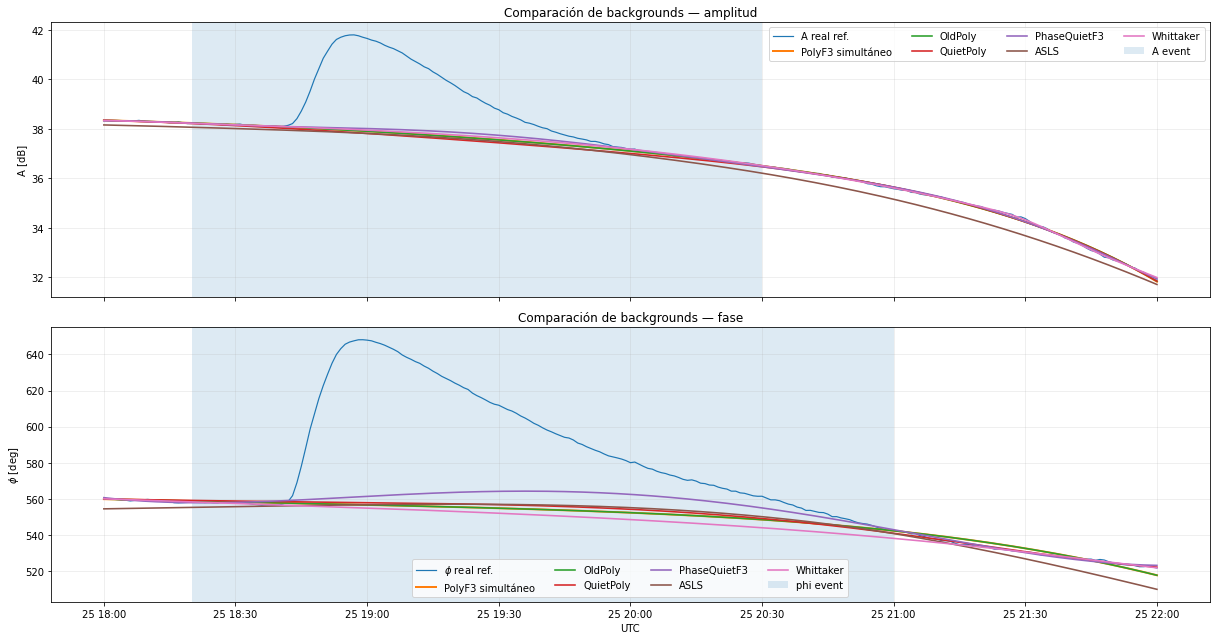

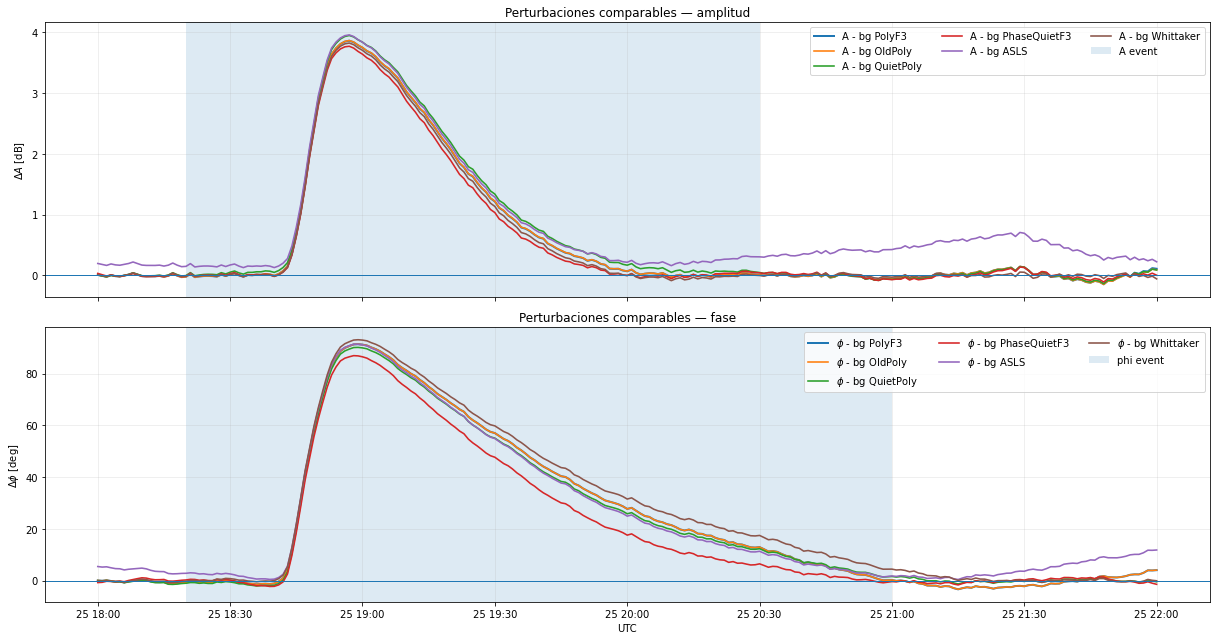

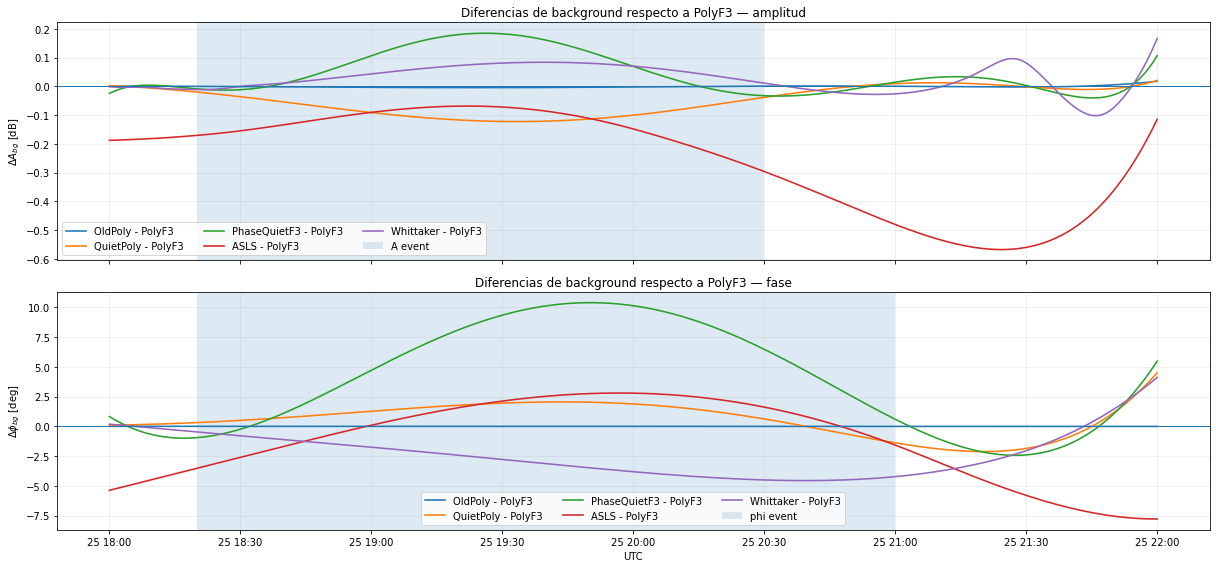

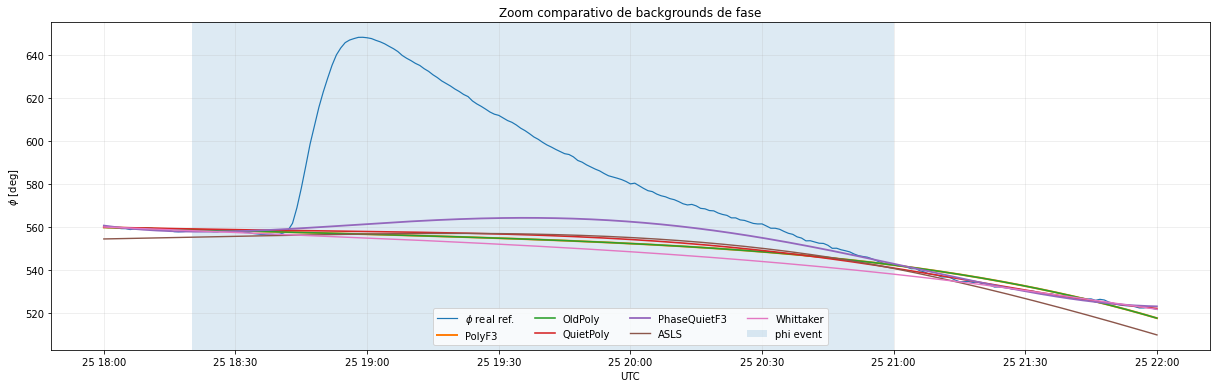


Archivos guardados en:
  /home/jp/basefolder_JP/outputs_compare_all_backgrounds_including_phase_quiet_windows

Figuras:
  backgrounds_all_methods_including_phasequiet.png
  perturbations_all_methods_including_phasequiet.png
  background_differences_all_methods_including_phasequiet_minus_polyF3.png
  phase_backgrounds_zoom_all_methods_including_phasequiet.png

Tablas:
  background_difference_all_methods_including_phasequiet_vs_polyF3.csv
  perturbation_metrics_all_methods_including_phasequiet.csv
  timeseries_all_methods_including_phasequiet_common_interval.csv


In [24]:
# ============================================================
# Comparación ampliada de TODOS los backgrounds:
#
#   1) Poly+F3 simultáneo seleccionado:
#        simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5
#
#   2) Background polinómico antiguo correcto:
#        real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5
#        o
#        new_real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5
#
#   3) Background polinómico con ventanas quietas, caso nuevo window×degree:
#        selected_window_degree_sensitivity_NAA_V_20080325_Awin16_22_degA7_PHIwin16_22_degPhi6.h5
#
#   4) Background polinómico/F3 con fase ajustada usando quiet windows:
#        real_F3_phase_quiet_windows_selected_solution.h5
#
#   5) ASLS antiguo:
#        datos_asls_full-v3.h5
#
#   6) Whittaker:
#        real_whittaker_selected_background_16_22_for_inversion.h5
#
# La comparación usa como datos de referencia:
#   A_ref, phi_ref = datos reales del Poly+F3 simultáneo seleccionado.
#
# Las perturbaciones comparables se calculan siempre como:
#   perturbación = datos_referencia - background_método
#
# Nota:
#   Como real_F3_phase_quiet_windows_selected_solution.h5 suele cubrir 18:00–22:00,
#   el intervalo común final probablemente será 18:00–22:00 UTC.
# ============================================================

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1) Configuración de archivos
# ============================================================

OUTDIR = Path("outputs_compare_all_backgrounds_including_phase_quiet_windows")
OUTDIR.mkdir(parents=True, exist_ok=True)

SEARCH_ROOTS = [
    Path("."),
    Path("/mnt/data"),
]

FILE_PATTERNS = {
    "PolyF3": [
        "simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5",
    ],
    "OldPoly": [
        "real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5",
        "new_real_background_perturbation_separation_NAA_V_20080325_degA7_degPhi4.h5",
    ],
    "QuietPoly": [
        "selected_window_degree_sensitivity_NAA_V_20080325_Awin16_22_degA7_PHIwin16_22_degPhi6.h5",
    ],
    "PhaseQuietF3": [
        "real_F3_phase_quiet_windows_selected_solution.h5",
    ],
    "ASLS": [
        "datos_asls_full-v3.h5",
    ],
    "Whittaker": [
        "real_whittaker_selected_background_16_22_for_inversion.h5",
    ],
}


def find_file_by_names(names, roots):
    hits = []

    for root in roots:
        root = Path(root)
        if not root.exists():
            continue

        for name in names:
            direct = root / name
            if direct.exists() and direct.is_file():
                hits.append(direct)

            hits.extend([p for p in root.rglob(name) if p.is_file()])

    unique = []
    seen = set()

    for p in hits:
        rp = p.resolve()
        if rp not in seen:
            unique.append(p)
            seen.add(rp)

    if len(unique) == 0:
        return None

    # Si hay varias copias, usa la más reciente.
    unique = sorted(unique, key=lambda p: p.stat().st_mtime, reverse=True)
    return unique[0]


paths = {}

for label, names in FILE_PATTERNS.items():
    paths[label] = find_file_by_names(names, SEARCH_ROOTS)

missing = [label for label, path in paths.items() if path is None]

if missing:
    raise FileNotFoundError(
        "No encontré estos archivos requeridos:\n"
        + "\n".join(f"  - {m}: {FILE_PATTERNS[m]}" for m in missing)
    )

print("Archivos usados:")
for label, path in paths.items():
    print(f"  {label}:")
    print(f"    {path}")

# ============================================================
# 2) Utilidades de lectura robusta
# ============================================================

def decode_strings(arr):
    arr = np.asarray(arr)
    out = []

    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))

    return np.array(out, dtype=object)


def to_datetime_robust(raw):
    arr = np.asarray(raw)

    if np.issubdtype(arr.dtype, np.number):
        vals = arr.astype(float)
        med = np.nanmedian(vals)

        if med > 1e14:
            return pd.to_datetime(vals, unit="us", utc=True)
        elif med > 1e11:
            return pd.to_datetime(vals, unit="ms", utc=True)
        else:
            return pd.to_datetime(vals, unit="s", utc=True)

    vals = decode_strings(arr)

    numeric_vals = pd.to_numeric(pd.Series(vals), errors="coerce")
    frac_numeric = numeric_vals.notna().mean()

    if frac_numeric > 0.95:
        x = numeric_vals.to_numpy(dtype=float)
        med = np.nanmedian(x)

        if med > 1e14:
            return pd.to_datetime(x, unit="us", utc=True)
        elif med > 1e11:
            return pd.to_datetime(x, unit="ms", utc=True)
        else:
            return pd.to_datetime(x, unit="s", utc=True)

    return pd.to_datetime(vals, utc=True)


def read_dataset_first(h5, names, required=True):
    for name in names:
        if name in h5:
            return h5[name][()]

    all_names = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            all_names.append(name)

    h5.visititems(visitor)

    for candidate in names:
        for name in all_names:
            if name == candidate or name.endswith("/" + candidate):
                return h5[name][()]

    if required:
        raise KeyError(
            "No encontré ninguno de estos datasets:\n"
            f"  {names}\n"
            "Datasets disponibles:\n"
            + "\n".join([f"  {k}" for k in all_names])
        )

    return None


def read_time_index(h5):
    raw = read_dataset_first(
        h5,
        [
            "timestamps_iso",
            "timestamps",
            "timestamps_unix",
            "time_unix",
            "unix_timestamps",
            "time_utc",
        ],
        required=True,
    )

    return pd.DatetimeIndex(to_datetime_robust(raw), name="time_utc")


# ============================================================
# 3) Lectores de HDF5
# ============================================================

def load_generic_background_h5(path, label):
    """
    Lee HDF5 con datasets tipo:
      A_real, phi_real, A_background, phi_background

    Acepta variantes:
      A_background_model, phi_background_model, baseline_amp, baseline_phi, etc.

    Devuelve:
      A_real_label
      phi_real_label
      A_bg_label
      phi_bg_label
      A_pert_label_from_bg
      phi_pert_label_from_bg

    Si existen F3/perturbaciones modeladas, también las conserva.
    """

    with h5py.File(path, "r") as h5:
        t = read_time_index(h5)

        A_real = read_dataset_first(
            h5,
            ["A_real", "A_data", "amp_real", "amplitude_real"],
            required=True,
        )

        phi_real = read_dataset_first(
            h5,
            ["phi_real", "phi_data", "phase_real"],
            required=True,
        )

        A_bg = read_dataset_first(
            h5,
            [
                "A_background",
                "A_background_model",
                "A_bg",
                "baseline_amp",
                "baseline_asls_amp",
            ],
            required=True,
        )

        phi_bg = read_dataset_first(
            h5,
            [
                "phi_background",
                "phi_background_model",
                "phi_bg",
                "baseline_phi",
                "baseline_asls_phi",
            ],
            required=True,
        )

        A_model_pert = read_dataset_first(
            h5,
            [
                "A_perturbation_F3",
                "A_F3",
                "A_perturbation_model",
                "A_perturbation",
            ],
            required=False,
        )

        phi_model_pert = read_dataset_first(
            h5,
            [
                "phi_perturbation_F3",
                "phi_F3",
                "phi_perturbation_model",
                "phi_perturbation",
            ],
            required=False,
        )

    n = len(t)

    def checked(arr, name):
        arr = np.asarray(arr)
        if len(arr) != n:
            raise ValueError(
                f"Longitud inconsistente en {path.name}: "
                f"{name} tiene {len(arr)}, timestamps tiene {n}."
            )
        return arr.astype(float)

    df = pd.DataFrame(
        {
            f"A_real_{label}": checked(A_real, "A_real"),
            f"phi_real_{label}": checked(phi_real, "phi_real"),
            f"A_bg_{label}": checked(A_bg, "A_background"),
            f"phi_bg_{label}": checked(phi_bg, "phi_background"),
        },
        index=t,
    )

    df[f"A_pert_{label}_from_bg"] = df[f"A_real_{label}"] - df[f"A_bg_{label}"]
    df[f"phi_pert_{label}_from_bg"] = df[f"phi_real_{label}"] - df[f"phi_bg_{label}"]

    if A_model_pert is not None and len(A_model_pert) == n:
        df[f"A_model_pert_{label}"] = np.asarray(A_model_pert, dtype=float)

    if phi_model_pert is not None and len(phi_model_pert) == n:
        df[f"phi_model_pert_{label}"] = np.asarray(phi_model_pert, dtype=float)

    return df[~df.index.duplicated(keep="first")].sort_index()


def load_asls(path):
    """
    Lee el ASLS antiguo:
      time_unix
      baseline_asls_amp
      baseline_asls_phi
      detrended_asls_amp
      detrended_asls_phi

    Reconstruye:
      real = baseline + detrended

    Luego remuestrea a 1 min con mediana.
    """

    with h5py.File(path, "r") as h5:
        t = pd.DatetimeIndex(
            pd.to_datetime(h5["time_unix"][()], unit="s", utc=True),
            name="time_utc",
        )

        A_bg = np.asarray(h5["baseline_asls_amp"][()], dtype=float)
        phi_bg = np.asarray(h5["baseline_asls_phi"][()], dtype=float)

        A_pert = np.asarray(h5["detrended_asls_amp"][()], dtype=float)
        phi_pert = np.asarray(h5["detrended_asls_phi"][()], dtype=float)

        A_real = A_bg + A_pert
        phi_real = phi_bg + phi_pert

    df = pd.DataFrame(
        {
            "A_real_ASLS_native": A_real,
            "phi_real_ASLS_native": phi_real,
            "A_bg_ASLS": A_bg,
            "phi_bg_ASLS": phi_bg,
            "A_pert_ASLS_native": A_pert,
            "phi_pert_ASLS_native": phi_pert,
        },
        index=t,
    )

    df = df[~df.index.duplicated(keep="first")].sort_index()

    df_1min = df.resample("1min").median(numeric_only=True)

    return df_1min


df_polyF3 = load_generic_background_h5(paths["PolyF3"], "PolyF3")
df_oldpoly = load_generic_background_h5(paths["OldPoly"], "OldPoly")
df_quietpoly = load_generic_background_h5(paths["QuietPoly"], "QuietPoly")
df_phasequiet = load_generic_background_h5(paths["PhaseQuietF3"], "PhaseQuietF3")
df_asls = load_asls(paths["ASLS"])
df_whittaker = load_generic_background_h5(paths["Whittaker"], "Whittaker")

# ============================================================
# 4) Unión temporal y referencia común
# ============================================================

df_all = (
    df_polyF3
    .join(df_oldpoly, how="outer")
    .join(df_quietpoly, how="outer")
    .join(df_phasequiet, how="outer")
    .join(df_asls, how="outer")
    .join(df_whittaker, how="outer")
)

df_all = df_all.sort_index()

# Referencia común: datos reales del Poly+F3 simultáneo seleccionado.
df_all["A_ref"] = df_all["A_real_PolyF3"]
df_all["phi_ref"] = df_all["phi_real_PolyF3"]

method_bg_cols = {
    "PolyF3": ("A_bg_PolyF3", "phi_bg_PolyF3"),
    "OldPoly": ("A_bg_OldPoly", "phi_bg_OldPoly"),
    "QuietPoly": ("A_bg_QuietPoly", "phi_bg_QuietPoly"),
    "PhaseQuietF3": ("A_bg_PhaseQuietF3", "phi_bg_PhaseQuietF3"),
    "ASLS": ("A_bg_ASLS", "phi_bg_ASLS"),
    "Whittaker": ("A_bg_Whittaker", "phi_bg_Whittaker"),
}

for method, (A_bg_col, phi_bg_col) in method_bg_cols.items():
    df_all[f"A_pert_{method}"] = df_all["A_ref"] - df_all[A_bg_col]
    df_all[f"phi_pert_{method}"] = df_all["phi_ref"] - df_all[phi_bg_col]

required_common = [
    "A_ref",
    "phi_ref",
]

for method, (A_bg_col, phi_bg_col) in method_bg_cols.items():
    required_common.extend([A_bg_col, phi_bg_col])

df_common = df_all.dropna(subset=required_common).copy()

if len(df_common) == 0:
    raise ValueError(
        "No hay timestamps comunes entre todos los métodos. "
        "Revisa rangos temporales y resolución."
    )

print("\nRangos originales:")
print(f"  PolyF3:       {df_polyF3.index.min()} -> {df_polyF3.index.max()}  N={len(df_polyF3)}")
print(f"  OldPoly:      {df_oldpoly.index.min()} -> {df_oldpoly.index.max()}  N={len(df_oldpoly)}")
print(f"  QuietPoly:    {df_quietpoly.index.min()} -> {df_quietpoly.index.max()}  N={len(df_quietpoly)}")
print(f"  PhaseQuietF3: {df_phasequiet.index.min()} -> {df_phasequiet.index.max()}  N={len(df_phasequiet)}")
print(f"  ASLS 1min:    {df_asls.index.min()} -> {df_asls.index.max()}  N={len(df_asls)}")
print(f"  Whittaker:    {df_whittaker.index.min()} -> {df_whittaker.index.max()}  N={len(df_whittaker)}")

print("\nRango común usado para comparación total:")
print(f"  {df_common.index.min()} -> {df_common.index.max()}  N={len(df_common)}")

# Máscaras diagnósticas.
A_EVENT_START = pd.Timestamp("2008-03-25 18:20:00", tz="UTC")
A_EVENT_END   = pd.Timestamp("2008-03-25 20:30:00", tz="UTC")

PHI_EVENT_START = pd.Timestamp("2008-03-25 18:20:00", tz="UTC")
PHI_EVENT_END   = pd.Timestamp("2008-03-25 21:00:00", tz="UTC")

A_event_mask = np.asarray(
    (df_common.index >= A_EVENT_START) & (df_common.index <= A_EVENT_END),
    dtype=bool,
)

phi_event_mask = np.asarray(
    (df_common.index >= PHI_EVENT_START) & (df_common.index <= PHI_EVENT_END),
    dtype=bool,
)

# ============================================================
# 5) Métricas
# ============================================================

def summarize_diff(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return {
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "rmse": np.nan,
            "max_abs": np.nan,
        }

    return {
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "std": float(np.std(x)),
        "rmse": float(np.sqrt(np.mean(x**2))),
        "max_abs": float(np.max(np.abs(x))),
    }


def peak_abs(series, mask):
    x = np.asarray(series[mask], dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan

    return float(np.max(np.abs(x)))


def signed_peak(series, mask):
    x = np.asarray(series[mask], dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan

    i = int(np.argmax(np.abs(x)))
    return float(x[i])


def area_abs(index, series, mask):
    idx = pd.DatetimeIndex(index)
    y = np.asarray(series, dtype=float)
    mask = np.asarray(mask, dtype=bool) & np.isfinite(y)

    if np.sum(mask) < 2:
        return np.nan

    t_hours = (idx[mask] - idx[mask][0]).total_seconds().to_numpy() / 3600.0
    return float(np.trapz(np.abs(y[mask]), t_hours))


def area_signed(index, series, mask):
    idx = pd.DatetimeIndex(index)
    y = np.asarray(series, dtype=float)
    mask = np.asarray(mask, dtype=bool) & np.isfinite(y)

    if np.sum(mask) < 2:
        return np.nan

    t_hours = (idx[mask] - idx[mask][0]).total_seconds().to_numpy() / 3600.0
    return float(np.trapz(y[mask], t_hours))


# Diferencias respecto a PolyF3.
diff_rows = []

for method in ["OldPoly", "QuietPoly", "PhaseQuietF3", "ASLS", "Whittaker"]:
    for channel, bg_ref, bg_other, mask_event in [
        ("A", "A_bg_PolyF3", f"A_bg_{method}", A_event_mask),
        ("phi", "phi_bg_PolyF3", f"phi_bg_{method}", phi_event_mask),
    ]:
        diff_all = df_common[bg_other] - df_common[bg_ref]
        diff_event = diff_all[mask_event]

        s_all = summarize_diff(diff_all)
        s_event = summarize_diff(diff_event)

        s_all.update({
            "channel": channel,
            "comparison": f"{method} - PolyF3",
            "region": "common_all",
            "N": len(diff_all),
        })

        s_event.update({
            "channel": channel,
            "comparison": f"{method} - PolyF3",
            "region": "event",
            "N": int(np.sum(mask_event)),
        })

        diff_rows.append(s_all)
        diff_rows.append(s_event)

diff_summary = pd.DataFrame(diff_rows)[
    ["channel", "comparison", "region", "N", "mean", "median", "std", "rmse", "max_abs"]
]

print("\nDiferencias de background respecto a PolyF3:")
display(diff_summary.round(6))

# Métricas de perturbación.
pert_rows = []

for channel, mask_event, methods in [
    (
        "A",
        A_event_mask,
        {
            "PolyF3": "A_pert_PolyF3",
            "OldPoly": "A_pert_OldPoly",
            "QuietPoly": "A_pert_QuietPoly",
            "PhaseQuietF3": "A_pert_PhaseQuietF3",
            "ASLS": "A_pert_ASLS",
            "Whittaker": "A_pert_Whittaker",
        },
    ),
    (
        "phi",
        phi_event_mask,
        {
            "PolyF3": "phi_pert_PolyF3",
            "OldPoly": "phi_pert_OldPoly",
            "QuietPoly": "phi_pert_QuietPoly",
            "PhaseQuietF3": "phi_pert_PhaseQuietF3",
            "ASLS": "phi_pert_ASLS",
            "Whittaker": "phi_pert_Whittaker",
        },
    ),
]:
    for method, col in methods.items():
        pert_rows.append({
            "channel": channel,
            "method": method,
            "N_event": int(np.sum(mask_event)),
            "peak_abs_event": peak_abs(df_common[col], mask_event),
            "peak_signed_event": signed_peak(df_common[col], mask_event),
            "area_abs_event": area_abs(df_common.index, df_common[col], mask_event),
            "area_signed_event": area_signed(df_common.index, df_common[col], mask_event),
        })

pert_summary = pd.DataFrame(pert_rows)

print("\nPerturbaciones comparables = datos de referencia - background:")
display(pert_summary.round(6))

diff_summary.to_csv(
    OUTDIR / "background_difference_all_methods_including_phasequiet_vs_polyF3.csv",
    index=False,
)

pert_summary.to_csv(
    OUTDIR / "perturbation_metrics_all_methods_including_phasequiet.csv",
    index=False,
)

# ============================================================
# 6) Figuras
# ============================================================

def shade_interval(ax, start, end, label=None, alpha=0.15):
    ax.axvspan(start, end, alpha=alpha, label=label)


# ------------------------------------------------------------
# Figura 1: backgrounds
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(17, 9), sharex=True)

axes[0].plot(df_common.index, df_common["A_ref"], lw=1.2, label="A real ref.")
axes[0].plot(df_common.index, df_common["A_bg_PolyF3"], lw=2.0, label="PolyF3 simultáneo")
axes[0].plot(df_common.index, df_common["A_bg_OldPoly"], lw=1.6, label="OldPoly")
axes[0].plot(df_common.index, df_common["A_bg_QuietPoly"], lw=1.6, label="QuietPoly")
axes[0].plot(df_common.index, df_common["A_bg_PhaseQuietF3"], lw=1.6, label="PhaseQuietF3")
axes[0].plot(df_common.index, df_common["A_bg_ASLS"], lw=1.6, label="ASLS")
axes[0].plot(df_common.index, df_common["A_bg_Whittaker"], lw=1.6, label="Whittaker")
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
axes[0].set_ylabel("A [dB]")
axes[0].set_title("Comparación de backgrounds — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=4)

axes[1].plot(df_common.index, df_common["phi_ref"], lw=1.2, label=r"$\phi$ real ref.")
axes[1].plot(df_common.index, df_common["phi_bg_PolyF3"], lw=2.0, label="PolyF3 simultáneo")
axes[1].plot(df_common.index, df_common["phi_bg_OldPoly"], lw=1.6, label="OldPoly")
axes[1].plot(df_common.index, df_common["phi_bg_QuietPoly"], lw=1.6, label="QuietPoly")
axes[1].plot(df_common.index, df_common["phi_bg_PhaseQuietF3"], lw=1.6, label="PhaseQuietF3")
axes[1].plot(df_common.index, df_common["phi_bg_ASLS"], lw=1.6, label="ASLS")
axes[1].plot(df_common.index, df_common["phi_bg_Whittaker"], lw=1.6, label="Whittaker")
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
axes[1].set_ylabel(r"$\phi$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Comparación de backgrounds — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=4)

plt.tight_layout()
plt.savefig(
    OUTDIR / "backgrounds_all_methods_including_phasequiet.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ------------------------------------------------------------
# Figura 2: perturbaciones comparables
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(17, 9), sharex=True)

axes[0].plot(df_common.index, df_common["A_pert_PolyF3"], lw=2.0, label="A - bg PolyF3")
axes[0].plot(df_common.index, df_common["A_pert_OldPoly"], lw=1.6, label="A - bg OldPoly")
axes[0].plot(df_common.index, df_common["A_pert_QuietPoly"], lw=1.6, label="A - bg QuietPoly")
axes[0].plot(df_common.index, df_common["A_pert_PhaseQuietF3"], lw=1.6, label="A - bg PhaseQuietF3")
axes[0].plot(df_common.index, df_common["A_pert_ASLS"], lw=1.6, label="A - bg ASLS")
axes[0].plot(df_common.index, df_common["A_pert_Whittaker"], lw=1.6, label="A - bg Whittaker")
axes[0].axhline(0, lw=1)
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
axes[0].set_ylabel(r"$\Delta A$ [dB]")
axes[0].set_title("Perturbaciones comparables — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=3)

axes[1].plot(df_common.index, df_common["phi_pert_PolyF3"], lw=2.0, label=r"$\phi$ - bg PolyF3")
axes[1].plot(df_common.index, df_common["phi_pert_OldPoly"], lw=1.6, label=r"$\phi$ - bg OldPoly")
axes[1].plot(df_common.index, df_common["phi_pert_QuietPoly"], lw=1.6, label=r"$\phi$ - bg QuietPoly")
axes[1].plot(df_common.index, df_common["phi_pert_PhaseQuietF3"], lw=1.6, label=r"$\phi$ - bg PhaseQuietF3")
axes[1].plot(df_common.index, df_common["phi_pert_ASLS"], lw=1.6, label=r"$\phi$ - bg ASLS")
axes[1].plot(df_common.index, df_common["phi_pert_Whittaker"], lw=1.6, label=r"$\phi$ - bg Whittaker")
axes[1].axhline(0, lw=1)
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
axes[1].set_ylabel(r"$\Delta\phi$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Perturbaciones comparables — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=3)

plt.tight_layout()
plt.savefig(
    OUTDIR / "perturbations_all_methods_including_phasequiet.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ------------------------------------------------------------
# Figura 3: diferencias directas respecto a PolyF3
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(17, 8), sharex=True)

for method in ["OldPoly", "QuietPoly", "PhaseQuietF3", "ASLS", "Whittaker"]:
    axes[0].plot(
        df_common.index,
        df_common[f"A_bg_{method}"] - df_common["A_bg_PolyF3"],
        lw=1.6,
        label=f"{method} - PolyF3",
    )

axes[0].axhline(0, lw=1)
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, "A event")
axes[0].set_ylabel(r"$\Delta A_{bg}$ [dB]")
axes[0].set_title("Diferencias de background respecto a PolyF3 — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=3)

for method in ["OldPoly", "QuietPoly", "PhaseQuietF3", "ASLS", "Whittaker"]:
    axes[1].plot(
        df_common.index,
        df_common[f"phi_bg_{method}"] - df_common["phi_bg_PolyF3"],
        lw=1.6,
        label=f"{method} - PolyF3",
    )

axes[1].axhline(0, lw=1)
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, "phi event")
axes[1].set_ylabel(r"$\Delta\phi_{bg}$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Diferencias de background respecto a PolyF3 — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=3)

plt.tight_layout()
plt.savefig(
    OUTDIR / "background_differences_all_methods_including_phasequiet_minus_polyF3.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ------------------------------------------------------------
# Figura 4: zoom solo backgrounds de fase
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(17, 5.5))

ax.plot(df_common.index, df_common["phi_ref"], lw=1.2, label=r"$\phi$ real ref.")
ax.plot(df_common.index, df_common["phi_bg_PolyF3"], lw=2.0, label="PolyF3")
ax.plot(df_common.index, df_common["phi_bg_OldPoly"], lw=1.6, label="OldPoly")
ax.plot(df_common.index, df_common["phi_bg_QuietPoly"], lw=1.6, label="QuietPoly")
ax.plot(df_common.index, df_common["phi_bg_PhaseQuietF3"], lw=1.8, label="PhaseQuietF3")
ax.plot(df_common.index, df_common["phi_bg_ASLS"], lw=1.4, label="ASLS")
ax.plot(df_common.index, df_common["phi_bg_Whittaker"], lw=1.4, label="Whittaker")
shade_interval(ax, PHI_EVENT_START, PHI_EVENT_END, "phi event")
ax.set_ylabel(r"$\phi$ [deg]")
ax.set_xlabel("UTC")
ax.set_title("Zoom comparativo de backgrounds de fase")
ax.grid(True, alpha=0.25)
ax.legend(ncol=4)

plt.tight_layout()
plt.savefig(
    OUTDIR / "phase_backgrounds_zoom_all_methods_including_phasequiet.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ============================================================
# 7) Guardar serie comparativa
# ============================================================

df_out = df_common.copy()
df_out.index = df_out.index.strftime("%Y-%m-%dT%H:%M:%SZ")

df_out.to_csv(
    OUTDIR / "timeseries_all_methods_including_phasequiet_common_interval.csv"
)

print("\nArchivos guardados en:")
print(f"  {OUTDIR.resolve()}")

print("\nFiguras:")
print("  backgrounds_all_methods_including_phasequiet.png")
print("  perturbations_all_methods_including_phasequiet.png")
print("  background_differences_all_methods_including_phasequiet_minus_polyF3.png")
print("  phase_backgrounds_zoom_all_methods_including_phasequiet.png")

print("\nTablas:")
print("  background_difference_all_methods_including_phasequiet_vs_polyF3.csv")
print("  perturbation_metrics_all_methods_including_phasequiet.csv")
print("  timeseries_all_methods_including_phasequiet_common_interval.csv")

Usando df_common ya existente en memoria.


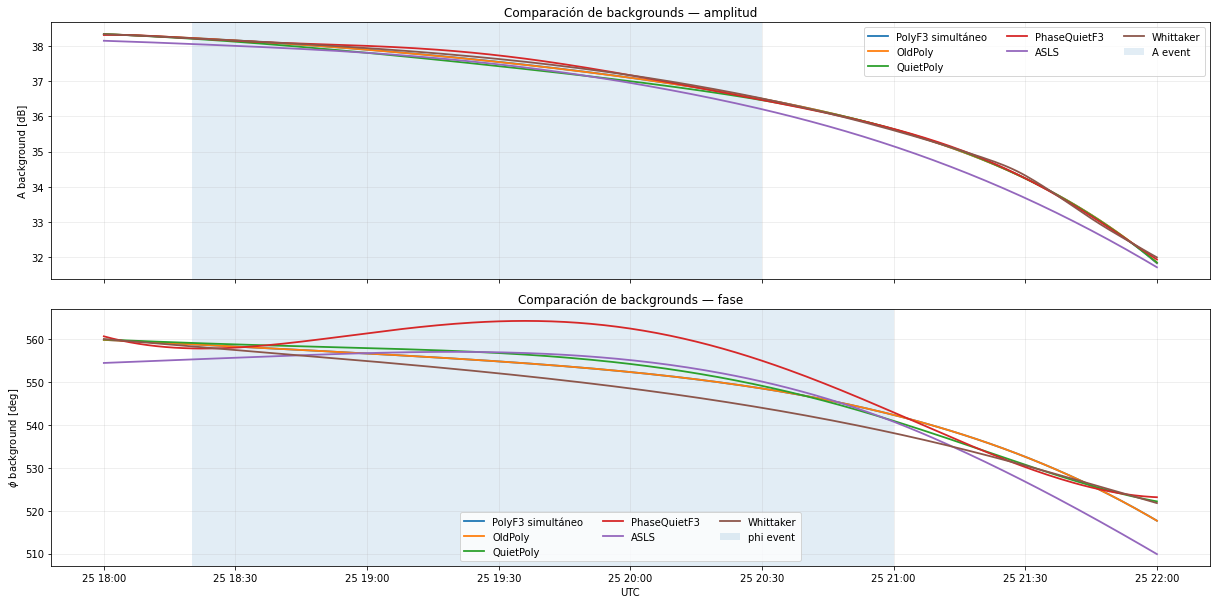

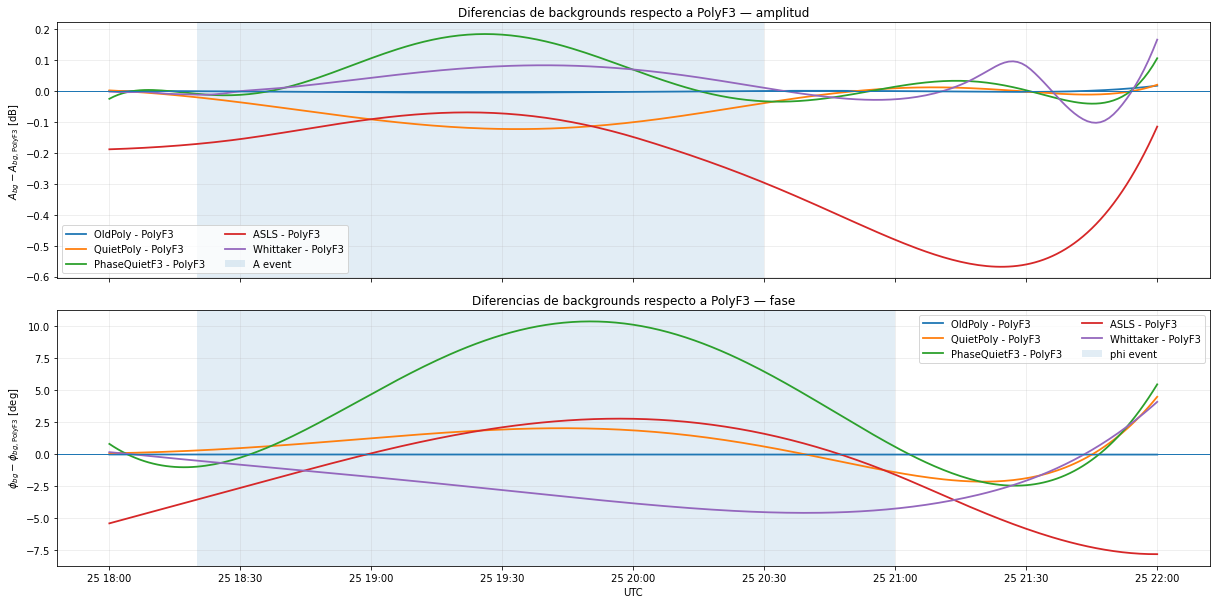


Figuras guardadas en:
  /home/jp/basefolder_JP/outputs_compare_all_backgrounds_including_phase_quiet_windows

Archivos:
  backgrounds_only_all_methods.png
  backgrounds_only_differences_vs_polyF3.png


In [25]:
# ============================================================
# Dibujar SOLO los backgrounds de todos los métodos
# sin datos reales y sin perturbaciones.
#
# Requiere que exista df_common generado por la celda de comparación completa.
# Si no existe, intenta leer:
#   outputs_compare_all_backgrounds_including_phase_quiet_windows/
#   timeseries_all_methods_including_phasequiet_common_interval.csv
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1) Cargar df_common si no está en memoria
# ============================================================

OUTDIR = Path("outputs_compare_all_backgrounds_including_phase_quiet_windows")
OUTDIR.mkdir(parents=True, exist_ok=True)

TIMESERIES_CANDIDATES = [
    OUTDIR / "timeseries_all_methods_including_phasequiet_common_interval.csv",
    Path("/mnt/data/outputs_compare_all_backgrounds_including_phase_quiet_windows/timeseries_all_methods_including_phasequiet_common_interval.csv"),
]

if "df_common" not in globals():
    ts_path = None

    for p in TIMESERIES_CANDIDATES:
        if p.exists():
            ts_path = p
            break

    if ts_path is None:
        raise RuntimeError(
            "No existe df_common en memoria y no encontré el CSV comparativo. "
            "Ejecuta primero la celda grande de comparación de todos los backgrounds."
        )

    df_common = pd.read_csv(ts_path)
    df_common["time_utc"] = pd.to_datetime(df_common["time_utc"], utc=True)
    df_common = df_common.set_index("time_utc").sort_index()

    print("df_common cargado desde:")
    print(" ", ts_path)

else:
    print("Usando df_common ya existente en memoria.")

# ============================================================
# 2) Verificar columnas necesarias
# ============================================================

background_cols_A = {
    "PolyF3 simultáneo": "A_bg_PolyF3",
    "OldPoly": "A_bg_OldPoly",
    "QuietPoly": "A_bg_QuietPoly",
    "PhaseQuietF3": "A_bg_PhaseQuietF3",
    "ASLS": "A_bg_ASLS",
    "Whittaker": "A_bg_Whittaker",
}

background_cols_phi = {
    "PolyF3 simultáneo": "phi_bg_PolyF3",
    "OldPoly": "phi_bg_OldPoly",
    "QuietPoly": "phi_bg_QuietPoly",
    "PhaseQuietF3": "phi_bg_PhaseQuietF3",
    "ASLS": "phi_bg_ASLS",
    "Whittaker": "phi_bg_Whittaker",
}

missing_A = [col for col in background_cols_A.values() if col not in df_common.columns]
missing_phi = [col for col in background_cols_phi.values() if col not in df_common.columns]

if missing_A or missing_phi:
    raise KeyError(
        "Faltan columnas de background en df_common:\n"
        f"A: {missing_A}\n"
        f"phi: {missing_phi}\n"
        "Revisa que la celda previa haya generado todos los métodos."
    )

# ============================================================
# 3) Máscaras/eventos para sombreado
# ============================================================

A_EVENT_START = pd.Timestamp("2008-03-25 18:20:00", tz="UTC")
A_EVENT_END   = pd.Timestamp("2008-03-25 20:30:00", tz="UTC")

PHI_EVENT_START = pd.Timestamp("2008-03-25 18:20:00", tz="UTC")
PHI_EVENT_END   = pd.Timestamp("2008-03-25 21:00:00", tz="UTC")

def shade_interval(ax, start, end, label=None, alpha=0.13):
    ax.axvspan(start, end, alpha=alpha, label=label)

# ============================================================
# 4) Figura principal: backgrounds A y phi
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(17, 8.5), sharex=True)

for label, col in background_cols_A.items():
    axes[0].plot(
        df_common.index,
        df_common[col],
        lw=1.8,
        label=label,
    )

shade_interval(axes[0], A_EVENT_START, A_EVENT_END, label="A event")
axes[0].set_ylabel("A background [dB]")
axes[0].set_title("Comparación de backgrounds — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=3)

for label, col in background_cols_phi.items():
    axes[1].plot(
        df_common.index,
        df_common[col],
        lw=1.8,
        label=label,
    )

shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, label="phi event")
axes[1].set_ylabel(r"$\phi$ background [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Comparación de backgrounds — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=3)

plt.tight_layout()
plt.savefig(
    OUTDIR / "backgrounds_only_all_methods.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# ============================================================
# 5) Figura de diferencias respecto a PolyF3
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(17, 8.5), sharex=True)

for label, col in background_cols_A.items():
    if col == "A_bg_PolyF3":
        continue

    axes[0].plot(
        df_common.index,
        df_common[col] - df_common["A_bg_PolyF3"],
        lw=1.8,
        label=f"{label} - PolyF3",
    )

axes[0].axhline(0, lw=1)
shade_interval(axes[0], A_EVENT_START, A_EVENT_END, label="A event")
axes[0].set_ylabel(r"$A_{bg} - A_{bg,\mathrm{PolyF3}}$ [dB]")
axes[0].set_title("Diferencias de backgrounds respecto a PolyF3 — amplitud")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=2)

for label, col in background_cols_phi.items():
    if col == "phi_bg_PolyF3":
        continue

    axes[1].plot(
        df_common.index,
        df_common[col] - df_common["phi_bg_PolyF3"],
        lw=1.8,
        label=f"{label} - PolyF3",
    )

axes[1].axhline(0, lw=1)
shade_interval(axes[1], PHI_EVENT_START, PHI_EVENT_END, label="phi event")
axes[1].set_ylabel(r"$\phi_{bg} - \phi_{bg,\mathrm{PolyF3}}$ [deg]")
axes[1].set_xlabel("UTC")
axes[1].set_title("Diferencias de backgrounds respecto a PolyF3 — fase")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=2)

plt.tight_layout()
plt.savefig(
    OUTDIR / "backgrounds_only_differences_vs_polyF3.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("\nFiguras guardadas en:")
print(f"  {OUTDIR.resolve()}")
print("\nArchivos:")
print("  backgrounds_only_all_methods.png")
print("  backgrounds_only_differences_vs_polyF3.png")